<a href="https://colab.research.google.com/github/kerenslendyrc/Estadistica/blob/main/nuevaclusterizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# BLOQUE 1. CARGA DE DATOS
# =========================================================

import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt

from IPython.display import display

# ---------------------------------------------------------
# 1) CARGA
# ---------------------------------------------------------
# Si ya tienes la base cargada en una variable llamada df, reutilízala.
# Si no, sube el archivo desde Colab.

if "df" in globals():
    df_raw = df.copy()
    print("Se reutilizó el dataframe 'df' que ya estaba en memoria.")
else:
    from google.colab import files
    uploaded = files.upload()
    archivo = next(iter(uploaded))

    if archivo.lower().endswith(".xlsx"):
        df_raw = pd.read_excel(archivo)
    elif archivo.lower().endswith(".csv"):
        df_raw = pd.read_csv(archivo)
    else:
        raise ValueError(f"Formato no soportado: {archivo}")

print("Filas:", len(df_raw))
print("Columnas:", len(df_raw.columns))
display(df_raw.head(3))

Saving Base de datos.xlsx to Base de datos (1).xlsx
Filas: 94134
Columnas: 32


,episodio,fecha_ini_episodio,fecha_movimiento_alta,clase_movimiento_alta,asignacion_enfermeria,Ingreso del servicio,Ingreso Materiales y medicamentos,Ingreso honorarios,Ingreso Total,Servicio,...,departamento,ciudad,id_discapacidad,cdo_diagnostico_egreso,nombre_diagnostico_egreso,gran_causa_morbilidad,subgrupo_causa_morbilidad,cod_causa_basica_muerte,causa_basica_muerte,fecha_muerte
0,5511592,2022-05-11,2022-05-13 22:53:00,Alta a H ext.,1 UE HOSP CLINICENTRO URG P4,411960,658948,530729,1964142,Hospitalización adultos,...,SANTANDER,BUCARAMANGA,Ninguna,J440,ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICACON INF...,Enfermedades no transmisibles,Enfermedades respiratorias,NaN,NaN,NaT
1,5517360,2022-05-13,2022-05-13 23:43:00,Alta a H ext.,1 UE HOSP CLINICENTRO URG P4,108285,221840,112400,585075,Hospitalización adultos,...,SANTANDER,BUCARAMANGA,Ninguna,N390,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",Enfermedades no transmisibles,Enfermedades genitourinarias,NaN,NaN,NaT
2,5519031,2022-05-14,2022-05-15 17:25:00,Alta a H ext.,1 UE HOSP CLINICENTRO URG P4,127900,167855,491315,973620,Hospitalización adultos,...,SANTANDER,BUCARAMANGA,Ninguna,R074,"DOLOR EN EL PECHO, NO ESPECIFICADO",Signos y síntomas mal definidos,Signos y síntomas mal definidos,NaN,NaN,NaT


In [ ]:
# =========================================================
# BLOQUE 2. FUNCIONES AUXILIARES
# =========================================================

def resolver_columna_opcional(df, opciones):
    for col in opciones:
        if col in df.columns:
            return col
    return None

def resolver_columna_obligatoria(df, opciones, nombre_amigable):
    col = resolver_columna_opcional(df, opciones)
    if col is None:
        raise KeyError(
            f"No encontré la columna para '{nombre_amigable}'. "
            f"Probé con: {opciones}\n"
            f"Columnas disponibles: {list(df.columns)}"
        )
    return col

def quitar_acentos(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto)
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])
    return texto

def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = quitar_acentos(texto)
    texto = texto.upper().strip()
    texto = re.sub(r"\s+", " ", texto)
    return texto

def normalizar_codigo_cie(codigo):
    if pd.isna(codigo):
        return ""
    codigo = str(codigo).upper().strip()
    codigo = codigo.replace(".", "")
    codigo = re.sub(r"[^A-Z0-9]", "", codigo)
    return codigo

def extraer_letra_numero_cie(codigo):
    """
    Ej: U071 -> ('U', 7)
        O800 -> ('O', 80)
        A419 -> ('A', 41)
    """
    codigo = normalizar_codigo_cie(codigo)
    m = re.match(r"^([A-Z])(\d{2})", codigo)
    if not m:
        return None, None
    return m.group(1), int(m.group(2))

def parsear_fecha_segura(serie):
    s = serie.copy()
    # primero intenta parseo general
    dt = pd.to_datetime(s, errors="coerce", dayfirst=True)
    return dt

def normalizar_fallecimiento(serie):
    s = serie.copy()

    if pd.api.types.is_numeric_dtype(s):
        vals = pd.to_numeric(s, errors="coerce")
        unicos = set(vals.dropna().unique().tolist())
        if unicos.issubset({0, 1}):
            return vals.fillna(0).astype(int)

    s = s.astype(str).str.strip().str.upper()

    verdaderos = {"SI", "SÍ", "1", "TRUE", "T", "YES", "FALLECIDO", "MUERTO", "DEFUNCION", "DEFUNCIÓN"}
    falsos = {"NO", "0", "FALSE", "F", "ALTA", "VIVO", "EGRESADO"}

    out = np.where(s.isin(verdaderos), 1,
          np.where(s.isin(falsos), 0, np.nan))

    return pd.Series(out, index=serie.index).fillna(0).astype(int)

In [ ]:
# =========================================================
# BLOQUE 3. RESOLVER COLUMNAS CLAVE
# =========================================================

df0 = df_raw.copy()
df0.columns = df0.columns.str.strip()

# ----------------------------
# Columnas principales
# ----------------------------
COL_DX_COD = resolver_columna_obligatoria(
    df0,
    [
        "cdo_diagnostico_egreso",
        "codigo_diagnostico_egreso",
        "codigo_diagnostico",
        "diagnostico_codigo",
        "dx_codigo",
        "cie10",
        "cie_10"
    ],
    "Código diagnóstico de egreso"
)

COL_DX_NOM = resolver_columna_obligatoria(
    df0,
    [
        "nombre_diagnostico_egreso",
        "diagnostico_egreso",
        "nombre_diagnostico",
        "descripcion_diagnostico",
        "diagnostico",
        "dx_nombre"
    ],
    "Nombre diagnóstico de egreso"
)

COL_CAUSA_OLD = resolver_columna_obligatoria(
    df0,
    [
        "gran_causa_morbilidad",
        "causa_morbilidad",
        "gran_causa"
    ],
    "Gran causa de morbilidad original"
)

COL_EDAD = resolver_columna_opcional(
    df0,
    ["edad", "Edad"]
)

COL_EDAD_GRUPO = resolver_columna_opcional(
    df0,
    ["grupo_de_edad", "grupo_edad", "edad_grupo"]
)

COL_SEXO = resolver_columna_opcional(
    df0,
    ["sexo", "Sexo"]
)

COL_SERVICIO = resolver_columna_opcional(
    df0,
    ["Servicio", "servicio"]
)

COL_UO = resolver_columna_opcional(
    df0,
    ["unidad_medica", "uo_medico", "uo_medico_macro"]
)

COL_EPS = resolver_columna_opcional(
    df0,
    ["EPS", "EPS_grupo", "eps", "aseguradora"]
)

COL_FECHA_INGRESO = resolver_columna_opcional(
    df0,
    [
        "fecha_ini_episodio",
        "fecha_ingreso",
        "fecha_admision",
        "fecha_hospitalizacion",
        "fecha_inicio_atencion"
    ]
)

COL_ANIO = resolver_columna_opcional(
    df0,
    ["anio", "año", "ANIO", "AÑO", "year", "Year"]
)

COL_FALLEC = resolver_columna_opcional(
    df0,
    ["fallecimiento_SN", "fallecimiento", "Fallecimiento"]
)

COL_FECHA_MUERTE = resolver_columna_opcional(
    df0,
    ["fecha_muerte", "Fecha_muerte", "fecha_defuncion"]
)

print("=== Columnas resueltas ===")
print("Código DX:", COL_DX_COD)
print("Nombre DX:", COL_DX_NOM)
print("Gran causa original:", COL_CAUSA_OLD)
print("Edad:", COL_EDAD)
print("Grupo edad:", COL_EDAD_GRUPO)
print("Sexo:", COL_SEXO)
print("Servicio:", COL_SERVICIO)
print("UO:", COL_UO)
print("EPS:", COL_EPS)
print("Fecha ingreso:", COL_FECHA_INGRESO)
print("Año:", COL_ANIO)
print("Fallecimiento:", COL_FALLEC)
print("Fecha muerte:", COL_FECHA_MUERTE)

=== Columnas resueltas ===
Código DX: cdo_diagnostico_egreso
Nombre DX: nombre_diagnostico_egreso
Gran causa original: gran_causa_morbilidad
Edad: edad
Grupo edad: grupo_de_edad
Sexo: sexo
Servicio: Servicio
UO: unidad_medica
EPS: EPS
Fecha ingreso: fecha_ini_episodio
Año: None
Fallecimiento: None
Fecha muerte: fecha_muerte


In [ ]:
# =========================================================
# BLOQUE 4. ESTANDARIZACIÓN INICIAL
# =========================================================

df1 = df0.copy()

# ----------------------------
# Diagnóstico
# ----------------------------
df1["dx_codigo"] = df1[COL_DX_COD].apply(normalizar_codigo_cie)
df1["dx_nombre"] = df1[COL_DX_NOM].apply(limpiar_texto)

# ----------------------------
# Gran causa original normalizada
# ----------------------------
df1["gran_causa_original_norm"] = df1[COL_CAUSA_OLD].apply(limpiar_texto)

reemplazos_causa = {
    "SIN CLASIFICACION": "SIN CLASIFICACION",
    "SIN CLASIFICACIÓN": "SIN CLASIFICACION",
    "SIGNOS Y SINTOMAS MAL DEFINIDOS": "MAL_DEFINIDAS_INESPECIFICAS",
    "SIGNOS Y SÍNTOMAS MAL DEFINIDOS": "MAL_DEFINIDAS_INESPECIFICAS",
    "CONDICIONES TRANSMISIBLES Y NUTRICIONALES": "TRANSMISIBLES",
    "ENFERMEDADES NO TRANSMISIBLES": "NO_TRANSMISIBLES",
    "CONDICIONES MATERNAS PERINATALES": "MATERNAS_PERINATALES",
    "LESIONES": "LESIONES"
}

df1["gran_causa_original_norm"] = df1["gran_causa_original_norm"].replace(reemplazos_causa)

# ----------------------------
# Fallecimiento
# ----------------------------
if COL_FALLEC is not None:
    df1["fall_bin"] = normalizar_fallecimiento(df1[COL_FALLEC])

elif COL_FECHA_MUERTE is not None:
    df1["fecha_muerte_dt"] = parsear_fecha_segura(df1[COL_FECHA_MUERTE])
    df1["fall_bin"] = df1["fecha_muerte_dt"].notna().astype(int)

else:
    raise ValueError("No encontré columna de fallecimiento ni fecha de muerte.")

# ----------------------------
# Año
# ----------------------------
if COL_ANIO is not None:
    df1["anio_analisis"] = pd.to_numeric(df1[COL_ANIO], errors="coerce")

elif COL_FECHA_INGRESO is not None:
    df1["fecha_ingreso_dt"] = parsear_fecha_segura(df1[COL_FECHA_INGRESO])
    df1["anio_analisis"] = df1["fecha_ingreso_dt"].dt.year

else:
    raise ValueError("No encontré ni columna de año ni fecha de ingreso.")

print("Distribución por año:")
display(df1["anio_analisis"].value_counts(dropna=False).sort_index())

Distribución por año:


,count
anio_analisis,
2021,19885
2022,23582
2023,24387
2024,26280


In [ ]:
# =========================================================
# BLOQUE 5. COHORTE 2024
# =========================================================

df_2024_base = df1[df1["anio_analisis"] == 2024].copy()

print("Filas cohorte 2024:", len(df_2024_base))
display(df_2024_base.head(3))

# Auditoría rápida
tabla_anio = (
    df1["anio_analisis"]
    .value_counts(dropna=False)
    .rename_axis("anio")
    .reset_index(name="n")
    .sort_values("anio")
)

display(tabla_anio)

Filas cohorte 2024: 26280


,episodio,fecha_ini_episodio,fecha_movimiento_alta,clase_movimiento_alta,asignacion_enfermeria,Ingreso del servicio,Ingreso Materiales y medicamentos,Ingreso honorarios,Ingreso Total,Servicio,...,cod_causa_basica_muerte,causa_basica_muerte,fecha_muerte,dx_codigo,dx_nombre,gran_causa_original_norm,fecha_muerte_dt,fall_bin,fecha_ingreso_dt,anio_analisis
1107,6712217,2024-01-01,2024-01-02 06:08:00,Alta,1 UE HOSP CLINICENTRO URG P4,192060,7398306,273660,10296964,Hospitalización adultos,...,NaN,NaN,NaT,K359,"APENDICITIS AGUDA, NO ESPECIFICADA",NO_TRANSMISIBLES,NaT,0,2024-01-01,2024
1108,6712269,2024-01-01,2024-01-01 23:48:00,Alta a H ext.,1 UE HOSP CLINICENTRO URG P4,293900,91920,263100,736520,Hospitalización adultos,...,NaN,NaN,NaT,A90X,FIEBRE DEL DENGUE [DENGUE CLASICO],TRANSMISIBLES,NaT,0,2024-01-01,2024
1109,6712310,2024-01-01,2024-01-02 16:05:00,Alta a H ext.,1 UE HOSP CLINICENTRO URG P4,127900,178660,601350,1170053,Hospitalización adultos,...,NaN,NaN,NaT,K922,"HEMORRAGIA GASTROINTESTINAL, NO ESPECIFICADA",NO_TRANSMISIBLES,NaT,0,2024-01-01,2024


,anio,n
3,2021,19885
2,2022,23582
1,2023,24387
0,2024,26280


In [ ]:
# =========================================================
# BLOQUE 6. REGLAS DE RECLASIFICACIÓN CLÍNICA
# =========================================================

def es_covid(codigo, nombre):
    codigo = normalizar_codigo_cie(codigo)
    nombre = limpiar_texto(nombre)

    if codigo.startswith(("U071", "U072")):
        return True

    claves = [
        "COVID",
        "SARS COV 2",
        "SARS-COV-2",
        "CORONAVIRUS 2019",
        "INFECCION POR CORONAVIRUS",
        "INFECCIÓN POR CORONAVIRUS"
    ]
    return any(k in nombre for k in claves)


def es_materna_obstetrica(codigo, nombre):
    codigo = normalizar_codigo_cie(codigo)
    nombre = limpiar_texto(nombre)
    letra, num = extraer_letra_numero_cie(codigo)

    if letra == "O":
        return True

    if letra == "Z" and num is not None and 34 <= num <= 39:
        return True

    if codigo.startswith("Z37"):
        return True

    claves = [
        "CESAREA", "CESÁREA",
        "CESAREA ELECTIVA", "CESÁREA ELECTIVA",
        "CESAREA DE EMERGENCIA", "CESÁREA DE EMERGENCIA",
        "PARTO UNICO ESPONTANEO", "PARTO ÚNICO ESPONTÁNEO",
        "PARTO POR CESAREA", "PARTO POR CESÁREA",
        "TRABAJO DE PARTO",
        "PUERPERIO",
        "EMBARAZO",
        "GESTACION", "GESTACIÓN",
        "ABORTO",
        "OBSTETR",
        "PRECLAMPSIA", "PREECLAMPSIA",
        "ECLAMPSIA"
    ]
    return any(k in nombre for k in claves)


def es_perinatal_neonatal(codigo, nombre):
    codigo = normalizar_codigo_cie(codigo)
    nombre = limpiar_texto(nombre)
    letra, num = extraer_letra_numero_cie(codigo)

    if letra == "P":
        return True

    claves = [
        "RECIEN NACIDO", "RECIÉN NACIDO",
        "NEONATAL",
        "PREMATURO", "PREMATURIDAD",
        "BAJO PESO AL NACER",
        "SDR NEONATAL",
        "DISTRES RESPIRATORIO DEL RECIEN NACIDO",
        "DISTRES RESPIRATORIO DEL RECIÉN NACIDO",
        "INMADUREZ EXTREMA",
        "RETINOPATIA DE LA PREMATURIDAD",
        "RETINOPATÍA DE LA PREMATURIDAD"
    ]
    return any(k in nombre for k in claves)


def es_lesion_o_causa_externa(codigo, nombre):
    codigo = normalizar_codigo_cie(codigo)
    nombre = limpiar_texto(nombre)
    letra, num = extraer_letra_numero_cie(codigo)

    if letra in ["S", "T", "V", "W", "X", "Y"]:
        return True

    claves = [
        "TRAUMA", "TRAUMATISMO", "FRACTURA", "HERIDA",
        "ACCIDENTE", "QUEMADURA", "INTOXICACION", "INTOXICACIÓN",
        "ENVENENAMIENTO"
    ]
    return any(k in nombre for k in claves)


def es_mal_definida_inespecifica(codigo, nombre):
    codigo = normalizar_codigo_cie(codigo)
    nombre = limpiar_texto(nombre)
    letra, num = extraer_letra_numero_cie(codigo)

    if letra == "R":
        return True

    if codigo == "" and nombre == "":
        return True

    claves_fuertes = [
        "SIGNOS Y SINTOMAS", "SIGNOS Y SÍNTOMAS",
        "HALLAZGO ANORMAL", "HALLAZGOS ANORMALES",
        "OBSERVACION POR SOSPECHA", "OBSERVACIÓN POR SOSPECHA",
        "OBSERVACION POR SOSPECHA DE", "OBSERVACIÓN POR SOSPECHA DE",
        "SINTOMA", "SINTOMAS",
        "DOLOR ABDOMINAL",
        "FIEBRE NO ESPECIFICADA",
        "SINDROME FEBRIL", "SÍNDROME FEBRIL",
        "MALESTAR GENERAL",
        "SIN DIAGNOSTICO", "SIN DIAGNÓSTICO",
        "DIAGNOSTICO PENDIENTE", "DIAGNÓSTICO PENDIENTE",
        "POR CONFIRMAR",
        "SOSPECHA DIAGNOSTICA", "SOSPECHA DIAGNÓSTICA"
    ]

    return any(k in nombre for k in claves_fuertes)


# =========================================================
# FUNCIÓN CORREGIDA: ES_INFECCIOSA_NO_COVID
# =========================================================

def es_infecciosa_no_covid(codigo, nombre):
    codigo = normalizar_codigo_cie(codigo)
    nombre = limpiar_texto(nombre)
    letra, num = extraer_letra_numero_cie(codigo)

    if es_covid(codigo, nombre):
        return False

    # --------------------------------------------------
    # Exclusiones explícitas: cuadros digestivos/biliares
    # que no queremos meter como infecciosos primarios
    # --------------------------------------------------
    if codigo.startswith(("K35", "K36", "K37", "K80", "K81", "K82", "K83")):
        return False

    if codigo.startswith(("Z20", "Z111")):
        return False

    if any(k in nombre for k in [
        "APENDICITIS",
        "CALCULO DE LA VESICULA", "CÁLCULO DE LA VESÍCULA",
        "CALCULO DE CONDUCTO BILIAR", "CÁLCULO DE CONDUCTO BILIAR",
        "COLECISTITIS", "COLANGITIS",
        "OBESIDAD",
        "CONTACTO CON Y EXPOSICION A TUBERCULOSIS",
        "CONTACTO CON Y EXPOSICIÓN A TUBERCULOSIS",
        "EXAMEN DE PESQUISA ESPECIAL PARA TUBERCULOSIS"
    ]):
        return False

    # --------------------------------------------------
    # Infecciosas/parasitarias clásicas
    # --------------------------------------------------
    if letra in ["A", "B"]:
        return True

    # --------------------------------------------------
    # Sepsis / sistémicas
    # --------------------------------------------------
    if codigo.startswith(("A40", "A41", "R572")):
        return True

    # --------------------------------------------------
    # Patrones por capítulo
    # --------------------------------------------------
    patrones_codigo = [
        ("G", 0, 9),     # SNC infeccioso
        ("J", 9, 22),    # respiratorias infecciosas
        ("N", 10, 16),   # urinarias infecciosas
        ("L", 0, 8),     # piel/tejidos blandos infecciosos
    ]

    if letra is not None and num is not None:
        for l, a, b in patrones_codigo:
            if letra == l and a <= num <= b:
                return True

    # --------------------------------------------------
    # Rescate por texto
    # --------------------------------------------------
    claves = [
        "SEPSIS", "SEPTICEMIA", "SEPTIC",
        "NEUMONIA", "NEUMONÍA",
        "INFECCION", "INFECCIÓN",
        "DENGUE", "TUBERCULOSIS", "VIH", "SIDA",
        "BRONQUIOLITIS", "GASTROENTERITIS INFECCIOSA",
        "PIELONEFRITIS", "MENINGITIS",
        "CELULITIS", "CISTITIS", "URETRITIS",
        "PROSTATITIS", "ERISIPELA", "FASCITIS",
        "LEPTOSPIROSIS", "LEISHMANIASIS", "PALUDISMO", "MALARIA",
        "ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA CON INFECCION",
        "ENFERMEDAD PULMONAR OBSTRUCTIVA CRÓNICA CON INFECCIÓN",
        "INFECCION AGUDA DE LAS VIAS RESPIRATORIAS INFERIORES",
        "INFECCIÓN AGUDA DE LAS VÍAS RESPIRATORIAS INFERIORES"
    ]
    return any(k in nombre for k in claves)


def clasificacion_clinica_reconstruida(codigo, nombre):
    if es_covid(codigo, nombre):
        return "COVID-19"
    if es_materna_obstetrica(codigo, nombre):
        return "MATERNA_OBSTETRICA"
    if es_perinatal_neonatal(codigo, nombre):
        return "PERINATAL_NEONATAL"
    if es_lesion_o_causa_externa(codigo, nombre):
        return "LESIONES"
    if es_infecciosa_no_covid(codigo, nombre):
        return "INFECCIOSA_NO_COVID"
    if es_mal_definida_inespecifica(codigo, nombre):
        return "MAL_DEFINIDAS_INESPECIFICAS"
    return "NO_TRANSMISIBLE"

In [ ]:
# =========================================================
# BLOQUE 7. SUBCLASIFICACIÓN OBSTÉTRICA
# =========================================================

def subtipo_registro_obstetrico(nombre_dx):
    nombre = limpiar_texto(nombre_dx)

    if nombre == "":
        return "SIN_DATO"

    claves_evento = [
        "CESAREA",
        "PARTO",
        "PARTO UNICO ESPONTANEO",
        "PARTO POR CESAREA",
        "CESAREA ELECTIVA",
        "CESAREA DE EMERGENCIA",
        "RESULTADO DEL PARTO"
    ]
    if any(k in nombre for k in claves_evento):
        if "SIN OTRA ESPECIFICACION" in nombre or "NO ESPECIFICADO" in nombre:
            return "EVENTO_OBSTETRICO_INESPECIFICO"
        return "EVENTO_OBSTETRICO_PROCEDIMIENTO"

    claves_complicacion = [
        "PREECLAMPSIA",
        "PRECLAMPSIA",
        "ECLAMPSIA",
        "HEMORRAGIA OBSTETRICA",
        "HEMORRAGIA POSTPARTO",
        "ABORTO",
        "INFECCION PUERPERAL",
        "TRABAJO DE PARTO OBSTRUIDO",
        "RUPTURA PREMATURA",
        "PLACENTA PREVIA"
    ]
    if any(k in nombre for k in claves_complicacion):
        return "COMPLICACION_OBSTETRICA"

    if "SIN OTRA ESPECIFICACION" in nombre or "NO ESPECIFICADO" in nombre:
        return "OBSTETRICO_INESPECIFICO"

    return "OTRO_REGISTRO_OBSTETRICO"

In [ ]:
# =========================================================
# BLOQUE 8. APLICACIÓN DE REGLAS CLÍNICAS
# =========================================================

df_2024 = df_2024_base.copy()

df_2024["clasificacion_reconstruida"] = df_2024.apply(
    lambda row: clasificacion_clinica_reconstruida(
        row["dx_codigo"],
        row["dx_nombre"]
    ),
    axis=1
)

df_2024["flag_covid"] = (df_2024["clasificacion_reconstruida"] == "COVID-19").astype(int)
df_2024["flag_materna"] = (df_2024["clasificacion_reconstruida"] == "MATERNA_OBSTETRICA").astype(int)
df_2024["flag_perinatal"] = (df_2024["clasificacion_reconstruida"] == "PERINATAL_NEONATAL").astype(int)
df_2024["flag_infecciosa_no_covid"] = (df_2024["clasificacion_reconstruida"] == "INFECCIOSA_NO_COVID").astype(int)
df_2024["flag_no_transmisible"] = (df_2024["clasificacion_reconstruida"] == "NO_TRANSMISIBLE").astype(int)
df_2024["flag_lesiones"] = (df_2024["clasificacion_reconstruida"] == "LESIONES").astype(int)
df_2024["flag_mal_definida"] = (df_2024["clasificacion_reconstruida"] == "MAL_DEFINIDAS_INESPECIFICAS").astype(int)

df_2024["subtipo_obstetrico"] = np.where(
    df_2024["flag_materna"] == 1,
    df_2024["dx_nombre"].apply(subtipo_registro_obstetrico),
    "NO_APLICA"
)

def mapear_original_a_macro(causa_original):
    causa = limpiar_texto(causa_original)

    if causa in ["TRANSMISIBLES", "CONDICIONES TRANSMISIBLES Y NUTRICIONALES"]:
        return "INFECCIOSA_NO_COVID"
    if causa in ["NO_TRANSMISIBLES", "ENFERMEDADES NO TRANSMISIBLES", "NO TRANSMISIBLES"]:
        return "NO_TRANSMISIBLE"
    if causa in ["MATERNAS_PERINATALES", "CONDICIONES MATERNAS PERINATALES", "MATERNAS PERINATALES"]:
        return "MATERNAS_PERINATALES_OLD"
    if causa == "LESIONES":
        return "LESIONES"
    if causa in ["SIN CLASIFICACION", "MAL_DEFINIDAS_INESPECIFICAS", "MAL DEFINIDAS/INESPECIFICAS"]:
        return "MAL_DEFINIDAS_INESPECIFICAS"
    if causa == "":
        return "OTRA_O_DESCONOCIDA"
    return "OTRA_O_DESCONOCIDA"

df_2024["macro_original"] = df_2024["gran_causa_original_norm"].apply(mapear_original_a_macro)

def discrepancia_clinica(row):
    nueva = row["clasificacion_reconstruida"]
    vieja = row["macro_original"]

    if nueva in ["MATERNA_OBSTETRICA", "PERINATAL_NEONATAL"] and vieja == "MATERNAS_PERINATALES_OLD":
        return 0

    if nueva == vieja:
        return 0

    if nueva == "COVID-19":
        return 1

    return 1

df_2024["flag_discrepancia_clinica"] = df_2024.apply(discrepancia_clinica, axis=1)

print("Cohorte 2024 lista:", len(df_2024))
display(df_2024[[
    "dx_codigo", "dx_nombre",
    "gran_causa_original_norm",
    "clasificacion_reconstruida",
    "subtipo_obstetrico",
    "flag_discrepancia_clinica"
]].head(10))

Cohorte 2024 lista: 26280


,dx_codigo,dx_nombre,gran_causa_original_norm,clasificacion_reconstruida,subtipo_obstetrico,flag_discrepancia_clinica
1107,K359,"APENDICITIS AGUDA, NO ESPECIFICADA",NO_TRANSMISIBLES,NO_TRANSMISIBLE,NO_APLICA,0
1108,A90X,FIEBRE DEL DENGUE [DENGUE CLASICO],TRANSMISIBLES,INFECCIOSA_NO_COVID,NO_APLICA,0
1109,K922,"HEMORRAGIA GASTROINTESTINAL, NO ESPECIFICADA",NO_TRANSMISIBLES,NO_TRANSMISIBLE,NO_APLICA,0
1110,C884,LINFOMA DE CELULAS B EXTRANODAL DE ZONAMARGINA...,NO_TRANSMISIBLES,NO_TRANSMISIBLE,NO_APLICA,0
1111,C509,"TUMOR MALIGNO DE LA MAMA, PARTE NO ESPECIFICADA",NO_TRANSMISIBLES,NO_TRANSMISIBLE,NO_APLICA,0
1112,L031,CELULITIS DE OTRAS PARTES DE LOS MIEMBROS,NO_TRANSMISIBLES,INFECCIOSA_NO_COVID,NO_APLICA,1
1113,N390,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",NO_TRANSMISIBLES,INFECCIOSA_NO_COVID,NO_APLICA,1
1114,R51X,CEFALEA,MAL_DEFINIDAS_INESPECIFICAS,MAL_DEFINIDAS_INESPECIFICAS,NO_APLICA,0
1115,N390,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",NO_TRANSMISIBLES,INFECCIOSA_NO_COVID,NO_APLICA,1
1116,I671,"ANEURISMA CEREBRAL, SIN RUPTURA",NO_TRANSMISIBLES,NO_TRANSMISIBLE,NO_APLICA,0


In [ ]:
# =========================================================
# BLOQUE 9. COHORTES DEL ESTUDIO
# =========================================================

df_2024_sin_covid = df_2024[df_2024["flag_covid"] == 0].copy()
df_2024_con_covid = df_2024.copy()
df_solo_covid_2024 = df_2024[df_2024["flag_covid"] == 1].copy()

print("=== TAMAÑO DE COHORTES ===")
print("2024 total:", len(df_2024_con_covid))
print("2024 sin COVID:", len(df_2024_sin_covid))
print("2024 solo COVID:", len(df_solo_covid_2024))

print("\n=== FALLECIMIENTOS ===")
print("2024 total:", df_2024_con_covid["fall_bin"].sum())
print("2024 sin COVID:", df_2024_sin_covid["fall_bin"].sum())
print("2024 solo COVID:", df_solo_covid_2024["fall_bin"].sum())

=== TAMAÑO DE COHORTES ===
2024 total: 26280
2024 sin COVID: 26266
2024 solo COVID: 14

=== FALLECIMIENTOS ===
2024 total: 469
2024 sin COVID: 469
2024 solo COVID: 0


In [ ]:
# =========================================================
# BLOQUE 10. AUDITORÍA CLÍNICA DE LA NUEVA CLASIFICACIÓN
# =========================================================

def tabla_frecuencias(df, col):
    out = (
        df[col]
        .fillna("SIN_DATO")
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="n")
    )
    out["pct"] = out["n"] / out["n"].sum() * 100
    return out

print("=== Clasificación reconstruida 2024 ===")
display(tabla_frecuencias(df_2024, "clasificacion_reconstruida"))

print("=== Clasificación reconstruida 2024 SIN COVID ===")
display(tabla_frecuencias(df_2024_sin_covid, "clasificacion_reconstruida"))

print("=== Subtipos obstétricos ===")
display(
    tabla_frecuencias(
        df_2024[df_2024["flag_materna"] == 1],
        "subtipo_obstetrico"
    )
)

print("=== Discrepancias entre clasificación original y reconstruida ===")
display(tabla_frecuencias(df_2024, "flag_discrepancia_clinica"))

tabla_cruce = pd.crosstab(
    df_2024["macro_original"],
    df_2024["clasificacion_reconstruida"],
    margins=True
)
display(tabla_cruce)

=== Clasificación reconstruida 2024 ===


,clasificacion_reconstruida,n,pct
0,NO_TRANSMISIBLE,11638,44.284627
1,INFECCIOSA_NO_COVID,5330,20.281583
2,MATERNA_OBSTETRICA,4229,16.092085
3,MAL_DEFINIDAS_INESPECIFICAS,3328,12.663623
4,LESIONES,1133,4.311263
5,PERINATAL_NEONATAL,608,2.313546
6,COVID-19,14,0.053272


=== Clasificación reconstruida 2024 SIN COVID ===


,clasificacion_reconstruida,n,pct
0,NO_TRANSMISIBLE,11638,44.308231
1,INFECCIOSA_NO_COVID,5330,20.292393
2,MATERNA_OBSTETRICA,4229,16.100662
3,MAL_DEFINIDAS_INESPECIFICAS,3328,12.670372
4,LESIONES,1133,4.313561
5,PERINATAL_NEONATAL,608,2.314780


=== Subtipos obstétricos ===


,subtipo_obstetrico,n,pct
0,EVENTO_OBSTETRICO_PROCEDIMIENTO,1692,40.009459
1,EVENTO_OBSTETRICO_INESPECIFICO,1610,38.070466
2,OTRO_REGISTRO_OBSTETRICO,596,14.093166
3,COMPLICACION_OBSTETRICA,257,6.077087
4,OBSTETRICO_INESPECIFICO,74,1.749823


=== Discrepancias entre clasificación original y reconstruida ===


,flag_discrepancia_clinica,n,pct
0,0,22381,85.163623
1,1,3899,14.836377


clasificacion_reconstruida,COVID-19,INFECCIOSA_NO_COVID,LESIONES,MAL_DEFINIDAS_INESPECIFICAS,MATERNA_OBSTETRICA,NO_TRANSMISIBLE,PERINATAL_NEONATAL,All
macro_original,,,,,,,,
INFECCIOSA_NO_COVID,0,3353,1,0,0,288,0,3642
LESIONES,0,0,98,0,0,0,0,98
MAL_DEFINIDAS_INESPECIFICAS,14,60,918,3274,263,256,0,4785
MATERNAS_PERINATALES_OLD,0,0,0,0,3957,0,605,4562
NO_TRANSMISIBLE,0,1917,116,38,0,11094,3,13168
OTRA_O_DESCONOCIDA,0,0,0,16,9,0,0,25
All,14,5330,1133,3328,4229,11638,608,26280


In [ ]:
# =========================================================
# BLOQUE 11. MORTALIDAD PRELIMINAR POR CATEGORÍA CLÍNICA
# =========================================================

tabla_mort_pre = (
    df_2024
    .groupby("clasificacion_reconstruida", dropna=False)
    .agg(
        n=("clasificacion_reconstruida", "size"),
        fallecimientos=("fall_bin", "sum")
    )
    .reset_index()
)

tabla_mort_pre["mortalidad_pct"] = tabla_mort_pre["fallecimientos"] / tabla_mort_pre["n"] * 100
tabla_mort_pre = tabla_mort_pre.sort_values("n", ascending=False)

display(tabla_mort_pre.round(2))

,clasificacion_reconstruida,n,fallecimientos,mortalidad_pct
5,NO_TRANSMISIBLE,11638,264,2.27
1,INFECCIOSA_NO_COVID,5330,121,2.27
4,MATERNA_OBSTETRICA,4229,0,0.00
3,MAL_DEFINIDAS_INESPECIFICAS,3328,59,1.77
2,LESIONES,1133,19,1.68
6,PERINATAL_NEONATAL,608,6,0.99
0,COVID-19,14,0,0.00


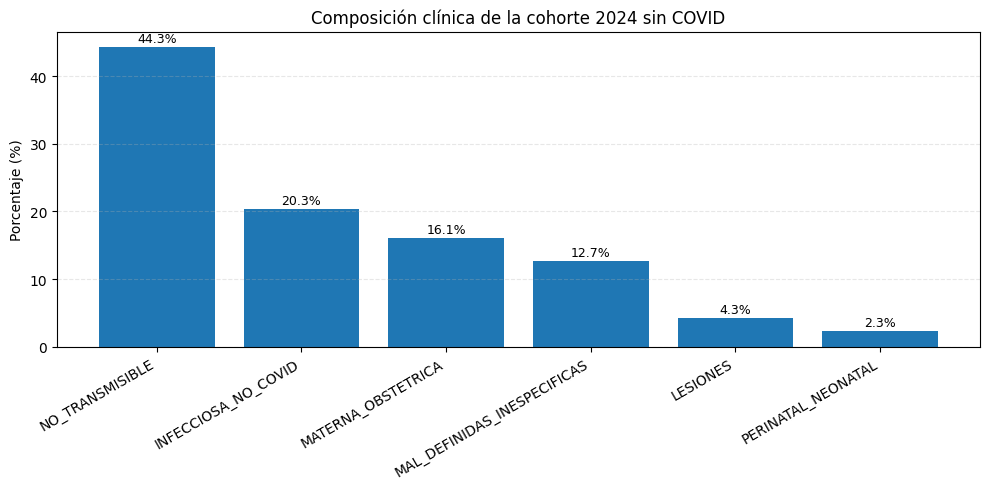

In [ ]:
# =========================================================
# BLOQUE 12. GRÁFICO DE COMPOSICIÓN CLÍNICA
# =========================================================

plot_df = tabla_frecuencias(df_2024_sin_covid, "clasificacion_reconstruida")

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df["clasificacion_reconstruida"], plot_df["pct"])
plt.title("Composición clínica de la cohorte 2024 sin COVID")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, plot_df["pct"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
df_2024_base[["fecha_ingreso_dt","anio_analisis"]].head(10)

,fecha_ingreso_dt,anio_analisis
1107,2024-01-01,2024
1108,2024-01-01,2024
1109,2024-01-01,2024
1110,2024-01-02,2024
1111,2024-01-02,2024
1112,2024-01-02,2024
1113,2024-01-03,2024
1114,2024-01-03,2024
1115,2024-01-04,2024
1116,2024-01-04,2024


In [ ]:
print("=== Top 30 diagnósticos en MAL_DEFINIDAS_INESPECIFICAS ===")
display(
    df_2024[df_2024["clasificacion_reconstruida"] == "MAL_DEFINIDAS_INESPECIFICAS"]
    ["dx_nombre"]
    .value_counts()
    .head(30)
    .reset_index()
    .rename(columns={"index": "dx_nombre", "dx_nombre": "n"})
)

print("=== Top 30 diagnósticos en OTRA_O_DESCONOCIDA de la clasificación original ===")
display(
    df_2024[df_2024["macro_original"] == "OTRA_O_DESCONOCIDA"]
    ["gran_causa_original_norm"]
    .value_counts()
    .head(30)
    .reset_index()
    .rename(columns={"index": "gran_causa_original_norm", "gran_causa_original_norm": "n"})
)

=== Top 30 diagnósticos en MAL_DEFINIDAS_INESPECIFICAS ===


,n,count
0,"FIEBRE, NO ESPECIFICADA",617
1,OTROS DOLORES ABDOMINALES Y LOS NO ESPECIFICADOS,515
2,"DOLOR EN EL PECHO, NO ESPECIFICADO",244
3,DISNEA,197
4,OTRAS CONVULSIONES Y LAS NO ESPECIFICADAS,171
5,SINCOPE Y COLAPSO,168
6,DOLOR ABDOMINAL LOCALIZADO EN PARTE SUPERIOR,133
7,CEFALEA,121
8,OTRO DOLOR CRONICO,85
9,NAUSEA Y VOMITO,84


=== Top 30 diagnósticos en OTRA_O_DESCONOCIDA de la clasificación original ===


,n,count
0,,25


La reclasificación nueva pasó de un 41.4% en “mal definidas” a 13.2%, mientras que no transmisibles quedó en 43.8% y transmisibles no COVID en 20.7%. Además, los diagnósticos que más aparecen en “mal definidas” ahora sí son los esperables para esa categoría: fiebre no especificada, dolor abdominal, dolor torácico, disnea, convulsiones no especificadas, síncope, etc.

In [ ]:
# =========================================================
# BLOQUE 13. LIBRERÍAS PARA CLUSTERING
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist

In [ ]:
# =========================================================
# BLOQUE 14. BASE ANALÍTICA FINAL
# =========================================================

df_analisis = df_2024_sin_covid.copy()

# ----------------------------
# Variables base
# ----------------------------
df_analisis["sexo_norm"] = (
    df_analisis[COL_SEXO].astype(str).str.strip().str.upper()
    if COL_SEXO is not None else "SIN_DATO"
)

df_analisis["grupo_edad_norm"] = (
    df_analisis[COL_EDAD_GRUPO].astype(str).str.strip().str.upper()
    if COL_EDAD_GRUPO is not None else "SIN_DATO"
)

# Capítulo CIE (primera letra)
df_analisis["cie_capitulo"] = df_analisis["dx_codigo"].astype(str).str[:1]

# Prefijo CIE de 3 caracteres aprox.
df_analisis["cie_3"] = df_analisis["dx_codigo"].astype(str).str[:3]

# Agrupación principal para subclustering
df_analisis["macro_grupo_cluster"] = df_analisis["clasificacion_reconstruida"]

print("Base analítica:", len(df_analisis))
display(
    df_analisis[[
        "dx_codigo", "dx_nombre", "sexo_norm", "grupo_edad_norm",
        "cie_capitulo", "cie_3", "macro_grupo_cluster"
    ]].head(10)
)

Base analítica: 26266


,dx_codigo,dx_nombre,sexo_norm,grupo_edad_norm,cie_capitulo,cie_3,macro_grupo_cluster
1107,K359,"APENDICITIS AGUDA, NO ESPECIFICADA",HOMBRE,25-29,K,K35,NO_TRANSMISIBLE
1108,A90X,FIEBRE DEL DENGUE [DENGUE CLASICO],HOMBRE,65-69,A,A90,INFECCIOSA_NO_COVID
1109,K922,"HEMORRAGIA GASTROINTESTINAL, NO ESPECIFICADA",HOMBRE,65-69,K,K92,NO_TRANSMISIBLE
1110,C884,LINFOMA DE CELULAS B EXTRANODAL DE ZONAMARGINA...,MUJER,50-54,C,C88,NO_TRANSMISIBLE
1111,C509,"TUMOR MALIGNO DE LA MAMA, PARTE NO ESPECIFICADA",MUJER,80 Y MÁS,C,C50,NO_TRANSMISIBLE
1112,L031,CELULITIS DE OTRAS PARTES DE LOS MIEMBROS,MUJER,50-54,L,L03,INFECCIOSA_NO_COVID
1113,N390,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",MUJER,80 Y MÁS,N,N39,INFECCIOSA_NO_COVID
1114,R51X,CEFALEA,HOMBRE,25-29,R,R51,MAL_DEFINIDAS_INESPECIFICAS
1115,N390,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",MUJER,75-79,N,N39,INFECCIOSA_NO_COVID
1116,I671,"ANEURISMA CEREBRAL, SIN RUPTURA",MUJER,70-74,I,I67,NO_TRANSMISIBLE


In [ ]:
# =========================================================
# BLOQUE 15. VARIABLES POR MACROGRUPO
# =========================================================

VARIABLES_POR_MACRO = {
    "NO_TRANSMISIBLE": [
        "grupo_edad_norm",
        "sexo_norm",
        "cie_capitulo",
        "cie_3"
    ],
    "INFECCIOSA_NO_COVID": [
        "grupo_edad_norm",
        "sexo_norm",
        "cie_capitulo",
        "cie_3"
    ],
    "MATERNA_OBSTETRICA": [
        "grupo_edad_norm",
        "subtipo_obstetrico",
        "cie_3"
    ],
    "PERINATAL_NEONATAL": [
        "grupo_edad_norm",
        "cie_capitulo",
        "cie_3"
    ],
    "LESIONES": [
        "grupo_edad_norm",
        "sexo_norm",
        "cie_capitulo",
        "cie_3"
    ],
    "MAL_DEFINIDAS_INESPECIFICAS": [
        "grupo_edad_norm",
        "sexo_norm",
        "cie_capitulo",
        "cie_3"
    ],
}

VARIABLES_POR_MACRO

{'NO_TRANSMISIBLE': ['grupo_edad_norm', 'sexo_norm', 'cie_capitulo', 'cie_3'],
 'INFECCIOSA_NO_COVID': ['grupo_edad_norm',
  'sexo_norm',
  'cie_capitulo',
  'cie_3'],
 'MATERNA_OBSTETRICA': ['grupo_edad_norm', 'subtipo_obstetrico', 'cie_3'],
 'PERINATAL_NEONATAL': ['grupo_edad_norm', 'cie_capitulo', 'cie_3'],
 'LESIONES': ['grupo_edad_norm', 'sexo_norm', 'cie_capitulo', 'cie_3'],
 'MAL_DEFINIDAS_INESPECIFICAS': ['grupo_edad_norm',
  'sexo_norm',
  'cie_capitulo',
  'cie_3']}

In [ ]:
# =========================================================
# BLOQUE 16. FUNCIÓN DE PREPARACIÓN DE MATRIZ
# =========================================================

def preparar_matriz_macro(df_macro, variables_cat, n_components=10):
    """
    1) One-hot encoding
    2) Reducción con TruncatedSVD
    """
    X_cat = df_macro[variables_cat].fillna("SIN_DATO").astype(str)

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    X_sparse = encoder.fit_transform(X_cat)

    n_features = X_sparse.shape[1]
    n_comp = min(n_components, max(2, n_features - 1))

    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    Z = svd.fit_transform(X_sparse)

    info = {
        "encoder": encoder,
        "svd": svd,
        "variables_cat": variables_cat,
        "n_features_ohe": n_features,
        "n_components_final": n_comp,
        "explained_variance_ratio_sum": svd.explained_variance_ratio_.sum()
    }

    return Z, info

In [ ]:
# =========================================================
# BLOQUE 17. JERÁRQUICO ESCALABLE POR PROTOTIPOS
# =========================================================

def clustering_jerarquico_por_prototipos(
    Z,
    k_final,
    n_microclusters=150,
    random_state=42
):
    """
    Paso 1: microclustering con MiniBatchKMeans
    Paso 2: linkage Ward sobre centroides de microclústeres
    Paso 3: cada observación hereda el clúster final de su microclúster
    """

    n = Z.shape[0]
    n_micro = min(n_microclusters, max(20, n // 30))

    # ----------------------------
    # Microclustering
    # ----------------------------
    mbk = MiniBatchKMeans(
        n_clusters=n_micro,
        random_state=random_state,
        batch_size=2048,
        n_init=10
    )
    micro_labels = mbk.fit_predict(Z)

    # centroides reales por microgrupo
    centroides = (
        pd.DataFrame(Z)
        .assign(micro_label=micro_labels)
        .groupby("micro_label")
        .mean()
        .sort_index()
        .values
    )

    # ----------------------------
    # Linkage Ward
    # ----------------------------
    Z_link = linkage(centroides, method="ward", metric="euclidean")

    # cortar el dendrograma
    labels_micro_final = fcluster(Z_link, t=k_final, criterion="maxclust")

    # mapear micro -> final
    mapa_micro_a_final = {
        micro_id: int(labels_micro_final[i])
        for i, micro_id in enumerate(sorted(np.unique(micro_labels)))
    }

    labels_final = np.array([mapa_micro_a_final[m] for m in micro_labels])

    out = {
        "micro_labels": micro_labels,
        "labels_final": labels_final,
        "mapa_micro_a_final": mapa_micro_a_final,
        "linkage_centroides": Z_link,
        "n_microclusters": n_micro,
        "centroides": centroides,
        "mbk_model": mbk
    }

    return out

In [ ]:
# =========================================================
# BLOQUE 18. VALIDACIÓN DE K
# =========================================================

def evaluar_k_macro(
    Z,
    k_min=2,
    k_max=8,
    n_microclusters=150,
    sample_size=5000,
    random_state=42
):
    """
    Evalúa k con:
    - silhouette
    - calinski-harabasz
    - davies-bouldin
    - tamaño mínimo de clúster
    """

    rng = np.random.default_rng(random_state)

    if Z.shape[0] > sample_size:
        idx = rng.choice(Z.shape[0], size=sample_size, replace=False)
        Z_eval = Z[idx]
        idx_eval = idx
    else:
        Z_eval = Z
        idx_eval = np.arange(Z.shape[0])

    resultados = []

    for k in range(k_min, k_max + 1):
        modelo = clustering_jerarquico_por_prototipos(
            Z=Z,
            k_final=k,
            n_microclusters=n_microclusters,
            random_state=random_state
        )

        labels_full = modelo["labels_final"]
        labels_eval = labels_full[idx_eval]

        # evitar errores cuando un k genere un solo grupo efectivo
        if len(np.unique(labels_eval)) < 2:
            continue

        sil = silhouette_score(Z_eval, labels_eval)
        ch = calinski_harabasz_score(Z_eval, labels_eval)
        db = davies_bouldin_score(Z_eval, labels_eval)

        conteos = pd.Series(labels_full).value_counts()
        min_cluster = conteos.min()

        resultados.append({
            "k": k,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "min_cluster_size": int(min_cluster),
            "n_clusters_obtenidos": int(len(np.unique(labels_full)))
        })

    return pd.DataFrame(resultados).sort_values("k")

In [ ]:
# =========================================================
# BLOQUE 19. PIPELINE PARA UN MACROGRUPO
# =========================================================

def correr_macrogrupo(
    df_base,
    macro_grupo,
    variables_por_macro,
    n_components=10,
    k_min=2,
    k_max=8,
    n_microclusters=150,
    random_state=42
):
    df_macro = df_base[df_base["macro_grupo_cluster"] == macro_grupo].copy()

    print(f"\n=== MACROGRUPO: {macro_grupo} ===")
    print("n =", len(df_macro))

    if len(df_macro) == 0:
        print("No hay registros para este macrogrupo.")
        print("Valores disponibles en macro_grupo_cluster:")
        print(df_base["macro_grupo_cluster"].value_counts(dropna=False))
        return None

    variables_cat = variables_por_macro[macro_grupo]
    print("Variables:", variables_cat)

    Z, info = preparar_matriz_macro(
        df_macro=df_macro,
        variables_cat=variables_cat,
        n_components=n_components
    )

    print("Columnas OHE:", info["n_features_ohe"])
    print("Componentes SVD:", info["n_components_final"])
    print("Varianza explicada acumulada SVD:", round(info["explained_variance_ratio_sum"], 4))

    tabla_k = evaluar_k_macro(
        Z=Z,
        k_min=k_min,
        k_max=k_max,
        n_microclusters=n_microclusters,
        random_state=random_state
    )

    display(tabla_k)

    return {
        "df_macro": df_macro,
        "Z": Z,
        "info": info,
        "tabla_k": tabla_k
    }

In [ ]:
resultado_no_trans = correr_macrogrupo(
    df_base=df_analisis,
    macro_grupo="NO_TRANSMISIBLE",
    variables_por_macro=VARIABLES_POR_MACRO,
    n_components=12,
    k_min=2,
    k_max=8,
    n_microclusters=180,
    random_state=42
)


=== MACROGRUPO: NO_TRANSMISIBLE ===
n = 11638
Variables: ['grupo_edad_norm', 'sexo_norm', 'cie_capitulo', 'cie_3']
Columnas OHE: 674
Componentes SVD: 12
Varianza explicada acumulada SVD: 0.5086


,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,n_clusters_obtenidos
0,2,0.292482,2084.416603,1.471497,5059,2
1,3,0.215558,1332.384869,1.432123,966,3
2,4,0.240788,1124.764007,1.420047,966,4
3,5,0.228238,1014.223140,1.403943,898,5
4,6,0.253382,943.059853,1.434102,759,6
5,7,0.271666,910.372276,1.380123,680,7
6,8,0.285842,847.013133,1.366370,396,8


In [ ]:
resultado_trans = correr_macrogrupo(
    df_base=df_analisis,
    macro_grupo="INFECCIOSA_NO_COVID",
    variables_por_macro=VARIABLES_POR_MACRO,
    n_components=10,
    k_min=2,
    k_max=8,
    n_microclusters=120,
    random_state=42
)


=== MACROGRUPO: INFECCIOSA_NO_COVID ===
n = 5330
Variables: ['grupo_edad_norm', 'sexo_norm', 'cie_capitulo', 'cie_3']
Columnas OHE: 136
Componentes SVD: 10
Varianza explicada acumulada SVD: 0.6892


,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,n_clusters_obtenidos
0,2,0.192566,1033.003859,1.945809,1704,2
1,3,0.247636,1275.943158,1.599193,1704,3
2,4,0.313500,1354.428489,1.395628,552,4
3,5,0.341667,1488.260972,1.195006,552,5
4,6,0.368959,1542.602333,1.234095,552,6
5,7,0.405941,1627.918116,1.154001,491,7
6,8,0.419997,1566.584579,1.077171,253,8


In [ ]:
print("¿Existe familia_clinica_previa?", "familia_clinica_previa" in df_analisis.columns)

if "familia_clinica_previa" in df_analisis.columns:
    print("\nConteo macro_grupo_cluster:")
    print(df_analisis["macro_grupo_cluster"].value_counts(dropna=False))

    print("\nConteo familia_clinica_previa:")
    print(df_analisis["familia_clinica_previa"].value_counts(dropna=False).head(20))

¿Existe familia_clinica_previa? False


In [ ]:
# =========================================================
# FUNCIÓN ALINEADA: FAMILIA_INFECCIOSA
# =========================================================

def familia_infecciosa(codigo, nombre):
    codigo = normalizar_codigo_cie(codigo)
    nombre = limpiar_texto(nombre)

    # 0) Exclusiones
    if codigo.startswith(("K35", "K36", "K37", "K80", "K81", "K82", "K83", "Z20", "Z111")):
        return "NO_APLICA_ERROR_REVISION"

    if any(k in nombre for k in [
        "APENDICITIS",
        "CALCULO DE LA VESICULA", "CÁLCULO DE LA VESÍCULA",
        "CALCULO DE CONDUCTO BILIAR", "CÁLCULO DE CONDUCTO BILIAR",
        "COLECISTITIS", "COLANGITIS",
        "OBESIDAD",
        "CONTACTO CON Y EXPOSICION A TUBERCULOSIS",
        "CONTACTO CON Y EXPOSICIÓN A TUBERCULOSIS",
        "EXAMEN DE PESQUISA ESPECIAL PARA TUBERCULOSIS"
    ]):
        return "NO_APLICA_ERROR_REVISION"

    # 1) Sepsis / sistémicas
    if codigo.startswith(("A40", "A41", "R572")) or any(k in nombre for k in [
        "SEPSIS", "SEPTICEMIA", "CHOQUE SEPTICO", "CHOQUE SÉPTICO",
        "BACTERIEMIA", "SHOCK SEPTICO", "SHOCK SÉPTICO"
    ]):
        return "INF_SISTEMICAS_SEPSIS"

    # 2) Tuberculosis y afines
    if ("TUBERCULOS" in nombre) or codigo.startswith(("A15", "A16", "A17", "A18", "A19", "B90")):
        return "INF_TUBERCULOSIS_Y_AFINES"

    # 3) Tropicales / vectoriales
    if any(k in nombre for k in [
        "DENGUE", "MALARIA", "PALUDISMO", "CHIKUNGUNYA", "ZIKA",
        "LEPTOSPIROSIS", "LEISHMANIASIS", "RICKETTSIOSIS"
    ]):
        return "INF_VECTORIALES_TROPICALES"

    # 4) Respiratorias con transmisión
    if codigo.startswith((
        "J00", "J01", "J02", "J03", "J04", "J05", "J06",
        "J09", "J10", "J11", "J12", "J13", "J14", "J15", "J16", "J17", "J18",
        "J20", "J21", "J22"
    )) or any(k in nombre for k in [
        "NEUMONIA", "NEUMONÍA", "BRONQUIOLITIS", "INFLUENZA",
        "GRIPA", "INFECCION RESPIRATORIA", "INFECCIÓN RESPIRATORIA",
        "LARINGOTRAQUEITIS", "AMIGDALITIS", "FARINGITIS", "SINUSITIS",
        "INFECCION AGUDA DE LAS VIAS RESPIRATORIAS SUPERIORES",
        "INFECCIÓN AGUDA DE LAS VÍAS RESPIRATORIAS SUPERIORES",
        "INFECCION AGUDA DE LAS VIAS RESPIRATORIAS INFERIORES",
        "INFECCIÓN AGUDA DE LAS VÍAS RESPIRATORIAS INFERIORES",
        "ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICA CON INFECCION",
        "ENFERMEDAD PULMONAR OBSTRUCTIVA CRÓNICA CON INFECCIÓN"
    ]):
        return "INF_RESPIRATORIAS_TRANSMISION"

    # 5) Gastrointestinales con transmisión
    if codigo.startswith(("A00","A01","A02","A03","A04","A05","A06","A07","A08","A09")) or any(k in nombre for k in [
        "GASTROENTERITIS", "DIARREA INFECCIOSA", "COLITIS INFECCIOSA",
        "AMEBIASIS", "SALMONELOSIS", "SHIGELOSIS",
        "ENTEROCOLITIS INFECCIOSA", "INFECCION INTESTINAL", "INFECCIÓN INTESTINAL"
    ]):
        return "INF_GASTROINTESTINALES_TRANSMISION"

    # 6) Urinarias localizadas
    if codigo.startswith(("N10", "N11", "N12", "N30", "N34", "N41", "N390")) or any(k in nombre for k in [
        "INFECCION DE VIAS URINARIAS", "INFECCIÓN DE VÍAS URINARIAS",
        "INFECCION URINARIA", "INFECCIÓN URINARIA",
        "ITU", "PIELONEFRITIS", "CISTITIS", "URETRITIS",
        "PROSTATITIS", "ABSCESO RENAL", "ABSCESO PERIRRENAL"
    ]):
        return "INF_URINARIAS_LOCALIZADAS"

    # 7) Piel y tejidos blandos localizadas
    if codigo.startswith(("L00", "L01", "L02", "L03", "L04", "L05", "L08")) or any(k in nombre for k in [
        "CELULITIS", "ABSCESO", "ERISIPELA", "FASCITIS",
        "INFECCION CUTANEA", "INFECCIÓN CUTÁNEA",
        "INFECCION DE LA PIEL", "INFECCIÓN DE LA PIEL"
    ]):
        return "INF_PIEL_TEJIDOS_BLANDOS_LOCALIZADAS"

    # 8) SNC infeccioso
    if codigo.startswith(("G00", "G01", "G02", "G03", "G04", "G05", "G06", "G07", "G08", "G09")) or any(k in nombre for k in [
        "MENINGITIS", "ENCEFALITIS", "MENINGOENCEFALITIS",
        "ABSCESO CEREBRAL",
        "INFECCION DEL SISTEMA NERVIOSO CENTRAL",
        "INFECCIÓN DEL SISTEMA NERVIOSO CENTRAL"
    ]):
        return "INF_SNC_INFECCIOSO"

    # 9) Residual infeccioso
    return "INF_OTRAS"

In [ ]:
# =========================================================
# BLOQUE NUEVO. FAMILIAS CLÍNICAS PREVIAS
# =========================================================

def familia_no_transmisible(codigo, nombre):
    codigo = normalizar_codigo_cie(codigo)
    nombre = limpiar_texto(nombre)
    letra, num = extraer_letra_numero_cie(codigo)

    if letra in ["C", "D"]:
        return "NT_ONCO_HEMATO"

    if letra == "I":
        return "NT_CARDIO_CEREBROVASCULAR"

    if letra == "K":
        return "NT_DIGESTIVO_HEPATOBILIAR"

    if letra == "E":
        return "NT_ENDOCRINO_METABOLICO"

    if letra == "N":
        claves_infeccion = ["INFECCION", "INFECCIÓN", "PIELONEFRITIS", "CISTITIS", "ITU", "PROSTATITIS"]
        if not any(k in nombre for k in claves_infeccion):
            return "NT_RENAL_GENITOURINARIO"

    if letra == "G":
        claves_infecciosas = ["MENINGITIS", "ENCEFALITIS"]
        if not any(k in nombre for k in claves_infecciosas):
            return "NT_NEUROLOGICO"

    if letra == "J":
        claves_inf = [
            "NEUMONIA", "NEUMONÍA", "BRONQUIOLITIS", "INFECCION", "INFECCIÓN",
            "SEPSIS", "TUBERCULOSIS"
        ]
        if not any(k in nombre for k in claves_inf):
            return "NT_RESPIRATORIO_NO_INFECCIOSO"

    if letra == "M":
        return "NT_OSTEOMUSCULAR_REUMATOLOGICO"

    if letra == "Q":
        return "NT_CONGENITAS"

    if letra == "Z":
        return "NT_FACTORES_CONTACTO_SERVICIOS"

    return "NT_OTROS"


def familia_infecciosa(codigo, nombre):
    codigo = normalizar_codigo_cie(codigo)
    nombre = limpiar_texto(nombre)
    letra, num = extraer_letra_numero_cie(codigo)

    # 0) Exclusiones para evitar falsos positivos
    if codigo.startswith(("K35", "K36", "K37")):
        return "NO_APLICA_ERROR_REVISION"
    if "APENDICITIS" in nombre:
        return "NO_APLICA_ERROR_REVISION"

    # 1) Sepsis / sistémicas
    if codigo.startswith(("A40", "A41", "R572")):
        return "INF_SISTEMICAS_SEPSIS"

    claves_sepsis = [
        "SEPSIS", "SEPTICEMIA", "CHOQUE SEPTICO", "CHOQUE SÉPTICO",
        "BACTERIEMIA", "SHOCK SEPTICO", "SHOCK SÉPTICO"
    ]
    if any(k in nombre for k in claves_sepsis):
        return "INF_SISTEMICAS_SEPSIS"

    # 2) Tuberculosis y afines
    if codigo.startswith(("A15", "A16", "A17", "A18", "A19", "B90", "Z20", "Z111")) and "TUBERCULOS" in nombre:
        return "INF_TUBERCULOSIS_Y_AFINES"
    if "TUBERCULOS" in nombre:
        return "INF_TUBERCULOSIS_Y_AFINES"

    # 3) Tropicales / vectoriales
    claves_tropicales = [
        "DENGUE", "MALARIA", "PALUDISMO", "CHIKUNGUNYA", "ZIKA",
        "LEPTOSPIROSIS", "LEISHMANIASIS", "RICKETTSIOSIS"
    ]
    if any(k in nombre for k in claves_tropicales):
        return "INF_VECTORIALES_TROPICALES"

    # 4) Respiratorias con transmisión
    claves_resp = [
        "NEUMONIA", "NEUMONÍA", "BRONQUIOLITIS", "INFLUENZA",
        "GRIPA", "INFECCION RESPIRATORIA", "INFECCIÓN RESPIRATORIA",
        "LARINGOTRAQUEITIS", "AMIGDALITIS", "FARINGITIS", "SINUSITIS"
    ]
    if letra == "J" and ((num is not None and 9 <= num <= 22) or any(k in nombre for k in claves_resp)):
        return "INF_RESPIRATORIAS_TRANSMISION"

    # 5) Gastrointestinales con transmisión
    claves_gi = [
        "GASTROENTERITIS", "DIARREA INFECCIOSA", "COLITIS INFECCIOSA",
        "AMEBIASIS", "SALMONELOSIS", "SHIGELOSIS",
        "ENTEROCOLITIS INFECCIOSA", "INFECCION INTESTINAL", "INFECCIÓN INTESTINAL"
    ]
    if codigo.startswith(("A00","A01","A02","A03","A04","A05","A06","A07","A08","A09")):
        return "INF_GASTROINTESTINALES_TRANSMISION"
    if any(k in nombre for k in claves_gi):
        return "INF_GASTROINTESTINALES_TRANSMISION"

    # SOLO considerar como urinaria infecciosa si:
# - el texto sugiere infección real
# - o el código pertenece a entidades infecciosas claras

    claves_uro = [
    "INFECCION DE VIAS URINARIAS", "INFECCIÓN DE VÍAS URINARIAS",
    "ITU", "PIELONEFRITIS", "CISTITIS", "URETRITIS",
    "PROSTATITIS", "INFECCION URINARIA", "INFECCIÓN URINARIA",
    "ABSCESO RENAL", "ABSCESO PERIRRENAL"
    ]

    codigos_uro_infecciosos = (
    codigo.startswith(("N10", "N11", "N12", "N30", "N34", "N41"))
    )

    texto_uro_infeccioso = any(k in nombre for k in claves_uro)

    # 7) Piel y tejidos blandos localizadas
    claves_piel = [
        "CELULITIS", "ABSCESO", "ERISIPELA", "FASCITIS",
        "INFECCION CUTANEA", "INFECCIÓN CUTÁNEA",
        "INFECCION DE LA PIEL", "INFECCIÓN DE LA PIEL"
    ]
    if letra == "L" and ((num is not None and 0 <= num <= 8) or any(k in nombre for k in claves_piel)):
        return "INF_PIEL_TEJIDOS_BLANDOS_LOCALIZADAS"
    if any(k in nombre for k in claves_piel):
        return "INF_PIEL_TEJIDOS_BLANDOS_LOCALIZADAS"

    # 8) SNC infeccioso
    claves_snc = [
        "MENINGITIS", "ENCEFALITIS", "MENINGOENCEFALITIS",
        "ABSCESO CEREBRAL",
        "INFECCION DEL SISTEMA NERVIOSO CENTRAL",
        "INFECCIÓN DEL SISTEMA NERVIOSO CENTRAL"
    ]
    if any(k in nombre for k in claves_snc):
        return "INF_SNC_INFECCIOSO"
    if letra == "G" and num is not None and 0 <= num <= 9:
        return "INF_SNC_INFECCIOSO"

    # 9) Otras infecciosas / parasitarias
    if letra in ["A", "B"]:
        return "INF_OTRAS"

    return "INF_OTRAS"

In [ ]:
VARIABLES_CLUSTER_FAMILIA = {
    # No transmisibles
    "NT_ONCO_HEMATO": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_CARDIO_CEREBROVASCULAR": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_DIGESTIVO_HEPATOBILIAR": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_ENDOCRINO_METABOLICO": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_RENAL_GENITOURINARIO": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_NEUROLOGICO": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_RESPIRATORIO_NO_INFECCIOSO": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_OSTEOMUSCULAR_REUMATOLOGICO": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_CONGENITAS": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_FACTORES_CONTACTO_SERVICIOS": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NT_OTROS": ["grupo_edad_norm", "sexo_norm", "cie_3"],

    # Infecciosas
    "INF_SISTEMICAS_SEPSIS": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "INF_TUBERCULOSIS_Y_AFINES": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "INF_VECTORIALES_TROPICALES": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "INF_RESPIRATORIAS_TRANSMISION": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "INF_GASTROINTESTINALES_TRANSMISION": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "INF_URINARIAS_LOCALIZADAS": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "INF_PIEL_TEJIDOS_BLANDOS_LOCALIZADAS": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "INF_SNC_INFECCIOSO": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "INF_OTRAS": ["grupo_edad_norm", "sexo_norm", "cie_3"],
    "NO_APLICA_ERROR_REVISION": ["grupo_edad_norm", "sexo_norm", "cie_3"],
}

In [ ]:
# =========================================================
# BLOQUE 23. APLICAR FAMILIAS CLÍNICAS
# =========================================================

df_analisis["familia_clinica_previa"] = "NO_APLICA"

mask_nt = df_analisis["macro_grupo_cluster"] == "NO_TRANSMISIBLE"
mask_inf = df_analisis["macro_grupo_cluster"] == "INFECCIOSA_NO_COVID"

# Familias no transmisibles
df_analisis.loc[mask_nt, "familia_clinica_previa"] = df_analisis.loc[mask_nt].apply(
    lambda row: familia_no_transmisible(row["dx_codigo"], row["dx_nombre"]),
    axis=1
)

# Familias infecciosas
df_analisis.loc[mask_inf, "familia_clinica_previa"] = df_analisis.loc[mask_inf].apply(
    lambda row: familia_infecciosa(row["dx_codigo"], row["dx_nombre"]),
    axis=1
)

print("Listo. Familias clínicas asignadas.")
display(
    df_analisis.loc[
        df_analisis["macro_grupo_cluster"].isin(["NO_TRANSMISIBLE", "INFECCIOSA_NO_COVID"]),
        ["macro_grupo_cluster", "dx_codigo", "dx_nombre", "familia_clinica_previa"]
    ].head(20)
)

Listo. Familias clínicas asignadas.


,macro_grupo_cluster,dx_codigo,dx_nombre,familia_clinica_previa
1107,NO_TRANSMISIBLE,K359,"APENDICITIS AGUDA, NO ESPECIFICADA",NT_DIGESTIVO_HEPATOBILIAR
1108,INFECCIOSA_NO_COVID,A90X,FIEBRE DEL DENGUE [DENGUE CLASICO],INF_VECTORIALES_TROPICALES
1109,NO_TRANSMISIBLE,K922,"HEMORRAGIA GASTROINTESTINAL, NO ESPECIFICADA",NT_DIGESTIVO_HEPATOBILIAR
1110,NO_TRANSMISIBLE,C884,LINFOMA DE CELULAS B EXTRANODAL DE ZONAMARGINA...,NT_ONCO_HEMATO
1111,NO_TRANSMISIBLE,C509,"TUMOR MALIGNO DE LA MAMA, PARTE NO ESPECIFICADA",NT_ONCO_HEMATO
1112,INFECCIOSA_NO_COVID,L031,CELULITIS DE OTRAS PARTES DE LOS MIEMBROS,INF_PIEL_TEJIDOS_BLANDOS_LOCALIZADAS
1113,INFECCIOSA_NO_COVID,N390,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",INF_OTRAS
1115,INFECCIOSA_NO_COVID,N390,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",INF_OTRAS
1116,NO_TRANSMISIBLE,I671,"ANEURISMA CEREBRAL, SIN RUPTURA",NT_CARDIO_CEREBROVASCULAR
1117,NO_TRANSMISIBLE,C833,LINFOMA NO HODGKIN DE CELULAS GRANDES (DIFUSO),NT_ONCO_HEMATO


In [ ]:
# =========================================================
# AUDITORÍA 1. TOP DIAGNÓSTICOS POR FAMILIA INFECCIOSA
# =========================================================

df_inf = df_analisis[df_analisis["macro_grupo_cluster"] == "INFECCIOSA_NO_COVID"].copy()

familias_inf = sorted(df_inf["familia_clinica_previa"].dropna().unique())

for fam in familias_inf:
    print(f"\n==============================")
    print(f"FAMILIA: {fam}")
    print(f"==============================")

    top_dx = (
        df_inf[df_inf["familia_clinica_previa"] == fam]["dx_nombre"]
        .value_counts()
        .head(20)
        .reset_index()
    )
    top_dx.columns = ["dx_nombre", "n"]
    display(top_dx)


FAMILIA: INF_GASTROINTESTINALES_TRANSMISION


,dx_nombre,n
0,DIARREA Y GASTROENTERITIS DE PRESUNTO ORIGEN I...,330
1,GASTOENTERITIS Y COLITIS DE ORIGEN NO ESPECIFI...,19
2,OTRAS GASTOENTERITIS Y COLITIS DE ORIGENINFECC...,18
3,OTRAS ENTERITIS VIRALES,16
4,ABSCESO AMEBIANO DEL HIGADO,5
5,DISENTERIA AMEBIANA AGUDA,3
6,"INFECCION INTESTINAL BACTERIANA, NO ESPECIFICADA",3
7,ENTERITIS DEBIDA A SALMONELLA,2
8,"INFECCION INTESTINAL VIRAL, SIN OTRA ESPECIFIC...",1



FAMILIA: INF_OTRAS


,dx_nombre,n
0,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",1170
1,"INFECCION VIRAL, NO ESPECIFICADA",44
2,ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICACON INF...,28
3,"INFECCION BACTERIANA, NO ESPECIFICADA",25
4,ENFERMEDAD POR VIRUS DE LA INMUNODEFICIENCIA H...,25
5,OTRAS HIDRONEFROSIS Y LAS NO ESPECIFICADAS,18
6,INFECCION AGUDA DE LAS VIAS RESPIRATORIAS SUPE...,13
7,"INFECCIONES RESPIRATORIAS, NO CLASIFICADAS EN ...",9
8,"SIFILIS CONGENITA, SIN OTRA ESPECIFICACIA“N",9
9,HIDRONEFROSIS CON OBSTRUCCION POR CALCULOS DEL...,7



FAMILIA: INF_PIEL_TEJIDOS_BLANDOS_LOCALIZADAS


...

,dx_nombre,n
0,"MENINGITIS, NO ESPECIFICADA",6
1,"MENINGITIS BACTERIANA, NO ESPECIFICADA",5
2,"ENCEFALITIS VIRAL, NO ESPECIFICADA",2
3,ENCEFALITIS DEBIDA A HERPES ZOSTER (G05.1*),1
4,"ENCEFALITIS VIRAL TRANSMITIDA POR MOSQUITOS, S...",1
5,"MENINGITIS VIRAL, SIN OTRA ESPECIFICACION",1
6,MENINGITIS ENTEROVIRAL (G02.0*),1
7,MENINGOENCEFALITIS Y MENINGOMIELITIS BACTERIAN...,1
8,"ENCEFALITIS, MIELITIS Y ENCEFALOMIELITIS, NO E...",1
9,OTRAS ENCEFALITIS VIRALES ESPECIFICADAS,1



FAMILIA: INF_TUBERCULOSIS_Y_AFINES


,dx_nombre,n
0,"TUBERCULOSIS DEL PULMON, CONFIRMADA PORHALLAZG...",7
1,"TUBERCULOSIS DEL PULMON , CONFIRMADA POR MEDIO...",6
2,"TUBERCULOSIS DEL PULMON, CONFIRMADA HISTOLOGIC...",3
3,"OTRAS TUBERCULOSIS RESPIRATORIAS, SIN MENCION ...",2
4,"TUBERCULOSIS DE PULMON, SIN MENCION DE CONFIRM...",2
5,"PLEURESIA TUBERCULOSA, SIN MENCION DE CONFIRMA...",1
6,"TUBERCULOSIS DE LOS INTESTINOS, EL PERITONEO Y...",1
7,TUBERCULOSIS DEL OJO,1
8,"OTRAS TUBERCULOSIS RESPIRATORIAS, CONFIRMADAS ...",1
9,TUBERCULOSIS DE LA COLUMNA VERTEBRAL (A180A€ ),1



FAMILIA: INF_VECTORIALES_TROPICALES


,dx_nombre,n
0,FIEBRE DEL DENGUE [DENGUE CLASICO],1305
1,FIEBRE DEL DENGUE HEMORRAGICO,129
2,DENGUE CON SIGNOS DE ALARMA,93
3,DENGUE NO ESPECIFICADO,18
4,DENGUE SIN SIGNOS DE ALARMA,15
5,DENGUE SEVERO,4
6,"LEPTOSPIROSIS, NO ESPECIFICADA",4
7,PALUDISMO [MALARIA] NO ESPECIFICADO,2
8,LEISHMANIASIS CUTANEA,1


In [ ]:
# =========================================================
# AUDITORÍA 2. POSIBLES INFECCIOSAS MAL UBICADAS
# =========================================================

df_inf = df_analisis[df_analisis["macro_grupo_cluster"] == "INFECCIOSA_NO_COVID"].copy()

patrones_sospechosos_en_infecciosas = [
    "CANCER", "TUMOR", "NEOPLAS", "LINFOMA", "LEUCEMIA",
    "INFARTO", "ANGINA", "INSUFICIENCIA CARDIACA",
    "EPILEPSIA", "ACV", "ACCIDENTE CEREBROVASCULAR",
    "APENDICITIS", "COLECISTITIS", "PANCREATITIS",
    "ASMA", "EPOC", "HEMORRAGIA",
    "DIABETES", "CETOACIDOSIS",
    "ERC", "INSUFICIENCIA RENAL CRONICA",
    "FRACTURA", "TRAUMA", "HERIDA"
]

mask_sospechosa = df_inf["dx_nombre"].apply(
    lambda x: any(p in str(x).upper() for p in patrones_sospechosos_en_infecciosas)
)

sospechosos_inf = df_inf.loc[
    mask_sospechosa,
    ["dx_codigo", "dx_nombre", "familia_clinica_previa", "gran_causa_original_norm"]
].copy()

print("Cantidad de infecciosas sospechosas:", len(sospechosos_inf))
display(sospechosos_inf.head(50))

Cantidad de infecciosas sospechosas: 36


,dx_codigo,dx_nombre,familia_clinica_previa,gran_causa_original_norm
4573,A153,"TUBERCULOSIS DEL PULMON , CONFIRMADA POR MEDIO...",INF_TUBERCULOSIS_Y_AFINES,TRANSMISIBLES
4582,A185,TUBERCULOSIS DEL OJO,INF_TUBERCULOSIS_Y_AFINES,TRANSMISIBLES
8097,A150,"TUBERCULOSIS DEL PULMON, CONFIRMADA PORHALLAZG...",INF_TUBERCULOSIS_Y_AFINES,TRANSMISIBLES
8118,A153,"TUBERCULOSIS DEL PULMON , CONFIRMADA POR MEDIO...",INF_TUBERCULOSIS_Y_AFINES,TRANSMISIBLES
8135,A150,"TUBERCULOSIS DEL PULMON, CONFIRMADA PORHALLAZG...",INF_TUBERCULOSIS_Y_AFINES,TRANSMISIBLES
8436,A183,"TUBERCULOSIS DE LOS INTESTINOS, EL PERITONEO Y...",INF_TUBERCULOSIS_Y_AFINES,TRANSMISIBLES
8494,A153,"TUBERCULOSIS DEL PULMON , CONFIRMADA POR MEDIO...",INF_TUBERCULOSIS_Y_AFINES,TRANSMISIBLES
8682,B580,OCULOPATIA DEBIDA A TOXOPLASMA,INF_OTRAS,TRANSMISIBLES
10593,A150,"TUBERCULOSIS DEL PULMON, CONFIRMADA PORHALLAZG...",INF_TUBERCULOSIS_Y_AFINES,TRANSMISIBLES
11016,A165,"PLEURESIA TUBERCULOSA, SIN MENCION DE CONFIRMA...",INF_TUBERCULOSIS_Y_AFINES,TRANSMISIBLES


En la versión inicial, el grupo “transmisibles” fue definido por etiología infecciosa. Sin embargo, durante la revisión clínica se evidenció que algunas entidades infecciosas localizadas, como celulitis e infección urinaria, aunque de origen infeccioso, no necesariamente representan cuadros transmisibles en el mismo sentido epidemiológico que tuberculosis, dengue o infecciones respiratorias. Por ello, se refinó la clasificación y el grupo pasó a denominarse “infecciosas no COVID”, con subsegmentación entre infecciones con mayor potencial de transmisión y procesos infecciosos localizados.

In [ ]:
print(df_analisis["familia_clinica_previa"].value_counts(dropna=False).head(20))

familia_clinica_previa
NO_APLICA                               9298
NT_ONCO_HEMATO                          2807
NT_DIGESTIVO_HEPATOBILIAR               1864
NT_CARDIO_CEREBROVASCULAR               1863
INF_VECTORIALES_TROPICALES              1571
INF_OTRAS                               1481
NT_RENAL_GENITOURINARIO                 1224
INF_RESPIRATORIAS_TRANSMISION           1021
NT_OSTEOMUSCULAR_REUMATOLOGICO           998
NT_RESPIRATORIO_NO_INFECCIOSO            860
INF_PIEL_TEJIDOS_BLANDOS_LOCALIZADAS     660
NT_OTROS                                 636
NT_NEUROLOGICO                           567
NT_ENDOCRINO_METABOLICO                  448
INF_GASTROINTESTINALES_TRANSMISION       397
NT_FACTORES_CONTACTO_SERVICIOS           229
INF_SISTEMICAS_SEPSIS                    149
NT_CONGENITAS                            142
INF_TUBERCULOSIS_Y_AFINES                 31
INF_SNC_INFECCIOSO                        20
Name: count, dtype: int64


-----------


In [ ]:
# =========================================================
# BLOQUE 54. VARIABLES DEL ANÁLISIS PRINCIPAL V2
# REHACER NO_TRANSMISIBLE SIN SEXO
# =========================================================

VARIABLES_POR_MACRO_V2 = {
    "NO_TRANSMISIBLE": [
        "grupo_edad_norm",
        "cie_capitulo",
        "cie_3"
    ],
    "INFECCIOSA_NO_COVID": [
        "grupo_edad_norm",
        "sexo_norm",
        "cie_capitulo",
        "cie_3"
    ],
    "MATERNA_OBSTETRICA": [
        "grupo_edad_norm",
        "subtipo_obstetrico",
        "cie_3"
    ],
    "PERINATAL_NEONATAL": [
        "grupo_edad_norm",
        "cie_capitulo",
        "cie_3"
    ],
    "LESIONES": [
        "grupo_edad_norm",
        "sexo_norm",
        "cie_capitulo",
        "cie_3"
    ],
    "MAL_DEFINIDAS_INESPECIFICAS": [
        "grupo_edad_norm",
        "sexo_norm",
        "cie_capitulo",
        "cie_3"
    ],
}

VARIABLES_POR_MACRO_V2

{'NO_TRANSMISIBLE': ['grupo_edad_norm', 'cie_capitulo', 'cie_3'],
 'INFECCIOSA_NO_COVID': ['grupo_edad_norm',
  'sexo_norm',
  'cie_capitulo',
  'cie_3'],
 'MATERNA_OBSTETRICA': ['grupo_edad_norm', 'subtipo_obstetrico', 'cie_3'],
 'PERINATAL_NEONATAL': ['grupo_edad_norm', 'cie_capitulo', 'cie_3'],
 'LESIONES': ['grupo_edad_norm', 'sexo_norm', 'cie_capitulo', 'cie_3'],
 'MAL_DEFINIDAS_INESPECIFICAS': ['grupo_edad_norm',
  'sexo_norm',
  'cie_capitulo',
  'cie_3']}

In [ ]:
# =========================================================
# BLOQUE 55. REEVALUAR NO_TRANSMISIBLE SIN SEXO
# =========================================================

resultado_no_trans_v2 = correr_macrogrupo(
    df_base=df_analisis,
    macro_grupo="NO_TRANSMISIBLE",
    variables_por_macro=VARIABLES_POR_MACRO_V2,
    n_components=10,
    k_min=2,
    k_max=5,
    n_microclusters=120,
    random_state=42
)


=== MACROGRUPO: NO_TRANSMISIBLE ===
n = 11638
Variables: ['grupo_edad_norm', 'cie_capitulo', 'cie_3']
Columnas OHE: 672
Componentes SVD: 10
Varianza explicada acumulada SVD: 0.398


,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,n_clusters_obtenidos
0,2,0.201728,866.395814,1.322235,1864,2
1,3,0.262234,961.290299,1.702361,1864,3
2,4,0.290585,883.310080,1.536008,871,4
3,5,0.340494,971.636265,1.380921,871,5


In [ ]:
# =========================================================
# BLOQUE 56. K PRINCIPAL V2
# =========================================================

K_PRINCIPAL_V2 = {
    "NO_TRANSMISIBLE": 3,
    "INFECCIOSA_NO_COVID": 3
}

K_PRINCIPAL_V2

{'NO_TRANSMISIBLE': 3, 'INFECCIOSA_NO_COVID': 3}

In [ ]:
# =========================================================
# BLOQUE 41. FUNCIÓN DE AJUSTE PRINCIPAL POR MACROGRUPO
# =========================================================

def ajustar_macrogrupo_principal(
    df_base,
    macro_grupo,
    k_final,
    variables_por_macro,
    n_components=10,
    n_microclusters=120,
    random_state=42
):
    df_m = df_base[df_base["macro_grupo_cluster"] == macro_grupo].copy()

    if df_m.empty:
        raise ValueError(f"No hay datos para el macrogrupo {macro_grupo}")

    variables_cat = variables_por_macro[macro_grupo]

    Z, info = preparar_matriz_macro(
        df_macro=df_m,
        variables_cat=variables_cat,
        n_components=n_components
    )

    modelo = clustering_jerarquico_por_prototipos(
        Z=Z,
        k_final=k_final,
        n_microclusters=min(n_microclusters, max(20, len(df_m) // 30)),
        random_state=random_state
    )

    df_m["subcluster_principal_num"] = modelo["labels_final"].astype(int)
    df_m["subcluster_principal"] = df_m["subcluster_principal_num"].apply(lambda x: f"C{x:02d}")
    df_m["grupo_principal"] = df_m["macro_grupo_cluster"] + "__" + df_m["subcluster_principal"]

    return df_m, info, modelo

In [ ]:
# =========================================================
# BLOQUE 57. BASE PRINCIPAL V2
# =========================================================

df_principal_v2 = df_analisis.copy()

df_principal_v2["subcluster_principal_num"] = 1
df_principal_v2["subcluster_principal"] = "C01"
df_principal_v2["grupo_principal"] = df_principal_v2["macro_grupo_cluster"] + "__C01"
df_principal_v2["flag_subcluster_principal"] = 0

modelos_principales_v2 = {}
infos_principales_v2 = {}

for macro, k_final in K_PRINCIPAL_V2.items():
    df_fit, info_fit, modelo_fit = ajustar_macrogrupo_principal(
        df_base=df_principal_v2,
        macro_grupo=macro,
        k_final=k_final,
        variables_por_macro=VARIABLES_POR_MACRO_V2,
        n_components=10,
        n_microclusters=120,
        random_state=42
    )

    idx = df_fit.index
    df_principal_v2.loc[idx, "subcluster_principal_num"] = df_fit["subcluster_principal_num"]
    df_principal_v2.loc[idx, "subcluster_principal"] = df_fit["subcluster_principal"]
    df_principal_v2.loc[idx, "grupo_principal"] = df_fit["grupo_principal"]
    df_principal_v2.loc[idx, "flag_subcluster_principal"] = 1

    modelos_principales_v2[macro] = modelo_fit
    infos_principales_v2[macro] = info_fit

print("Base principal v2 lista:", df_principal_v2.shape)
print(df_principal_v2["flag_subcluster_principal"].value_counts(dropna=False))

Base principal v2 lista: (26266, 60)
flag_subcluster_principal
1    16968
0     9298
Name: count, dtype: int64


In [ ]:
# =========================================================
# BLOQUE 59. BASE DESCRIPTIVA V2
# =========================================================

df_desc_v2 = df_principal_v2.copy()

if COL_SEXO is not None and COL_SEXO in df_desc_v2.columns:
    df_desc_v2["sexo_desc"] = df_desc_v2[COL_SEXO].astype(str).str.strip().str.upper()
else:
    df_desc_v2["sexo_desc"] = "SIN_DATO"

if COL_EDAD_GRUPO is not None and COL_EDAD_GRUPO in df_desc_v2.columns:
    df_desc_v2["grupo_edad_desc"] = df_desc_v2[COL_EDAD_GRUPO].astype(str).str.strip().str.upper()
else:
    df_desc_v2["grupo_edad_desc"] = "SIN_DATO"

if COL_EDAD is not None and COL_EDAD in df_desc_v2.columns:
    df_desc_v2["edad_num_desc"] = pd.to_numeric(df_desc_v2[COL_EDAD], errors="coerce")
else:
    df_desc_v2["edad_num_desc"] = np.nan

if COL_SERVICIO is not None and COL_SERVICIO in df_desc_v2.columns:
    df_desc_v2["servicio_desc"] = df_desc_v2[COL_SERVICIO].astype(str).str.strip().str.upper()
else:
    df_desc_v2["servicio_desc"] = "SIN_DATO"

if COL_UO is not None and COL_UO in df_desc_v2.columns:
    df_desc_v2["uo_desc"] = df_desc_v2[COL_UO].astype(str).str.strip().str.upper()
else:
    df_desc_v2["uo_desc"] = "SIN_DATO"

df_desc_v2["dx_desc"] = df_desc_v2["dx_nombre"].astype(str).str.strip().str.upper()

print("Base descriptiva v2 lista:", df_desc_v2.shape)

Base descriptiva v2 lista: (26266, 66)


In [ ]:
# =========================================================
# BLOQUE 58. VALIDAR NO_TRANSMISIBLE V2
# =========================================================

tmp_nt = df_principal_v2[df_principal_v2["macro_grupo_cluster"] == "NO_TRANSMISIBLE"].copy()

# Crear sexo_desc localmente, sin depender de df_desc viejo
if COL_SEXO is not None and COL_SEXO in tmp_nt.columns:
    tmp_nt["sexo_desc"] = tmp_nt[COL_SEXO].astype(str).str.strip().str.upper()
else:
    tmp_nt["sexo_desc"] = "SIN_DATO"

print("=== Distribución de subclústeres dentro de NO_TRANSMISIBLE ===")
display(
    pd.crosstab(
        tmp_nt["subcluster_principal"],
        columns="n"
    )
)

print("\n=== Sexo dentro de NO_TRANSMISIBLE V2 ===")
display(
    pd.crosstab(
        tmp_nt["subcluster_principal"],
        tmp_nt["sexo_desc"]
    )
)

=== Distribución de subclústeres dentro de NO_TRANSMISIBLE ===


col_0,n
subcluster_principal,
C01,1864
C02,2660
C03,7114



=== Sexo dentro de NO_TRANSMISIBLE V2 ===


sexo_desc,HOMBRE,MUJER
subcluster_principal,,
C01,898,966
C02,1177,1483
C03,2984,4130


In [ ]:
# =========================================================
# BLOQUE 60. RESUMEN PRINCIPAL V2
# =========================================================

resumen_principal_v2 = (
    df_desc_v2
    .groupby(["macro_grupo_cluster", "grupo_principal"], dropna=False)
    .agg(
        n=("grupo_principal", "size"),
        fallecimientos=("fall_bin", "sum"),
        edad_media=("edad_num_desc", "mean"),
        edad_mediana=("edad_num_desc", "median")
    )
    .reset_index()
)

resumen_principal_v2["pct_macro"] = (
    resumen_principal_v2["n"] /
    resumen_principal_v2.groupby("macro_grupo_cluster")["n"].transform("sum") * 100
)

resumen_principal_v2["mortalidad_pct"] = (
    resumen_principal_v2["fallecimientos"] / resumen_principal_v2["n"] * 100
)

display(
    resumen_principal_v2.sort_values(["macro_grupo_cluster", "n"], ascending=[True, False]).round(2)
)

,macro_grupo_cluster,grupo_principal,n,fallecimientos,edad_media,edad_mediana,pct_macro,mortalidad_pct
2,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C03,1823,22,54.51,60.0,34.20,1.21
1,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C02,1803,43,37.65,27.0,33.83,2.38
0,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C01,1704,56,34.53,21.0,31.97,3.29
3,LESIONES,LESIONES__C01,1133,19,52.71,57.0,100.00,1.68
4,MAL_DEFINIDAS_INESPECIFICAS,MAL_DEFINIDAS_INESPECIFICAS__C01,3328,59,54.74,62.0,100.00,1.77
5,MATERNA_OBSTETRICA,MATERNA_OBSTETRICA__C01,4229,0,27.39,27.0,100.00,0.00
8,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C03,7114,139,47.25,53.0,61.13,1.95
7,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C02,2660,107,73.30,79.0,22.86,4.02
6,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C01,1864,18,51.93,58.0,16.02,0.97
9,PERINATAL_NEONATAL,PERINATAL_NEONATAL__C01,608,6,0.57,0.0,100.00,0.99


In [ ]:
# =========================================================
# BLOQUE 52B. FUNCIÓN REPORTE_GRUPO_PRINCIPAL
# =========================================================

def reporte_grupo_principal(df, grupo):
    sub = df[df["grupo_principal"] == grupo].copy()

    print("\n" + "="*70)
    print("GRUPO:", grupo)
    print("="*70)

    resumen = {
        "n": len(sub),
        "fallecimientos": int(sub["fall_bin"].sum()) if "fall_bin" in sub.columns else np.nan,
        "mortalidad_pct": round(sub["fall_bin"].mean() * 100, 2) if "fall_bin" in sub.columns else np.nan,
        "edad_media": round(sub["edad_num_desc"].mean(), 2) if "edad_num_desc" in sub.columns and sub["edad_num_desc"].notna().any() else np.nan,
        "edad_mediana": round(sub["edad_num_desc"].median(), 2) if "edad_num_desc" in sub.columns and sub["edad_num_desc"].notna().any() else np.nan,
    }
    print(resumen)

    if "sexo_desc" in sub.columns:
        print("\n--- Sexo ---")
        display(
            sub["sexo_desc"].value_counts(dropna=False)
            .rename_axis("sexo_desc")
            .reset_index(name="n")
            .assign(pct=lambda x: x["n"] / x["n"].sum() * 100)
            .round(2)
            .head(10)
        )

    if "grupo_edad_desc" in sub.columns:
        print("\n--- Grupo de edad ---")
        display(
            sub["grupo_edad_desc"].value_counts(dropna=False)
            .rename_axis("grupo_edad_desc")
            .reset_index(name="n")
            .assign(pct=lambda x: x["n"] / x["n"].sum() * 100)
            .round(2)
            .head(10)
        )

    if "servicio_desc" in sub.columns:
        print("\n--- Servicio ---")
        display(
            sub["servicio_desc"].value_counts(dropna=False)
            .rename_axis("servicio_desc")
            .reset_index(name="n")
            .assign(pct=lambda x: x["n"] / x["n"].sum() * 100)
            .round(2)
            .head(10)
        )

    if "uo_desc" in sub.columns:
        print("\n--- UO ---")
        display(
            sub["uo_desc"].value_counts(dropna=False)
            .rename_axis("uo_desc")
            .reset_index(name="n")
            .assign(pct=lambda x: x["n"] / x["n"].sum() * 100)
            .round(2)
            .head(10)
        )

    if "dx_desc" in sub.columns:
        print("\n--- Diagnósticos top ---")
        display(
            sub["dx_desc"].value_counts(dropna=False)
            .rename_axis("dx_desc")
            .reset_index(name="n")
            .assign(pct=lambda x: x["n"] / x["n"].sum() * 100)
            .round(2)
            .head(15)
        )

In [ ]:
# =========================================================
# BLOQUE G1. DATASET GRÁFICO FINAL
# =========================================================

df_graf = df_desc_v2.copy()

# Columna final de cluster para graficar
CLUSTER_FINAL_COL = "grupo_principal"

# Orden sugerido de clusters para que se vea clínicamente lógico
orden_clusters = [
    "NO_TRANSMISIBLE__C01",
    "NO_TRANSMISIBLE__C02",
    "NO_TRANSMISIBLE__C03",
    "INFECCIOSA_NO_COVID__C01",
    "INFECCIOSA_NO_COVID__C02",
    "INFECCIOSA_NO_COVID__C03",
    "MATERNA_OBSTETRICA__C01",
    "PERINATAL_NEONATAL__C01",
    "LESIONES__C01",
    "MAL_DEFINIDAS_INESPECIFICAS__C01",
]

# dejar solo los que existan realmente
orden_clusters = [c for c in orden_clusters if c in df_graf[CLUSTER_FINAL_COL].unique()]

print("Clusters incluidos:")
print(orden_clusters)

print("\nFrecuencias:")
display(df_graf[CLUSTER_FINAL_COL].value_counts().reindex(orden_clusters))

Clusters incluidos:
['NO_TRANSMISIBLE__C01', 'NO_TRANSMISIBLE__C02', 'NO_TRANSMISIBLE__C03', 'INFECCIOSA_NO_COVID__C01', 'INFECCIOSA_NO_COVID__C02', 'INFECCIOSA_NO_COVID__C03', 'MATERNA_OBSTETRICA__C01', 'PERINATAL_NEONATAL__C01', 'LESIONES__C01', 'MAL_DEFINIDAS_INESPECIFICAS__C01']

Frecuencias:


,count
grupo_principal,
NO_TRANSMISIBLE__C01,1864
NO_TRANSMISIBLE__C02,2660
NO_TRANSMISIBLE__C03,7114
INFECCIOSA_NO_COVID__C01,1704
INFECCIOSA_NO_COVID__C02,1803
INFECCIOSA_NO_COVID__C03,1823
MATERNA_OBSTETRICA__C01,4229
PERINATAL_NEONATAL__C01,608
LESIONES__C01,1133


In [ ]:
# =========================================================
# BLOQUE G2. FUNCIÓN GENERAL PANEL POR CLUSTER
# =========================================================

import math
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def partir_texto(etiqueta, ancho=22):
    etiqueta = str(etiqueta)
    return "\n".join(textwrap.wrap(etiqueta, width=ancho))

def graficar_paneles_por_cluster(
    df,
    cluster_col,
    var_col,
    categorias_ordenadas=None,
    titulo_general="Distribución dentro de cada cluster",
    color="#4C78A8",
    ncols=3,
    figsize_por_panel=(5.2, 4.2),
    mostrar_pct=True,
    top_n=None,
    excluir_sin_dato=False
):
    """
    Grafica paneles por cluster con distribución porcentual de una variable categórica.
    Los porcentajes son internos a cada cluster.
    """

    data = df[[cluster_col, var_col]].copy()

    data[cluster_col] = data[cluster_col].astype(str)
    data[var_col] = data[var_col].astype(str)

    if excluir_sin_dato:
        data = data[~data[var_col].isin(["SIN_DATO", "nan", "None", "NONE"])].copy()

    # orden de clusters según aparición
    clusters = list(data[cluster_col].dropna().unique())

    # si no se define orden de categorías, usar frecuencia global
    if categorias_ordenadas is None:
        freq_global = data[var_col].value_counts()
        categorias_ordenadas = list(freq_global.index)

    # si se define top_n, limitar categorías a las más frecuentes globales
    if top_n is not None:
        categorias_ordenadas = categorias_ordenadas[:top_n]

    n_clusters = len(clusters)
    nrows = math.ceil(n_clusters / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_por_panel[0] * ncols, figsize_por_panel[1] * nrows),
        squeeze=False
    )

    axes = axes.flatten()

    for i, cluster in enumerate(clusters):
        ax = axes[i]

        sub = data[data[cluster_col] == cluster].copy()
        total = len(sub)

        conteo = sub[var_col].value_counts(dropna=False)
        pct = (conteo / total * 100).reindex(categorias_ordenadas, fill_value=0)

        y_labels = [partir_texto(x, 24) for x in pct.index.astype(str)]
        y_pos = np.arange(len(y_labels))

        ax.barh(y_pos, pct.values, color=color)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(y_labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlim(0, max(100, pct.max() + 5))
        ax.set_title(f"{cluster}\n(n={total})", fontsize=10, weight="bold")
        ax.grid(axis="x", linestyle="--", alpha=0.3)

        if mostrar_pct:
            for j, v in enumerate(pct.values):
                ax.text(v + 0.8, j, f"{v:.1f}%", va="center", fontsize=7)

    # apagar ejes sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(titulo_general, fontsize=16, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# =========================================================
# BLOQUE G3. FUNCIÓN PANEL DE MORTALIDAD
# =========================================================

def graficar_panel_mortalidad(
    df,
    cluster_col,
    fall_col="fall_bin",
    titulo_general="Distribución de mortalidad dentro de cada cluster",
    color_vivo="#72B7B2",
    color_fallecido="#E45756",
    ncols=3,
    figsize_por_panel=(5.2, 3.4)
):
    data = df[[cluster_col, fall_col]].copy()
    data = data.dropna(subset=[cluster_col]).copy()

    data[cluster_col] = data[cluster_col].astype(str)
    data[fall_col] = pd.to_numeric(data[fall_col], errors="coerce").fillna(0).astype(int)

    clusters = list(data[cluster_col].unique())
    n_clusters = len(clusters)
    nrows = math.ceil(n_clusters / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_por_panel[0] * ncols, figsize_por_panel[1] * nrows),
        squeeze=False
    )

    axes = axes.flatten()

    for i, cluster in enumerate(clusters):
        ax = axes[i]

        sub = data[data[cluster_col] == cluster].copy()
        total = len(sub)

        vivos = (sub[fall_col] == 0).sum()
        fallecidos = (sub[fall_col] == 1).sum()

        pct_vivos = vivos / total * 100 if total > 0 else 0
        pct_fall = fallecidos / total * 100 if total > 0 else 0

        categorias = ["No falleció", "Falleció"]
        valores = [pct_vivos, pct_fall]
        colores = [color_vivo, color_fallecido]

        y_pos = np.arange(len(categorias))

        ax.barh(y_pos, valores, color=colores)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(categorias, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlim(0, 100)
        ax.set_title(f"{cluster}\n(n={total})", fontsize=10, weight="bold")
        ax.grid(axis="x", linestyle="--", alpha=0.3)

        for j, v in enumerate(valores):
            ax.text(v + 0.8, j, f"{v:.2f}%", va="center", fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(titulo_general, fontsize=16, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# =========================================================
# BLOQUE G4. CATEGORÍAS DE SERVICIO
# =========================================================

categorias_servicio = [
    "HOSPITALIZACIÓN ADULTOS",
    "HOSPITALIZACIÓN PEDIATRICA",
    "UCI ADULTOS",
    "UCI PEDIATRICA",
    "GINECOBSTETRICIA",
    "GINECOOBSTETRICIA",
    "SIN_DATO"
]

# dejar solo las que existan
categorias_servicio = [x for x in categorias_servicio if x in df_graf["servicio_desc"].astype(str).unique()]

categorias_servicio

['HOSPITALIZACIÓN ADULTOS',
 'HOSPITALIZACIÓN PEDIATRICA',
 'UCI ADULTOS',
 'UCI PEDIATRICA',
 'GINECOBSTETRICIA']

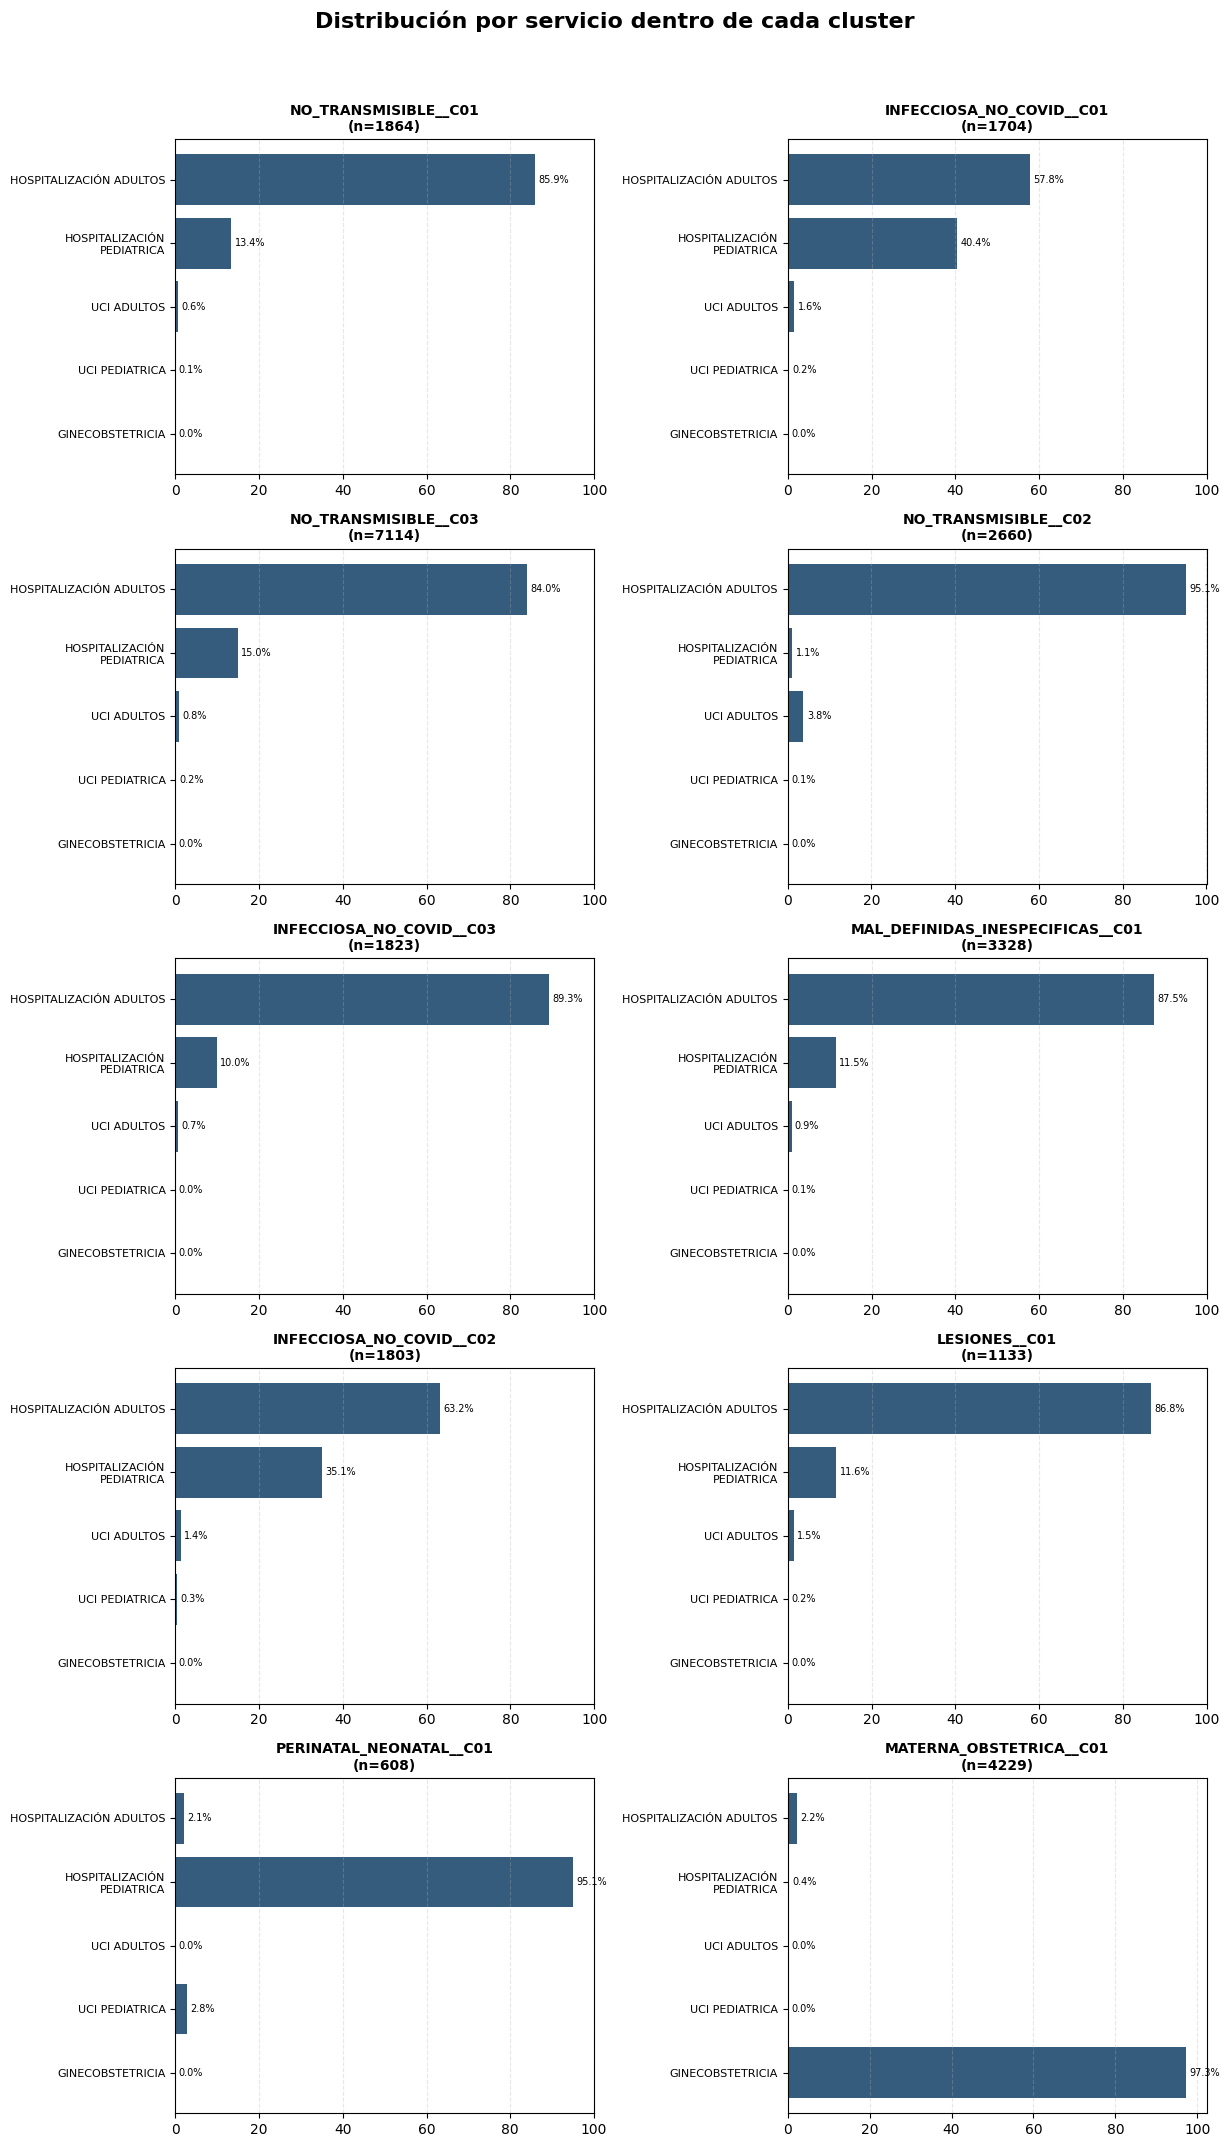

In [ ]:
# =========================================================
# BLOQUE G5. PANEL POR SERVICIO
# =========================================================

graficar_paneles_por_cluster(
    df=df_graf[df_graf[CLUSTER_FINAL_COL].isin(orden_clusters)].copy(),
    cluster_col=CLUSTER_FINAL_COL,
    var_col="servicio_desc",
    categorias_ordenadas=categorias_servicio,
    titulo_general="Distribución por servicio dentro de cada cluster",
    color="#355C7D",
    ncols=2,
    figsize_por_panel=(6.2, 4.2),
    mostrar_pct=True,
    excluir_sin_dato=False
)

In [ ]:
# =========================================================
# BLOQUE G6. CATEGORÍAS DE EDAD
# =========================================================

categorias_edad = [
    "0-4", "5-9", "10-14", "15-19", "20-24", "25-29", "30-34",
    "35-39", "40-44", "45-49", "50-54", "55-59", "60-64",
    "65-69", "70-74", "75-79", "80 Y MÁS", "SIN_DATO"
]

categorias_edad = [x for x in categorias_edad if x in df_graf["grupo_edad_desc"].astype(str).unique()]

categorias_edad

['0-4',
 '5-9',
 '10-14',
 '15-19',
 '20-24',
 '25-29',
 '30-34',
 '35-39',
 '40-44',
 '45-49',
 '50-54',
 '55-59',
 '60-64',
 '65-69',
 '70-74',
 '75-79',
 '80 Y MÁS']

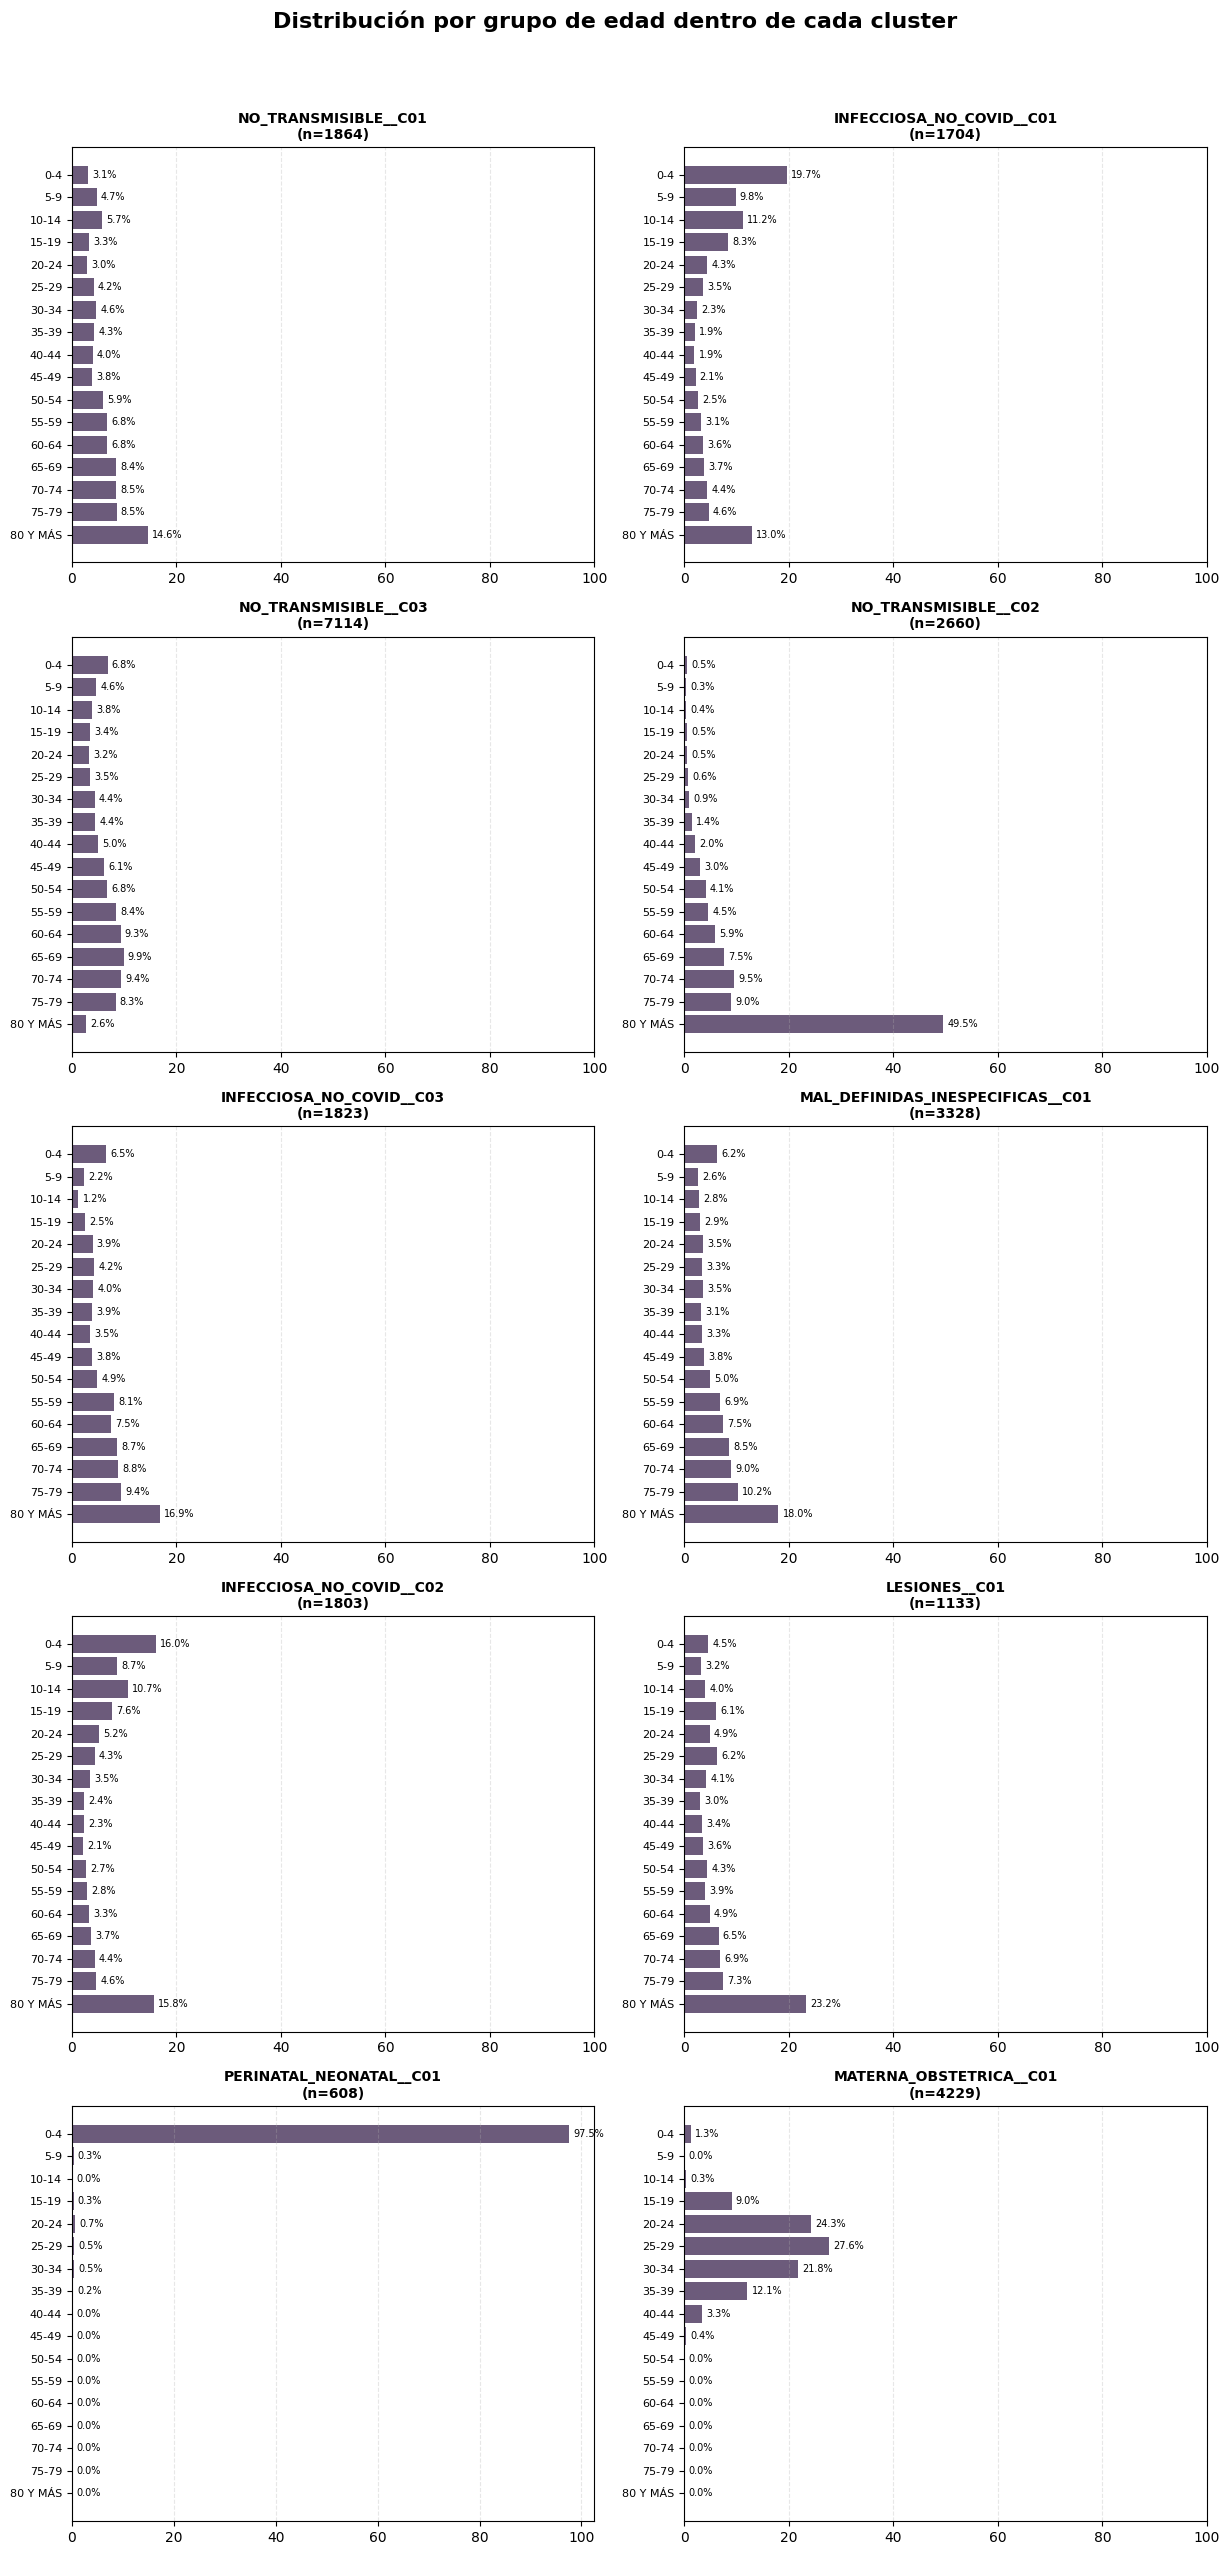

In [ ]:
# =========================================================
# BLOQUE G7. PANEL POR GRUPO DE EDAD
# =========================================================

graficar_paneles_por_cluster(
    df=df_graf[df_graf[CLUSTER_FINAL_COL].isin(orden_clusters)].copy(),
    cluster_col=CLUSTER_FINAL_COL,
    var_col="grupo_edad_desc",
    categorias_ordenadas=categorias_edad,
    titulo_general="Distribución por grupo de edad dentro de cada cluster",
    color="#6C5B7B",
    ncols=2,
    figsize_por_panel=(6.2, 5.0),
    mostrar_pct=True,
    excluir_sin_dato=False
)

In [ ]:
# =========================================================
# BLOQUE G8. TOP UO MÉDICAS
# =========================================================

top_uo = (
    df_graf["uo_desc"]
    .astype(str)
    .value_counts()
    .head(12)
    .index
    .tolist()
)

top_uo

['1 UM H MEDICINA INTERNA',
 '1 UM H GINECO-OBSTETRICIA',
 '1 UM H PEDIATRIA',
 '1 UM H CX GENERAL',
 '1 UM H UROLOGIA',
 '1 UM H ANEST/CLINICA DEL DOLOR',
 '1 UM H ORTOPEDIA',
 '1 UM H NEUROCIRUGIA',
 '1 UM H HEMATO-ONCO PEDIAT',
 '1 UM H RADIOL. INTERVENCIONIST',
 '1 UM H URGENCIOLOGIA',
 '1 UM H CX CABEZA Y CUELLO']

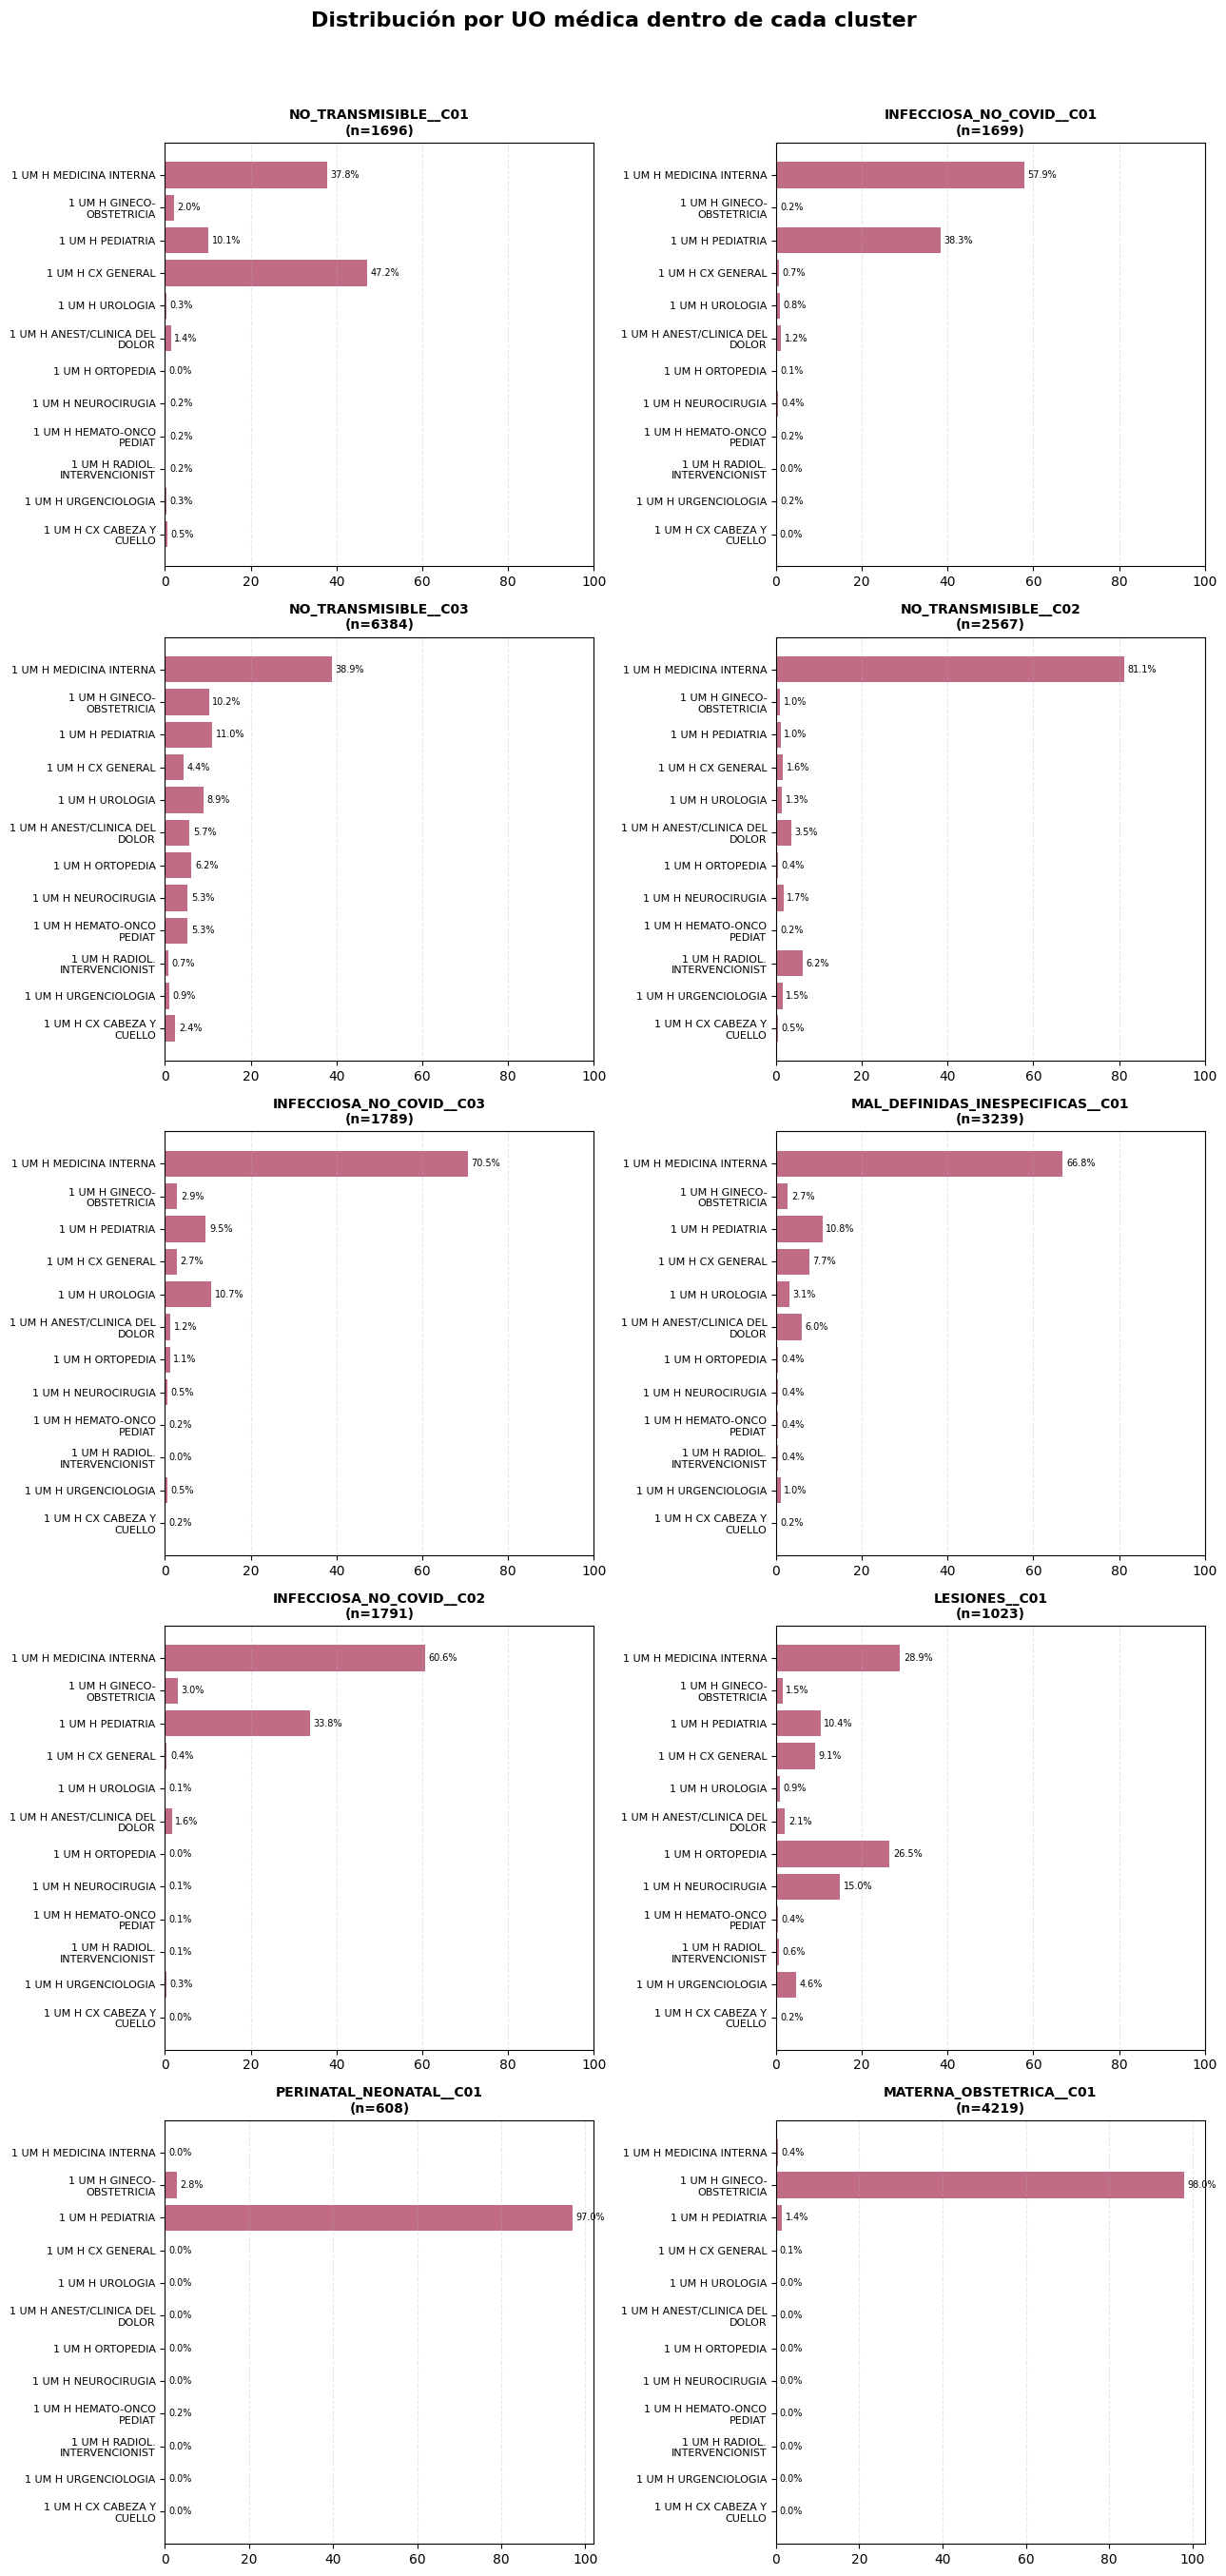

In [ ]:
# =========================================================
# BLOQUE G9. PANEL POR UO MÉDICA
# =========================================================

graficar_paneles_por_cluster(
    df=df_graf[df_graf["uo_desc"].isin(top_uo) & df_graf[CLUSTER_FINAL_COL].isin(orden_clusters)].copy(),
    cluster_col=CLUSTER_FINAL_COL,
    var_col="uo_desc",
    categorias_ordenadas=top_uo,
    titulo_general="Distribución por UO médica dentro de cada cluster",
    color="#C06C84",
    ncols=2,
    figsize_por_panel=(6.5, 5.3),
    mostrar_pct=True,
    excluir_sin_dato=True
)

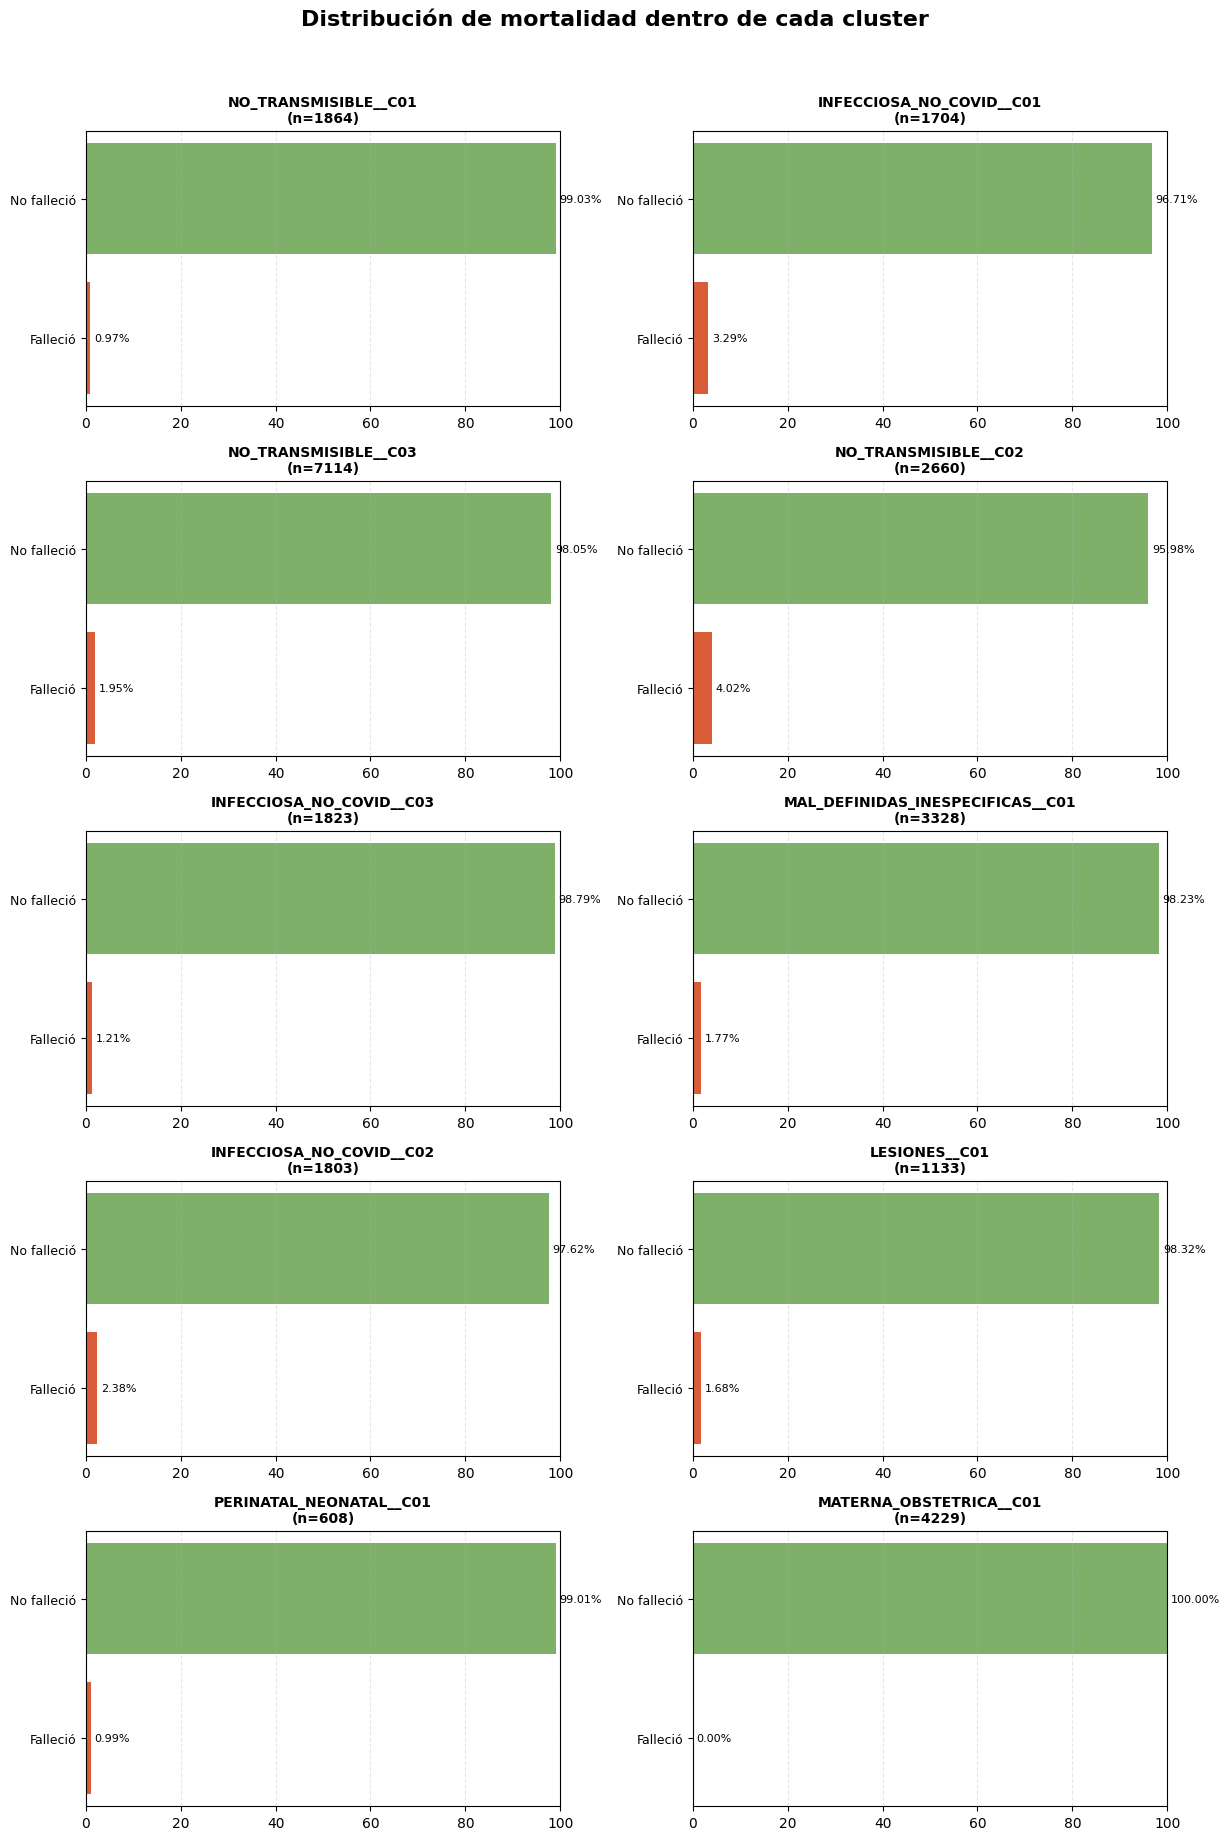

In [ ]:
# =========================================================
# BLOQUE G10. PANEL DE MORTALIDAD
# =========================================================

graficar_panel_mortalidad(
    df=df_graf[df_graf[CLUSTER_FINAL_COL].isin(orden_clusters)].copy(),
    cluster_col=CLUSTER_FINAL_COL,
    fall_col="fall_bin",
    titulo_general="Distribución de mortalidad dentro de cada cluster",
    color_vivo="#7FB069",
    color_fallecido="#D95D39",
    ncols=2,
    figsize_por_panel=(6.2, 3.6)
)

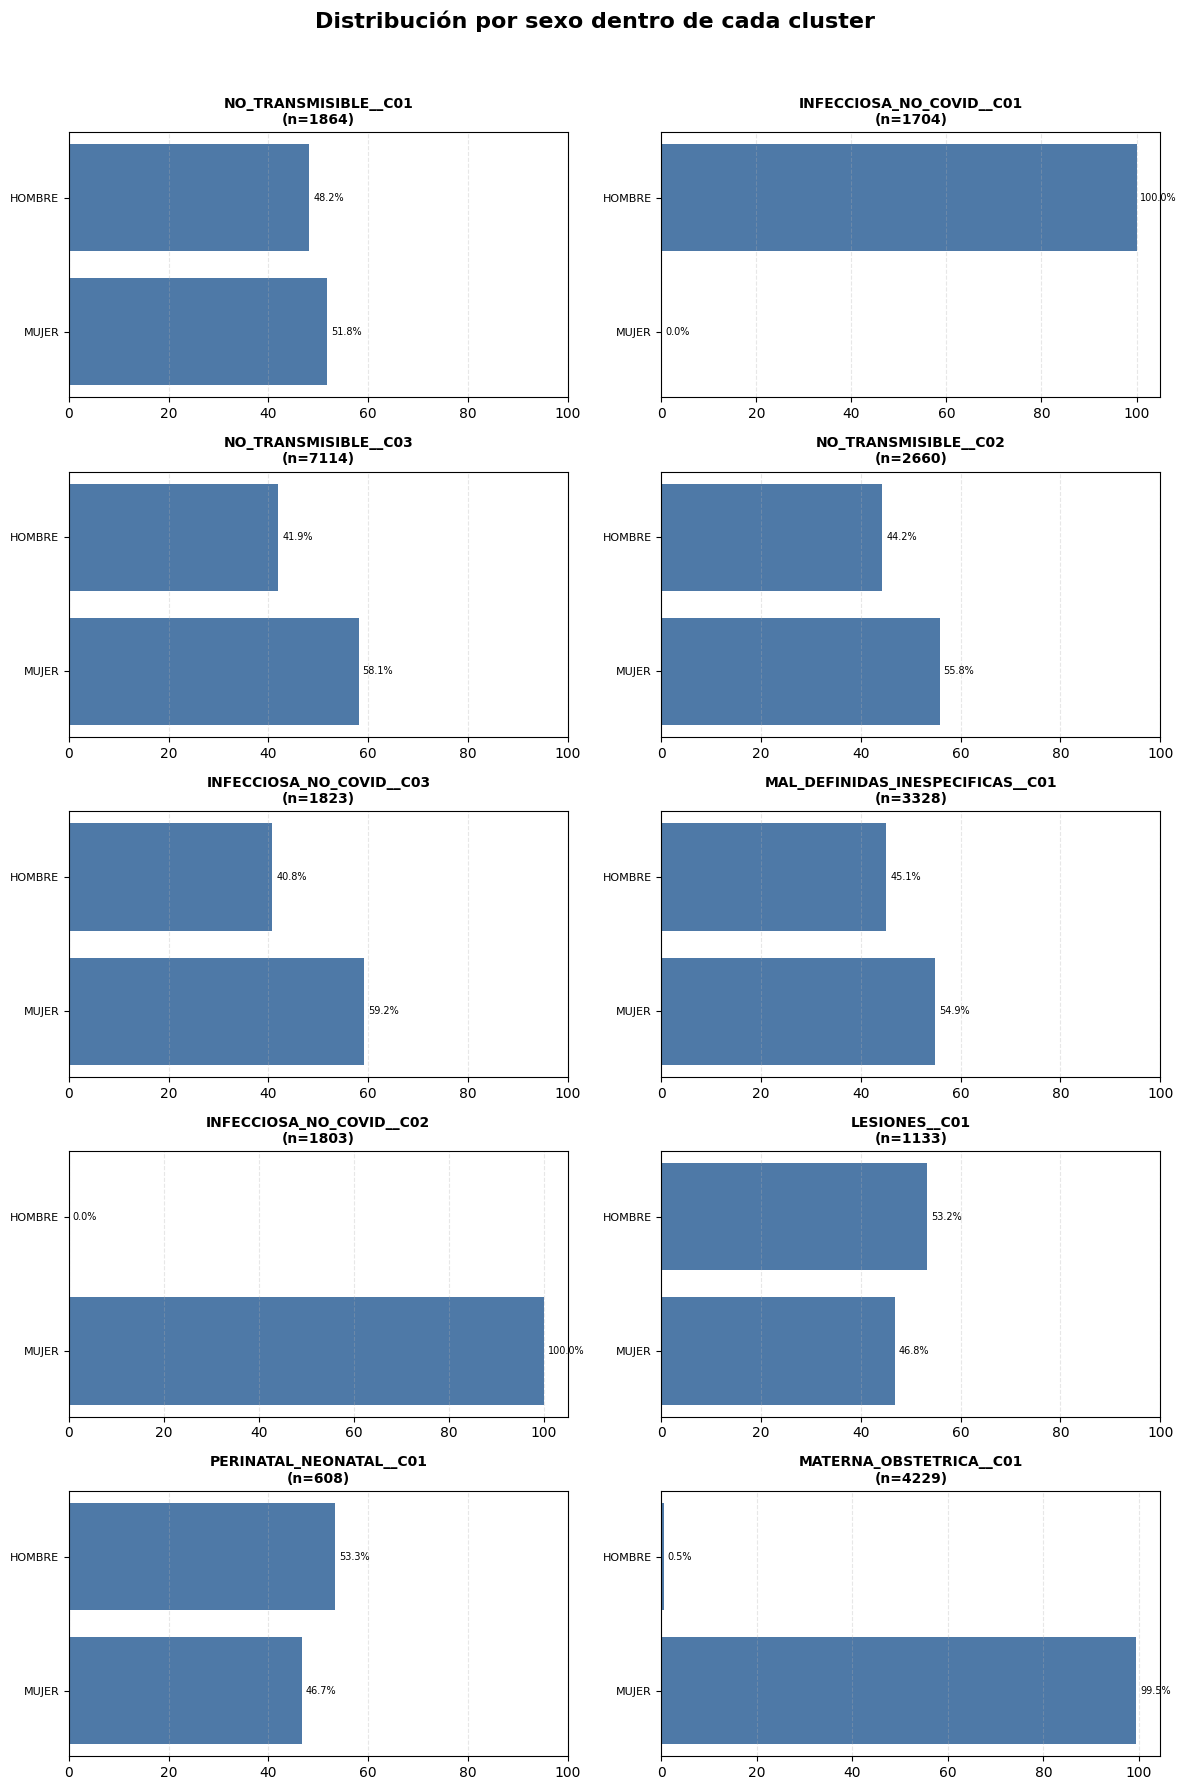

In [ ]:
# =========================================================
# BLOQUE G11. PANEL POR SEXO
# =========================================================

categorias_sexo = [x for x in ["HOMBRE", "MUJER", "SIN_DATO"] if x in df_graf["sexo_desc"].astype(str).unique()]

graficar_paneles_por_cluster(
    df=df_graf[df_graf[CLUSTER_FINAL_COL].isin(orden_clusters)].copy(),
    cluster_col=CLUSTER_FINAL_COL,
    var_col="sexo_desc",
    categorias_ordenadas=categorias_sexo,
    titulo_general="Distribución por sexo dentro de cada cluster",
    color="#4E79A7",
    ncols=2,
    figsize_por_panel=(6.0, 3.5),
    mostrar_pct=True,
    excluir_sin_dato=False
)

In [ ]:
# =========================================================
# MORTALIDAD GLOBAL DE LA COHORTE
# =========================================================

df_mort = df_principal_v2.copy()

n_total = len(df_mort)
muertes_totales = int(df_mort["fall_bin"].sum())
mortalidad_global_cohorte_pct = muertes_totales / n_total * 100

print("=== MORTALIDAD GLOBAL DE LA COHORTE ===")
print("n total:", n_total)
print("fallecimientos totales:", muertes_totales)
print("mortalidad global cohorte (%):", round(mortalidad_global_cohorte_pct, 2))

=== MORTALIDAD GLOBAL DE LA COHORTE ===
n total: 26266
fallecimientos totales: 469
mortalidad global cohorte (%): 1.79


In [ ]:
# =========================================================
# MORTALIDAD GLOBAL Y LOCAL POR CLUSTER FINAL
# =========================================================

tabla_mortalidad_cluster = (
    df_mort.groupby(["macro_grupo_cluster", "grupo_principal"], dropna=False)
    .agg(
        n_cluster=("grupo_principal", "size"),
        fallecimientos=("fall_bin", "sum")
    )
    .reset_index()
)

tabla_mortalidad_cluster["pct_del_total_pacientes"] = (
    tabla_mortalidad_cluster["n_cluster"] / n_total * 100
)

# Mortalidad local: dentro del cluster
tabla_mortalidad_cluster["mortalidad_local_pct"] = (
    tabla_mortalidad_cluster["fallecimientos"] / tabla_mortalidad_cluster["n_cluster"] * 100
)

# Aporte global a todas las muertes
tabla_mortalidad_cluster["aporte_global_muertes_pct"] = np.where(
    muertes_totales > 0,
    tabla_mortalidad_cluster["fallecimientos"] / muertes_totales * 100,
    np.nan
)

# Diferencia frente a la mortalidad global de la cohorte
tabla_mortalidad_cluster["dif_vs_global_pp"] = (
    tabla_mortalidad_cluster["mortalidad_local_pct"] - mortalidad_global_cohorte_pct
)

tabla_mortalidad_cluster = tabla_mortalidad_cluster.sort_values(
    ["macro_grupo_cluster", "mortalidad_local_pct", "n_cluster"],
    ascending=[True, False, False]
)

display(tabla_mortalidad_cluster.round(2))

,macro_grupo_cluster,grupo_principal,n_cluster,fallecimientos,pct_del_total_pacientes,mortalidad_local_pct,aporte_global_muertes_pct,dif_vs_global_pp
0,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C01,1704,56,6.49,3.29,11.94,1.50
1,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C02,1803,43,6.86,2.38,9.17,0.60
2,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C03,1823,22,6.94,1.21,4.69,-0.58
3,LESIONES,LESIONES__C01,1133,19,4.31,1.68,4.05,-0.11
4,MAL_DEFINIDAS_INESPECIFICAS,MAL_DEFINIDAS_INESPECIFICAS__C01,3328,59,12.67,1.77,12.58,-0.01
5,MATERNA_OBSTETRICA,MATERNA_OBSTETRICA__C01,4229,0,16.10,0.00,0.00,-1.79
7,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C02,2660,107,10.13,4.02,22.81,2.24
8,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C03,7114,139,27.08,1.95,29.64,0.17
6,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C01,1864,18,7.10,0.97,3.84,-0.82
9,PERINATAL_NEONATAL,PERINATAL_NEONATAL__C01,608,6,2.31,0.99,1.28,-0.80


In [ ]:
# =========================================================
# MORTALIDAD GLOBAL Y LOCAL POR MACROGRUPO
# =========================================================

tabla_mortalidad_macro = (
    df_mort.groupby("macro_grupo_cluster", dropna=False)
    .agg(
        n_macro=("macro_grupo_cluster", "size"),
        fallecimientos=("fall_bin", "sum")
    )
    .reset_index()
)

tabla_mortalidad_macro["pct_del_total_pacientes"] = (
    tabla_mortalidad_macro["n_macro"] / n_total * 100
)

tabla_mortalidad_macro["mortalidad_local_pct"] = (
    tabla_mortalidad_macro["fallecimientos"] / tabla_mortalidad_macro["n_macro"] * 100
)

tabla_mortalidad_macro["aporte_global_muertes_pct"] = np.where(
    muertes_totales > 0,
    tabla_mortalidad_macro["fallecimientos"] / muertes_totales * 100,
    np.nan
)

tabla_mortalidad_macro["dif_vs_global_pp"] = (
    tabla_mortalidad_macro["mortalidad_local_pct"] - mortalidad_global_cohorte_pct
)

tabla_mortalidad_macro = tabla_mortalidad_macro.sort_values(
    "mortalidad_local_pct", ascending=False
)

display(tabla_mortalidad_macro.round(2))

,macro_grupo_cluster,n_macro,fallecimientos,pct_del_total_pacientes,mortalidad_local_pct,aporte_global_muertes_pct,dif_vs_global_pp
0,INFECCIOSA_NO_COVID,5330,121,20.29,2.27,25.80,0.48
4,NO_TRANSMISIBLE,11638,264,44.31,2.27,56.29,0.48
2,MAL_DEFINIDAS_INESPECIFICAS,3328,59,12.67,1.77,12.58,-0.01
1,LESIONES,1133,19,4.31,1.68,4.05,-0.11
5,PERINATAL_NEONATAL,608,6,2.31,0.99,1.28,-0.80
3,MATERNA_OBSTETRICA,4229,0,16.10,0.00,0.00,-1.79


In [ ]:
# =========================================================
# TABLA RESUMIDA PARA PRESENTACIÓN
# =========================================================

tabla_presentacion_mort = tabla_mortalidad_cluster[
    [
        "macro_grupo_cluster",
        "grupo_principal",
        "n_cluster",
        "fallecimientos",
        "mortalidad_local_pct",
        "aporte_global_muertes_pct"
    ]
].copy()

tabla_presentacion_mort = tabla_presentacion_mort.sort_values(
    ["macro_grupo_cluster", "mortalidad_local_pct"],
    ascending=[True, False]
)

display(tabla_presentacion_mort.round(2))

,macro_grupo_cluster,grupo_principal,n_cluster,fallecimientos,mortalidad_local_pct,aporte_global_muertes_pct
0,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C01,1704,56,3.29,11.94
1,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C02,1803,43,2.38,9.17
2,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C03,1823,22,1.21,4.69
3,LESIONES,LESIONES__C01,1133,19,1.68,4.05
4,MAL_DEFINIDAS_INESPECIFICAS,MAL_DEFINIDAS_INESPECIFICAS__C01,3328,59,1.77,12.58
5,MATERNA_OBSTETRICA,MATERNA_OBSTETRICA__C01,4229,0,0.00,0.00
7,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C02,2660,107,4.02,22.81
8,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C03,7114,139,1.95,29.64
6,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C01,1864,18,0.97,3.84
9,PERINATAL_NEONATAL,PERINATAL_NEONATAL__C01,608,6,0.99,1.28


In [ ]:
# =========================================================
# CLASIFICACIÓN DEL CLUSTER SEGÚN MORTALIDAD
# =========================================================

tabla_mortalidad_cluster["nivel_mortalidad_relativa"] = np.select(
    [
        tabla_mortalidad_cluster["mortalidad_local_pct"] >= mortalidad_global_cohorte_pct * 1.5,
        tabla_mortalidad_cluster["mortalidad_local_pct"] >= mortalidad_global_cohorte_pct,
        tabla_mortalidad_cluster["mortalidad_local_pct"] >= mortalidad_global_cohorte_pct * 0.5
    ],
    [
        "MUY POR ENCIMA DEL GLOBAL",
        "POR ENCIMA DEL GLOBAL",
        "CERCA / POR DEBAJO MODERADO"
    ],
    default="MUY POR DEBAJO DEL GLOBAL"
)

display(
    tabla_mortalidad_cluster[
        [
            "macro_grupo_cluster",
            "grupo_principal",
            "n_cluster",
            "fallecimientos",
            "mortalidad_local_pct",
            "aporte_global_muertes_pct",
            "nivel_mortalidad_relativa"
        ]
    ].round(2)
)

,macro_grupo_cluster,grupo_principal,n_cluster,fallecimientos,mortalidad_local_pct,aporte_global_muertes_pct,nivel_mortalidad_relativa
0,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C01,1704,56,3.29,11.94,MUY POR ENCIMA DEL GLOBAL
1,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C02,1803,43,2.38,9.17,POR ENCIMA DEL GLOBAL
2,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID__C03,1823,22,1.21,4.69,CERCA / POR DEBAJO MODERADO
3,LESIONES,LESIONES__C01,1133,19,1.68,4.05,CERCA / POR DEBAJO MODERADO
4,MAL_DEFINIDAS_INESPECIFICAS,MAL_DEFINIDAS_INESPECIFICAS__C01,3328,59,1.77,12.58,CERCA / POR DEBAJO MODERADO
5,MATERNA_OBSTETRICA,MATERNA_OBSTETRICA__C01,4229,0,0.00,0.00,MUY POR DEBAJO DEL GLOBAL
7,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C02,2660,107,4.02,22.81,MUY POR ENCIMA DEL GLOBAL
8,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C03,7114,139,1.95,29.64,POR ENCIMA DEL GLOBAL
6,NO_TRANSMISIBLE,NO_TRANSMISIBLE__C01,1864,18,0.97,3.84,CERCA / POR DEBAJO MODERADO
9,PERINATAL_NEONATAL,PERINATAL_NEONATAL__C01,608,6,0.99,1.28,CERCA / POR DEBAJO MODERADO


In [ ]:
# =========================================================
# PANEL MORTALIDAD - PREPARACIÓN DE DATOS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import textwrap

df_mort_plot = df_principal_v2.copy()

n_total = len(df_mort_plot)
muertes_totales = int(df_mort_plot["fall_bin"].sum())
mortalidad_global_cohorte_pct = (muertes_totales / n_total) * 100

tabla_mortalidad_cluster_plot = (
    df_mort_plot.groupby(["macro_grupo_cluster", "grupo_principal"], dropna=False)
    .agg(
        n_cluster=("grupo_principal", "size"),
        fallecimientos=("fall_bin", "sum")
    )
    .reset_index()
)

tabla_mortalidad_cluster_plot["pct_del_total_pacientes"] = (
    tabla_mortalidad_cluster_plot["n_cluster"] / n_total * 100
)

tabla_mortalidad_cluster_plot["mortalidad_local_pct"] = (
    tabla_mortalidad_cluster_plot["fallecimientos"] / tabla_mortalidad_cluster_plot["n_cluster"] * 100
)

tabla_mortalidad_cluster_plot["aporte_global_muertes_pct"] = np.where(
    muertes_totales > 0,
    tabla_mortalidad_cluster_plot["fallecimientos"] / muertes_totales * 100,
    np.nan
)

tabla_mortalidad_cluster_plot["dif_vs_global_pp"] = (
    tabla_mortalidad_cluster_plot["mortalidad_local_pct"] - mortalidad_global_cohorte_pct
)

orden_clusters = [
    "NO_TRANSMISIBLE__C01",
    "NO_TRANSMISIBLE__C02",
    "NO_TRANSMISIBLE__C03",
    "INFECCIOSA_NO_COVID__C01",
    "INFECCIOSA_NO_COVID__C02",
    "INFECCIOSA_NO_COVID__C03",
    "MATERNA_OBSTETRICA__C01",
    "PERINATAL_NEONATAL__C01",
    "LESIONES__C01",
    "MAL_DEFINIDAS_INESPECIFICAS__C01",
]

tabla_mortalidad_cluster_plot = tabla_mortalidad_cluster_plot.set_index("grupo_principal").loc[
    [c for c in orden_clusters if c in tabla_mortalidad_cluster_plot["grupo_principal"].values]
].reset_index()

print("n total:", n_total)
print("muertes totales:", muertes_totales)
print("mortalidad global cohorte (%):", round(mortalidad_global_cohorte_pct, 2))

display(tabla_mortalidad_cluster_plot.round(2))

n total: 26266
muertes totales: 469
mortalidad global cohorte (%): 1.79


,grupo_principal,macro_grupo_cluster,n_cluster,fallecimientos,pct_del_total_pacientes,mortalidad_local_pct,aporte_global_muertes_pct,dif_vs_global_pp
0,NO_TRANSMISIBLE__C01,NO_TRANSMISIBLE,1864,18,7.10,0.97,3.84,-0.82
1,NO_TRANSMISIBLE__C02,NO_TRANSMISIBLE,2660,107,10.13,4.02,22.81,2.24
2,NO_TRANSMISIBLE__C03,NO_TRANSMISIBLE,7114,139,27.08,1.95,29.64,0.17
3,INFECCIOSA_NO_COVID__C01,INFECCIOSA_NO_COVID,1704,56,6.49,3.29,11.94,1.50
4,INFECCIOSA_NO_COVID__C02,INFECCIOSA_NO_COVID,1803,43,6.86,2.38,9.17,0.60
5,INFECCIOSA_NO_COVID__C03,INFECCIOSA_NO_COVID,1823,22,6.94,1.21,4.69,-0.58
6,MATERNA_OBSTETRICA__C01,MATERNA_OBSTETRICA,4229,0,16.10,0.00,0.00,-1.79
7,PERINATAL_NEONATAL__C01,PERINATAL_NEONATAL,608,6,2.31,0.99,1.28,-0.80
8,LESIONES__C01,LESIONES,1133,19,4.31,1.68,4.05,-0.11
9,MAL_DEFINIDAS_INESPECIFICAS__C01,MAL_DEFINIDAS_INESPECIFICAS,3328,59,12.67,1.77,12.58,-0.01


In [ ]:
# =========================================================
# FUNCIONES AUXILIARES PARA LOS PANELES
# =========================================================

def partir_texto(etiqueta, ancho=22):
    return "\n".join(textwrap.wrap(str(etiqueta), width=ancho))

def color_por_macro(nombre_cluster):
    if str(nombre_cluster).startswith("NO_TRANSMISIBLE"):
        return "#4C78A8"
    elif str(nombre_cluster).startswith("INFECCIOSA_NO_COVID"):
        return "#E45756"
    elif str(nombre_cluster).startswith("MATERNA_OBSTETRICA"):
        return "#72B7B2"
    elif str(nombre_cluster).startswith("PERINATAL_NEONATAL"):
        return "#54A24B"
    elif str(nombre_cluster).startswith("LESIONES"):
        return "#F58518"
    elif str(nombre_cluster).startswith("MAL_DEFINIDAS_INESPECIFICAS"):
        return "#B279A2"
    else:
        return "#9D9D9D"

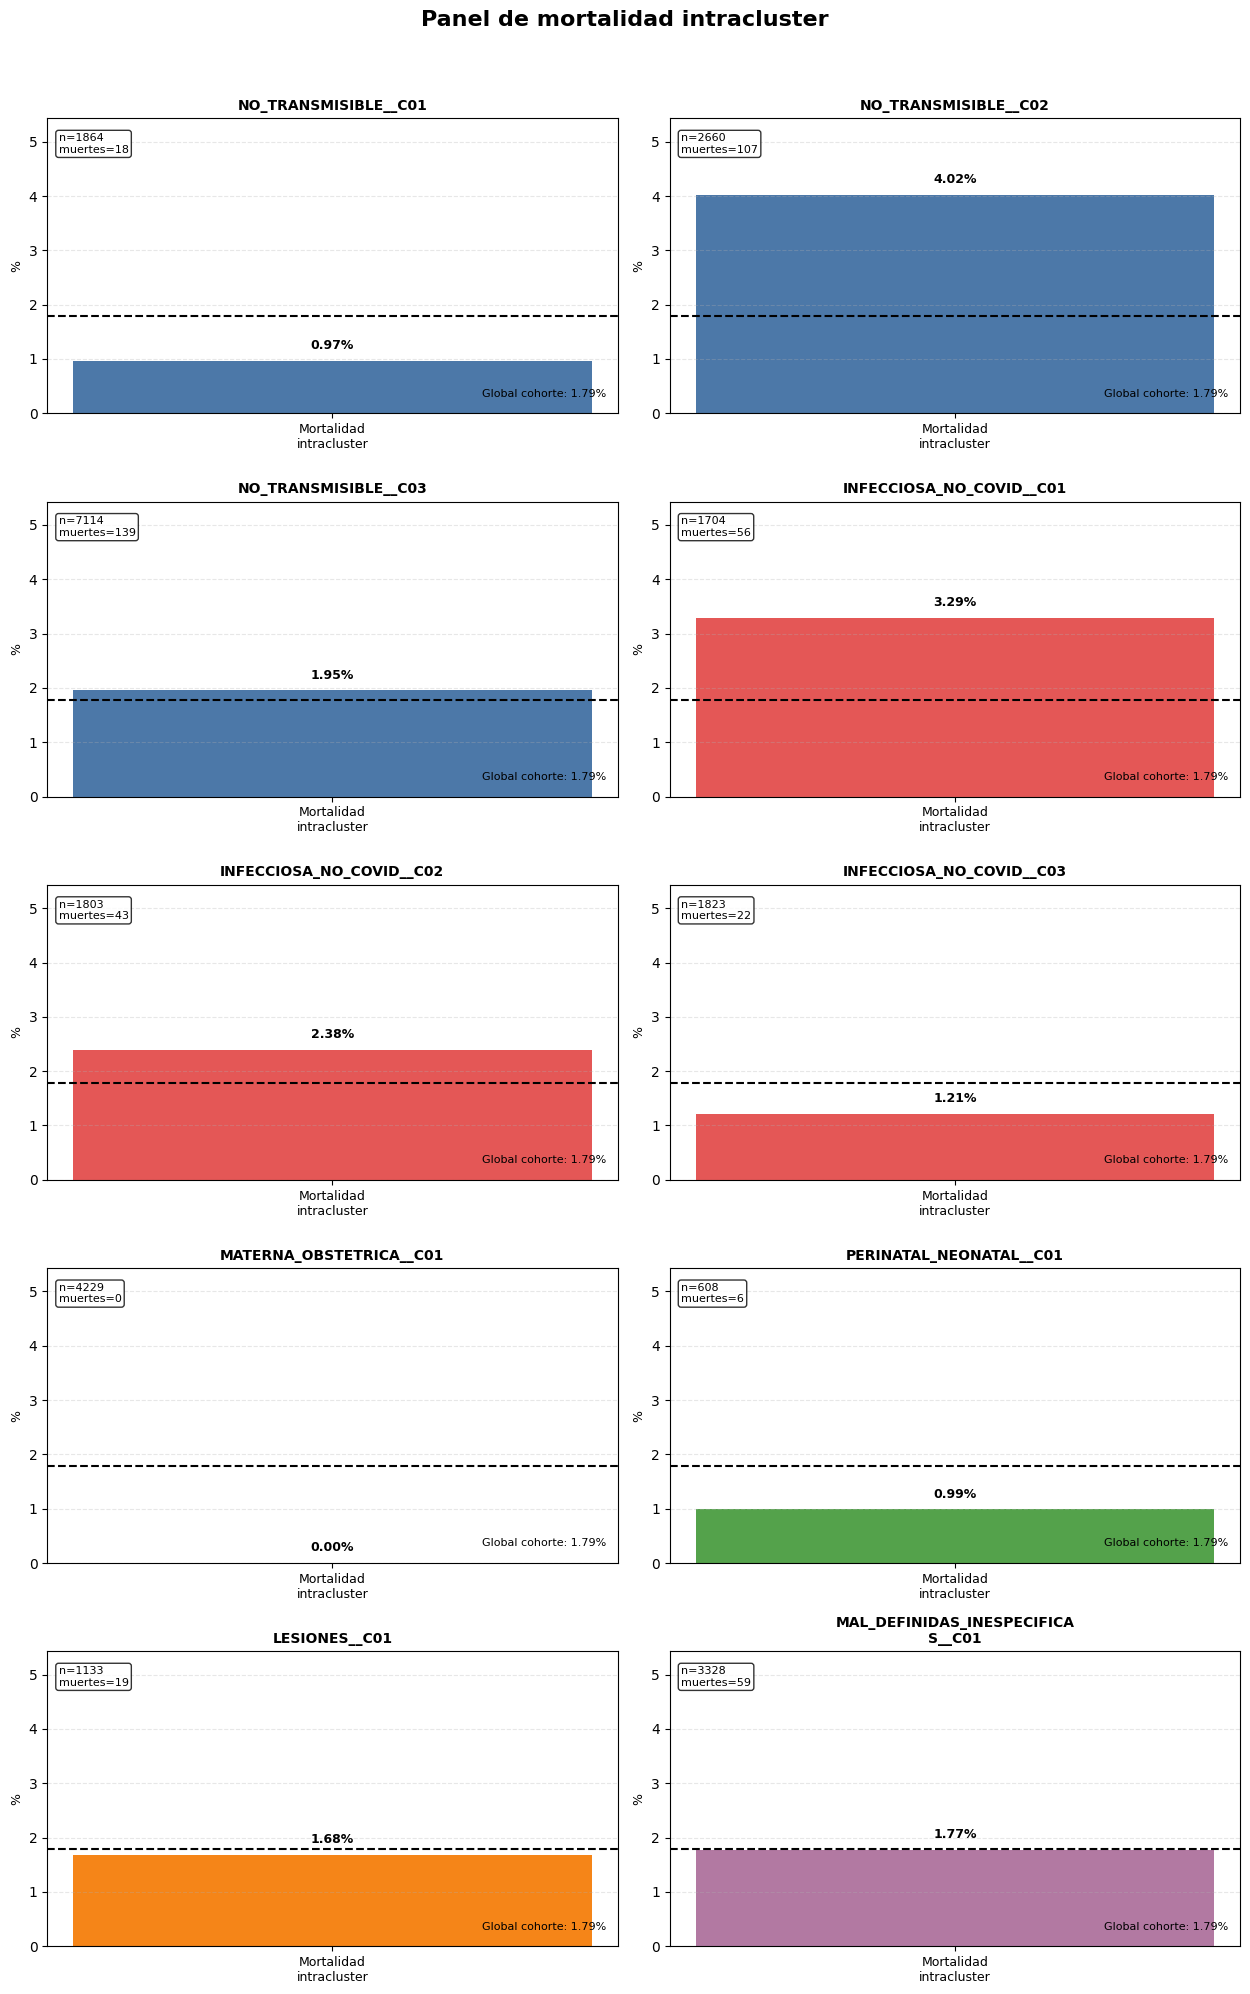

In [ ]:
# =========================================================
# PANEL 1. MORTALIDAD INTRACLUSTER
# =========================================================

def panel_mortalidad_intracluster(
    tabla,
    global_pct,
    ncols=2,
    figsize_por_panel=(6.2, 3.8)
):
    n = len(tabla)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_por_panel[0] * ncols, figsize_por_panel[1] * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    ymax = max(tabla["mortalidad_local_pct"].max(), global_pct) * 1.35

    for i, (_, row) in enumerate(tabla.iterrows()):
        ax = axes[i]

        cluster = row["grupo_principal"]
        valor = row["mortalidad_local_pct"]
        n_cluster = int(row["n_cluster"])
        fallecimientos = int(row["fallecimientos"])
        color = color_por_macro(cluster)

        ax.bar([0], [valor], width=0.55, color=color)
        ax.axhline(global_pct, linestyle="--", linewidth=1.5, color="black")

        ax.set_title(partir_texto(cluster, 26), fontsize=10, weight="bold")
        ax.set_xticks([0])
        ax.set_xticklabels(["Mortalidad\nintracluster"], fontsize=9)
        ax.set_ylim(0, ymax)
        ax.set_ylabel("%", fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        ax.text(0, valor + ymax*0.03, f"{valor:.2f}%", ha="center", va="bottom", fontsize=9, weight="bold")
        ax.text(
            0.02, 0.95,
            f"n={n_cluster}\nmuertes={fallecimientos}",
            transform=ax.transAxes,
            ha="left", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
        )

        ax.text(
            0.98, 0.05,
            f"Global cohorte: {global_pct:.2f}%",
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8
        )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Panel de mortalidad intracluster", fontsize=16, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

panel_mortalidad_intracluster(
    tabla=tabla_mortalidad_cluster_plot,
    global_pct=mortalidad_global_cohorte_pct,
    ncols=2,
    figsize_por_panel=(6.3, 3.9)
)

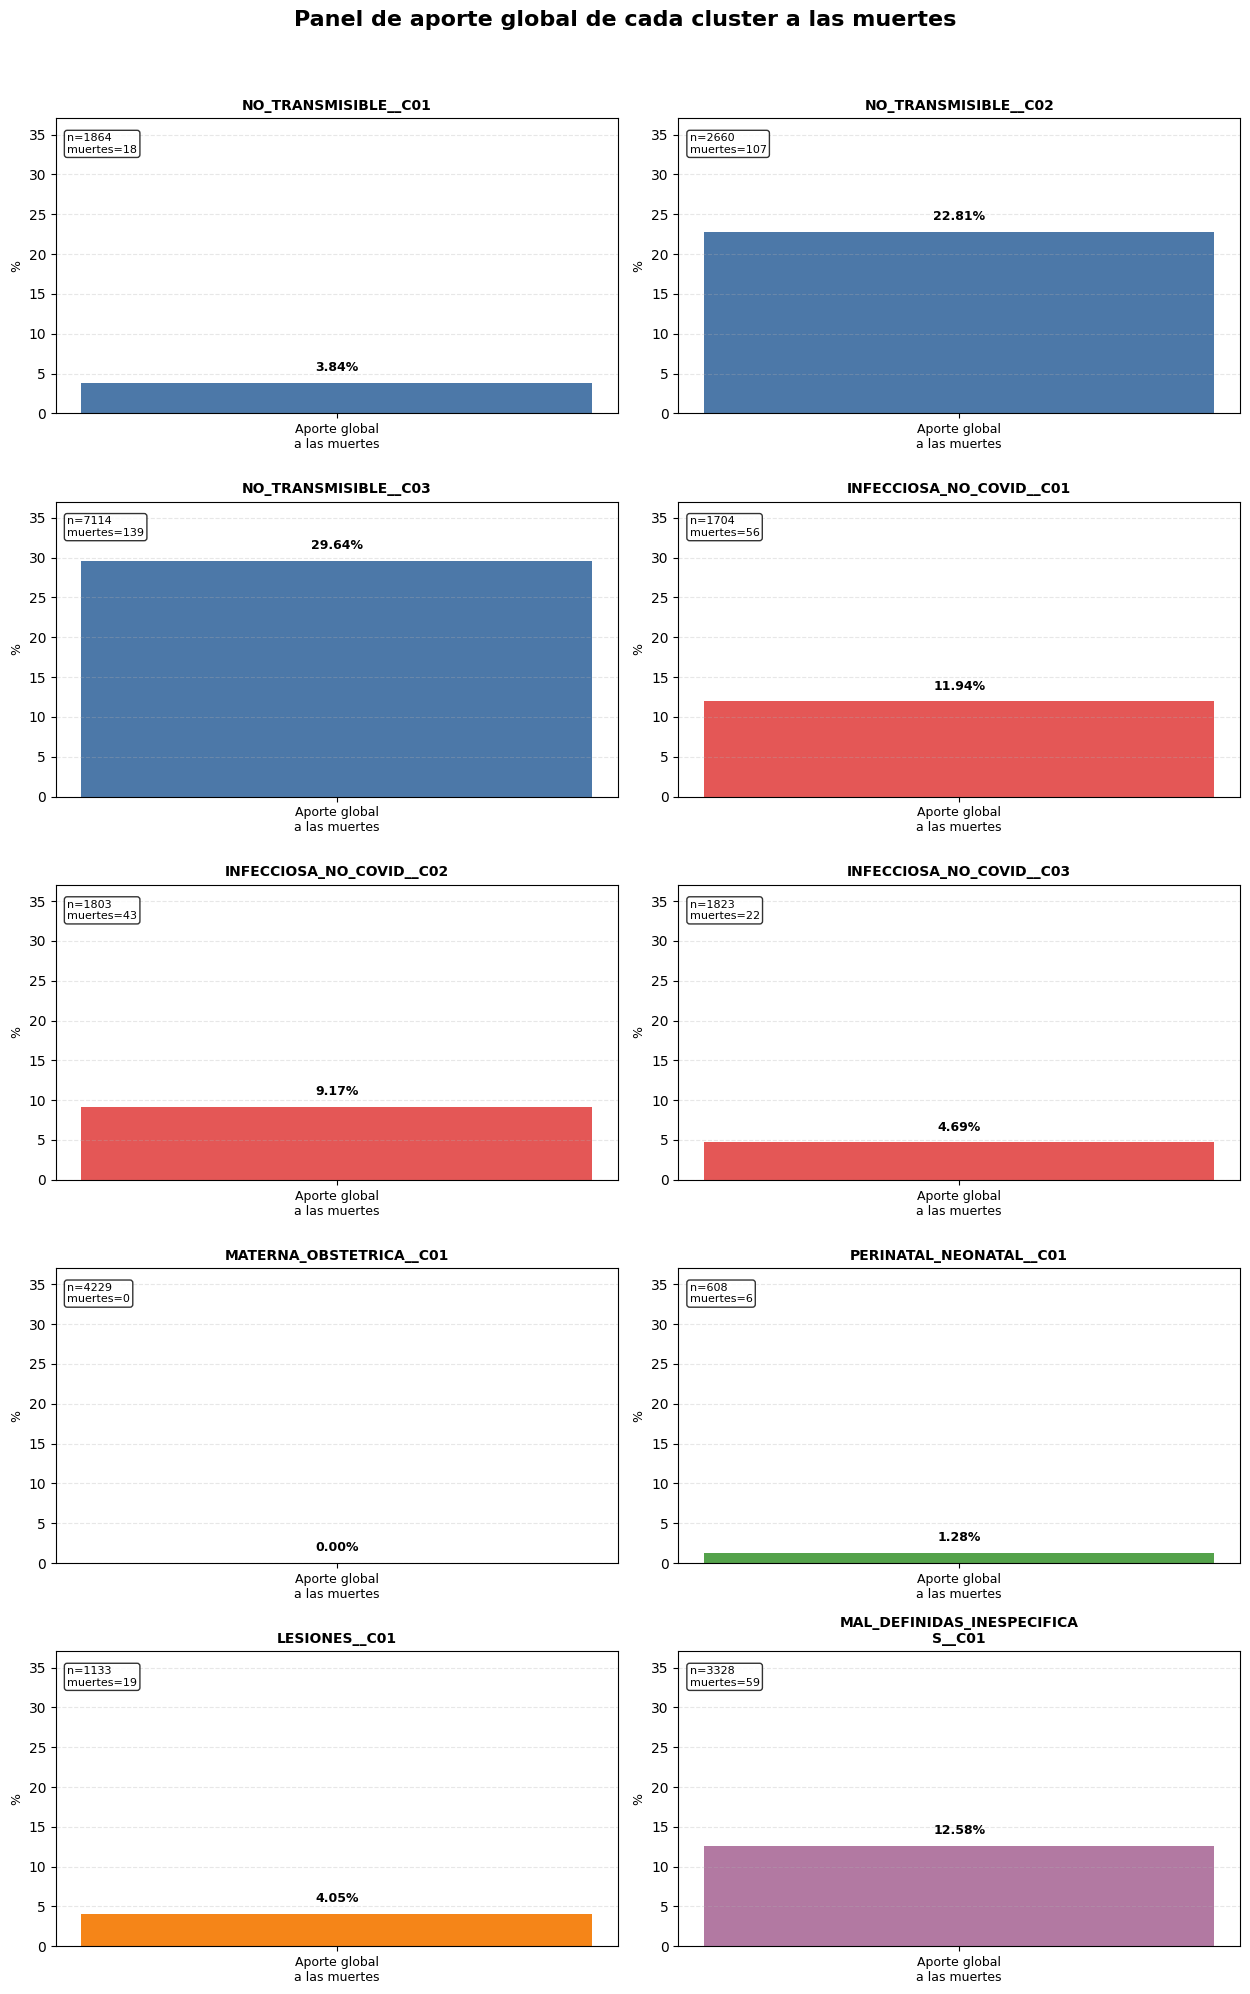

In [ ]:
# =========================================================
# PANEL 2. APORTE GLOBAL DE CADA CLUSTER A LAS MUERTES
# =========================================================

def panel_aporte_global_muertes(
    tabla,
    ncols=2,
    figsize_por_panel=(6.2, 3.8)
):
    n = len(tabla)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_por_panel[0] * ncols, figsize_por_panel[1] * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    ymax = tabla["aporte_global_muertes_pct"].max() * 1.25

    for i, (_, row) in enumerate(tabla.iterrows()):
        ax = axes[i]

        cluster = row["grupo_principal"]
        valor = row["aporte_global_muertes_pct"]
        n_cluster = int(row["n_cluster"])
        fallecimientos = int(row["fallecimientos"])
        color = color_por_macro(cluster)

        ax.bar([0], [valor], width=0.55, color=color)

        ax.set_title(partir_texto(cluster, 26), fontsize=10, weight="bold")
        ax.set_xticks([0])
        ax.set_xticklabels(["Aporte global\na las muertes"], fontsize=9)
        ax.set_ylim(0, ymax)
        ax.set_ylabel("%", fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        ax.text(0, valor + ymax*0.03, f"{valor:.2f}%", ha="center", va="bottom", fontsize=9, weight="bold")
        ax.text(
            0.02, 0.95,
            f"n={n_cluster}\nmuertes={fallecimientos}",
            transform=ax.transAxes,
            ha="left", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8)
        )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Panel de aporte global de cada cluster a las muertes", fontsize=16, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

panel_aporte_global_muertes(
    tabla=tabla_mortalidad_cluster_plot,
    ncols=2,
    figsize_por_panel=(6.3, 3.9)
)

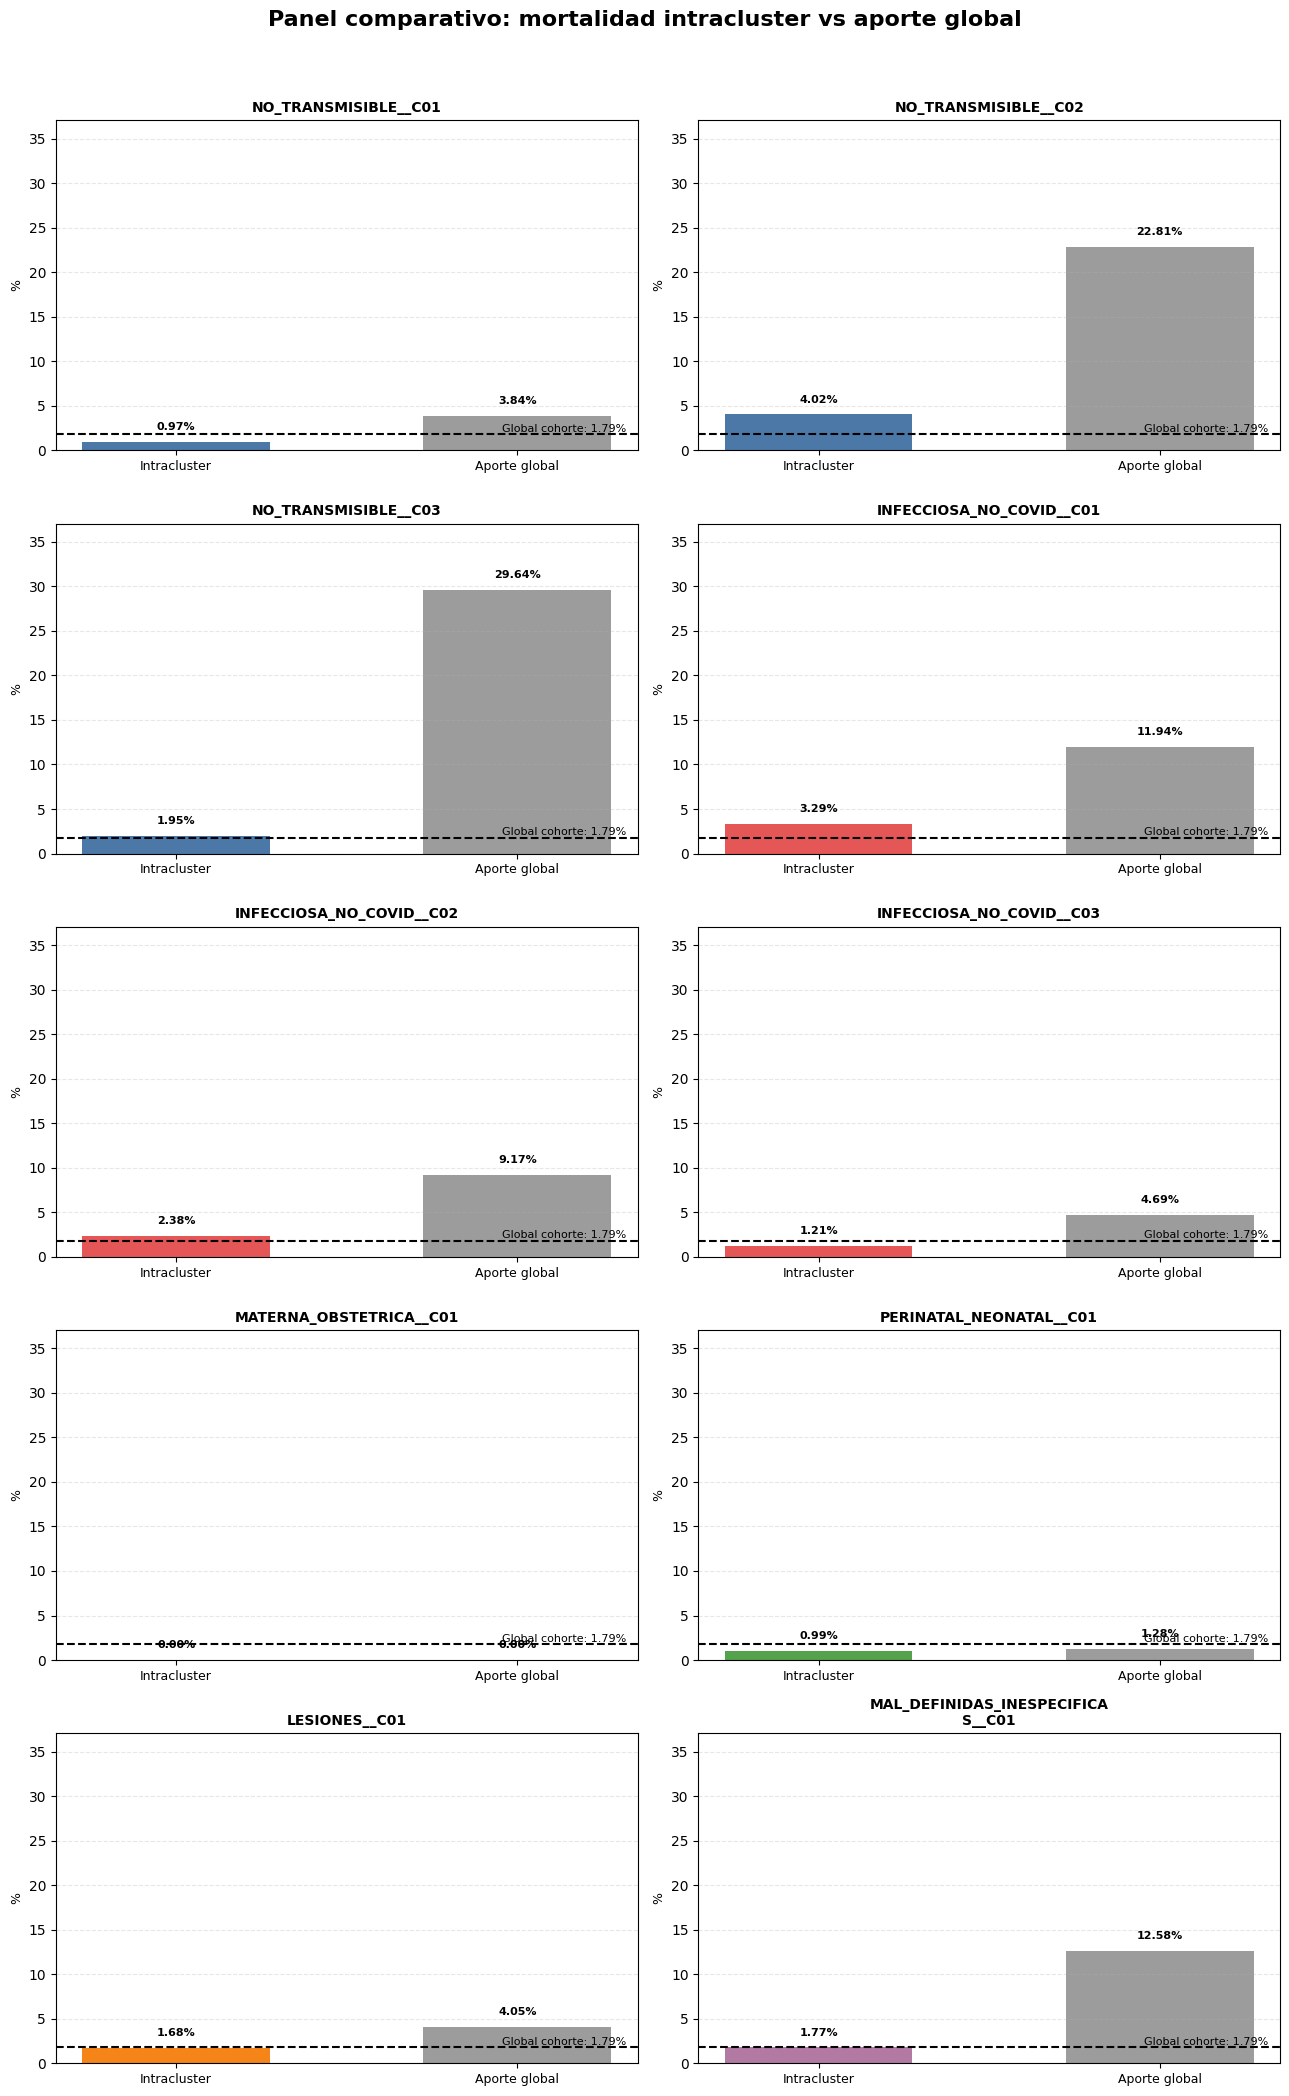

In [ ]:
# =========================================================
# PANEL 3. COMPARACIÓN INTRACLUSTER VS APORTE GLOBAL
# =========================================================

def panel_mortalidad_combinado(
    tabla,
    global_pct,
    ncols=2,
    figsize_por_panel=(6.5, 4.2)
):
    n = len(tabla)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_por_panel[0] * ncols, figsize_por_panel[1] * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    ymax = max(
        tabla["mortalidad_local_pct"].max(),
        tabla["aporte_global_muertes_pct"].max(),
        global_pct
    ) * 1.25

    for i, (_, row) in enumerate(tabla.iterrows()):
        ax = axes[i]

        cluster = row["grupo_principal"]
        local = row["mortalidad_local_pct"]
        aporte = row["aporte_global_muertes_pct"]
        color = color_por_macro(cluster)

        x = np.arange(2)
        vals = [local, aporte]

        ax.bar(x, vals, width=0.55, color=[color, "#9C9C9C"])
        ax.axhline(global_pct, linestyle="--", linewidth=1.5, color="black")

        ax.set_title(partir_texto(cluster, 26), fontsize=10, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(["Intracluster", "Aporte global"], fontsize=9)
        ax.set_ylim(0, ymax)
        ax.set_ylabel("%", fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        for xi, v in zip(x, vals):
            ax.text(xi, v + ymax*0.03, f"{v:.2f}%", ha="center", va="bottom", fontsize=8, weight="bold")

        ax.text(
            0.98, 0.05,
            f"Global cohorte: {global_pct:.2f}%",
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8
        )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Panel comparativo: mortalidad intracluster vs aporte global", fontsize=16, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

panel_mortalidad_combinado(
    tabla=tabla_mortalidad_cluster_plot,
    global_pct=mortalidad_global_cohorte_pct,
    ncols=2,
    figsize_por_panel=(6.5, 4.1)
)

Estudio de calidad del dato:

In [ ]:
# =========================================================
# QC1. BASE DE CALIDAD 2021-2024
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ---------- Base ----------
df_calidad = df0.copy() if "df0" in globals() else df_raw.copy()
df_calidad.columns = df_calidad.columns.str.strip()

# ---------- Helpers ----------
def parse_fecha_mixta(serie):
    s = serie.copy()

    # intento texto / fecha normal
    dt_texto = pd.to_datetime(s, errors="coerce", dayfirst=True)

    # intento serial de excel
    s_num = pd.to_numeric(s, errors="coerce")
    dt_excel = pd.to_datetime(s_num, unit="D", origin="1899-12-30", errors="coerce")

    return dt_texto.fillna(dt_excel)

def mapear_gran_causa_original(txt):
    txt = limpiar_texto(txt)

    if txt == "" or txt == "NAN" or txt == "NONE":
        return np.nan

    if "COVID" in txt or "SARS" in txt or "CORONAVIRUS" in txt:
        return "INFECCIOSA_NO_COVID"

    if "NO TRANSMISIBLE" in txt:
        return "NO_TRANSMISIBLE"

    if "TRANSMISIBLE" in txt or "INFECC" in txt or "PARASIT" in txt:
        return "INFECCIOSA_NO_COVID"

    if "MATERNA" in txt or "OBSTET" in txt:
        return "MATERNA_OBSTETRICA"

    if "PERINATAL" in txt or "NEONAT" in txt:
        return "PERINATAL_NEONATAL"

    if "LESION" in txt or "TRAUMA" in txt or "CAUSA EXTERNA" in txt:
        return "LESIONES"

    if "MAL DEFINIDA" in txt or "INESPEC" in txt or "SINTOMA" in txt or "SIGNO" in txt:
        return "MAL_DEFINIDAS_INESPECIFICAS"

    return np.nan

def es_obstetrica_sin_otra_especificacion(nombre):
    nombre = limpiar_texto(nombre)

    claves_obst = [
        "CESAREA", "PARTO", "OBSTET", "PUERPER", "EMBARAZ", "GESTACION", "ABORTO"
    ]
    claves_soe = [
        "SIN OTRA ESPECIFICACION", "NO ESPECIFICADA", "NO ESPECIFICADO",
        "NO ESPECIFICADAS", "NO ESPECIFICADOS"
    ]

    return any(k in nombre for k in claves_obst) and any(k in nombre for k in claves_soe)

def tabla_por_anio(df, flag_col, nombre_indicador, universo_mask=None):
    base = df.copy() if universo_mask is None else df[universo_mask].copy()

    out = (
        base.groupby("anio_analisis", dropna=False)
        .agg(
            n_total=("anio_analisis", "size"),
            eventos=(flag_col, "sum")
        )
        .reset_index()
        .sort_values("anio_analisis")
    )
    out["pct"] = out["eventos"] / out["n_total"] * 100
    out["indicador"] = nombre_indicador
    return out

def comparar_periodos_binario(df, flag_col, nombre_indicador, universo_mask=None):
    base = df.copy() if universo_mask is None else df[universo_mask].copy()
    base = base[base["anio_analisis"].isin([2021, 2022, 2023, 2024])].copy()

    base["periodo_cmp"] = np.where(base["anio_analisis"] == 2024, "2024", "2021-2023")

    tab = (
        base.groupby("periodo_cmp", dropna=False)
        .agg(
            n_total=("periodo_cmp", "size"),
            eventos=(flag_col, "sum")
        )
        .reset_index()
    )
    tab["no_eventos"] = tab["n_total"] - tab["eventos"]
    tab["pct"] = tab["eventos"] / tab["n_total"] * 100
    tab["indicador"] = nombre_indicador

    # ordenar
    tab["periodo_cmp"] = pd.Categorical(tab["periodo_cmp"], categories=["2021-2023", "2024"], ordered=True)
    tab = tab.sort_values("periodo_cmp").reset_index(drop=True)

    # chi-cuadrado 2x2
    matriz = tab[["eventos", "no_eventos"]].to_numpy()
    chi2, pval, _, _ = chi2_contingency(matriz)

    pct_pre = tab.loc[tab["periodo_cmp"] == "2021-2023", "pct"].iloc[0]
    pct_2024 = tab.loc[tab["periodo_cmp"] == "2024", "pct"].iloc[0]

    tab["chi2_p"] = pval
    tab["dif_pp_2024_menos_pre"] = pct_2024 - pct_pre

    return tab

# ---------- Año ----------
if COL_ANIO is not None and COL_ANIO in df_calidad.columns:
    df_calidad["anio_analisis"] = pd.to_numeric(df_calidad[COL_ANIO], errors="coerce")
elif COL_FECHA_INGRESO is not None and COL_FECHA_INGRESO in df_calidad.columns:
    df_calidad["fecha_ingreso_dt"] = parse_fecha_mixta(df_calidad[COL_FECHA_INGRESO])
    df_calidad["anio_analisis"] = df_calidad["fecha_ingreso_dt"].dt.year
else:
    raise ValueError("No encontré ni COL_ANIO ni COL_FECHA_INGRESO para construir el año.")

df_calidad = df_calidad[df_calidad["anio_analisis"].isin([2021, 2022, 2023, 2024])].copy()
df_calidad["anio_analisis"] = df_calidad["anio_analisis"].astype(int)

# ---------- Variables base ----------
df_calidad["dx_codigo_qc"] = df_calidad[COL_DX_COD].astype(str).fillna("")
df_calidad["dx_nombre_qc"] = df_calidad[COL_DX_NOM].astype(str).fillna("")
df_calidad["gran_causa_original_qc"] = df_calidad[COL_CAUSA_OLD].astype(str).fillna("")

# ---------- Reclasificación consistente para todos los años ----------
df_calidad["clasificacion_reconstruida_qc"] = df_calidad.apply(
    lambda x: clasificacion_clinica_reconstruida(x["dx_codigo_qc"], x["dx_nombre_qc"]),
    axis=1
)

# ---------- Mapeo de gran causa original ----------
df_calidad["gran_causa_original_map"] = df_calidad["gran_causa_original_qc"].apply(mapear_gran_causa_original)

# Para discrepancia, COVID cuenta dentro del universo infeccioso
df_calidad["clasificacion_reconstruida_comp"] = df_calidad["clasificacion_reconstruida_qc"].replace({
    "COVID-19": "INFECCIOSA_NO_COVID"
})

df_calidad["flag_discrepancia_clinica_qc"] = np.where(
    df_calidad["gran_causa_original_map"].notna() &
    (df_calidad["gran_causa_original_map"] != df_calidad["clasificacion_reconstruida_comp"]),
    1, 0
)

# ---------- Mal definidas ----------
df_calidad["flag_mal_definida_qc"] = (
    df_calidad["clasificacion_reconstruida_qc"] == "MAL_DEFINIDAS_INESPECIFICAS"
).astype(int)

# ---------- Obstétricas "sin otra especificación" ----------
df_calidad["flag_materna_qc"] = (
    df_calidad["clasificacion_reconstruida_qc"] == "MATERNA_OBSTETRICA"
).astype(int)

df_calidad["flag_obstetrica_soe_qc"] = np.where(
    (df_calidad["flag_materna_qc"] == 1) &
    (df_calidad["dx_nombre_qc"].apply(es_obstetrica_sin_otra_especificacion)),
    1, 0
)

print("Base QC lista:", df_calidad.shape)
display(
    df_calidad[[
        "anio_analisis",
        "dx_codigo_qc",
        "dx_nombre_qc",
        "gran_causa_original_qc",
        "gran_causa_original_map",
        "clasificacion_reconstruida_qc",
        "flag_mal_definida_qc",
        "flag_discrepancia_clinica_qc",
        "flag_materna_qc",
        "flag_obstetrica_soe_qc"
    ]].head(10)
)

Base QC lista: (94134, 44)


,anio_analisis,dx_codigo_qc,dx_nombre_qc,gran_causa_original_qc,gran_causa_original_map,clasificacion_reconstruida_qc,flag_mal_definida_qc,flag_discrepancia_clinica_qc,flag_materna_qc,flag_obstetrica_soe_qc
0,2022,J440,ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICACON INF...,Enfermedades no transmisibles,NO_TRANSMISIBLE,INFECCIOSA_NO_COVID,0,1,0,0
1,2022,N390,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",Enfermedades no transmisibles,NO_TRANSMISIBLE,INFECCIOSA_NO_COVID,0,1,0,0
2,2022,R074,"DOLOR EN EL PECHO, NO ESPECIFICADO",Signos y síntomas mal definidos,MAL_DEFINIDAS_INESPECIFICAS,MAL_DEFINIDAS_INESPECIFICAS,1,0,0,0
3,2022,R400,SOMNOLENCIA,Signos y síntomas mal definidos,MAL_DEFINIDAS_INESPECIFICAS,MAL_DEFINIDAS_INESPECIFICAS,1,0,0,0
4,2022,C189,"TUMOR MALIGNO DEL COLON, PARTE NO ESPECIFICADA",Enfermedades no transmisibles,NO_TRANSMISIBLE,NO_TRANSMISIBLE,0,0,0,0
5,2022,C785,TUMOR MALIGNO SECUNDARIO DEL INTESTINO GRUESO ...,Enfermedades no transmisibles,NO_TRANSMISIBLE,NO_TRANSMISIBLE,0,0,0,0
6,2022,B349,"INFECCION VIRAL, NO ESPECIFICADA",Condiciones transmisibles y nutricionales,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID,0,0,0,0
7,2022,N390,"INFECCION DE VIAS URINARIAS, SITIO NO ESPECIFI...",Enfermedades no transmisibles,NO_TRANSMISIBLE,INFECCIOSA_NO_COVID,0,1,0,0
8,2022,J189,"NEUMONIA, NO ESPECIFICADA",Condiciones transmisibles y nutricionales,INFECCIOSA_NO_COVID,INFECCIOSA_NO_COVID,0,0,0,0
9,2022,M546,DOLOR EN LA COLUMNA DORSAL,Enfermedades no transmisibles,NO_TRANSMISIBLE,NO_TRANSMISIBLE,0,0,0,0


,anio_analisis,n_total,eventos,pct,indicador
0,2021,19885,1974,9.93,Mal definidas / inespecíficas
1,2022,23582,2876,12.20,Mal definidas / inespecíficas
2,2023,24387,3385,13.88,Mal definidas / inespecíficas
3,2024,26280,3328,12.66,Mal definidas / inespecíficas


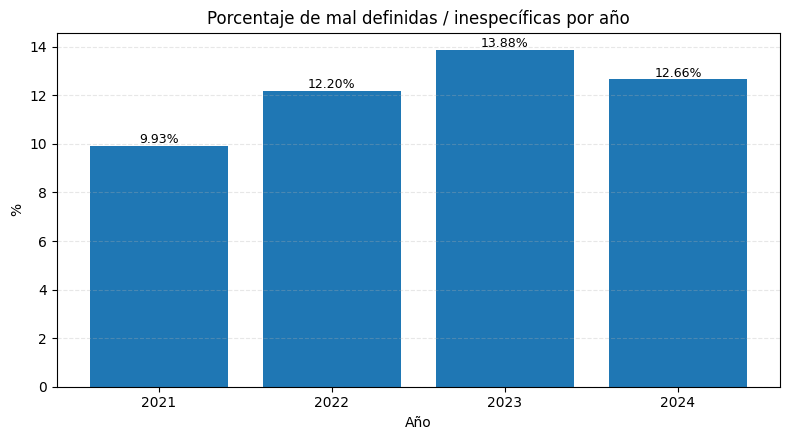

In [ ]:
# =========================================================
# QC2. MAL DEFINIDAS / INESPECÍFICAS POR AÑO
# =========================================================

tabla_maldef_anio = tabla_por_anio(
    df=df_calidad,
    flag_col="flag_mal_definida_qc",
    nombre_indicador="Mal definidas / inespecíficas"
)

display(tabla_maldef_anio.round(2))

plt.figure(figsize=(8, 4.5))
plt.bar(tabla_maldef_anio["anio_analisis"].astype(str), tabla_maldef_anio["pct"])
plt.title("Porcentaje de mal definidas / inespecíficas por año")
plt.ylabel("%")
plt.xlabel("Año")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, v in enumerate(tabla_maldef_anio["pct"]):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

,anio_analisis,n_total,eventos,pct,indicador
0,2021,19885,1937,9.74,Discrepancia clínica
1,2022,23582,2731,11.58,Discrepancia clínica
2,2023,24387,2795,11.46,Discrepancia clínica
3,2024,26280,3024,11.51,Discrepancia clínica


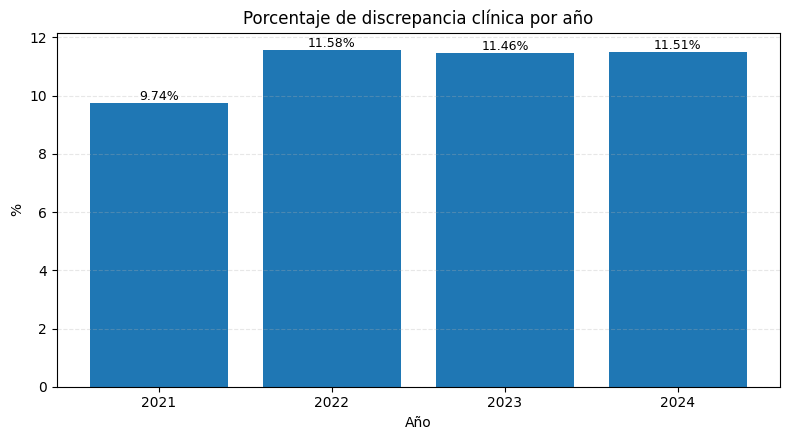

In [ ]:
# =========================================================
# QC3. DISCREPANCIA CLÍNICA POR AÑO
# =========================================================

tabla_discrep_anio = tabla_por_anio(
    df=df_calidad,
    flag_col="flag_discrepancia_clinica_qc",
    nombre_indicador="Discrepancia clínica"
)

display(tabla_discrep_anio.round(2))

plt.figure(figsize=(8, 4.5))
plt.bar(tabla_discrep_anio["anio_analisis"].astype(str), tabla_discrep_anio["pct"])
plt.title("Porcentaje de discrepancia clínica por año")
plt.ylabel("%")
plt.xlabel("Año")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, v in enumerate(tabla_discrep_anio["pct"]):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

,anio_analisis,n_total,eventos,pct,indicador
0,2021,3472,1620,46.66,"Obstétricas ""sin otra especificación"""
1,2022,4102,1858,45.29,"Obstétricas ""sin otra especificación"""
2,2023,4310,1820,42.23,"Obstétricas ""sin otra especificación"""
3,2024,4229,1824,43.13,"Obstétricas ""sin otra especificación"""


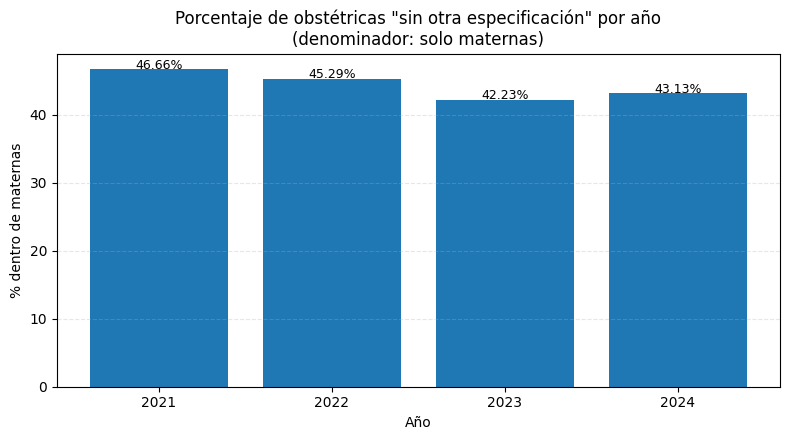

In [ ]:
# =========================================================
# QC4. OBSTÉTRICAS "SIN OTRA ESPECIFICACIÓN" POR AÑO
# =========================================================

tabla_obst_soe_anio = tabla_por_anio(
    df=df_calidad,
    flag_col="flag_obstetrica_soe_qc",
    nombre_indicador='Obstétricas "sin otra especificación"',
    universo_mask=(df_calidad["flag_materna_qc"] == 1)
)

display(tabla_obst_soe_anio.round(2))

plt.figure(figsize=(8, 4.5))
plt.bar(tabla_obst_soe_anio["anio_analisis"].astype(str), tabla_obst_soe_anio["pct"])
plt.title('Porcentaje de obstétricas "sin otra especificación" por año\n(denominador: solo maternas)')
plt.ylabel("% dentro de maternas")
plt.xlabel("Año")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, v in enumerate(tabla_obst_soe_anio["pct"]):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# QC5. COMPARACIÓN 2021-2023 VS 2024
# =========================================================

comparacion_maldef = comparar_periodos_binario(
    df=df_calidad,
    flag_col="flag_mal_definida_qc",
    nombre_indicador="Mal definidas / inespecíficas"
)

comparacion_discrep = comparar_periodos_binario(
    df=df_calidad,
    flag_col="flag_discrepancia_clinica_qc",
    nombre_indicador="Discrepancia clínica"
)

comparacion_obst_soe = comparar_periodos_binario(
    df=df_calidad,
    flag_col="flag_obstetrica_soe_qc",
    nombre_indicador='Obstétricas "sin otra especificación"',
    universo_mask=(df_calidad["flag_materna_qc"] == 1)
)

print("=== Mal definidas / inespecíficas ===")
display(comparacion_maldef.round(4))

print("\n=== Discrepancia clínica ===")
display(comparacion_discrep.round(4))

print('\n=== Obstétricas "sin otra especificación" ===')
display(comparacion_obst_soe.round(4))

=== Mal definidas / inespecíficas ===


,periodo_cmp,n_total,eventos,no_eventos,pct,indicador,chi2_p,dif_pp_2024_menos_pre
0,2021-2023,67854,8235,59619,12.1364,Mal definidas / inespecíficas,0.0278,0.5273
1,2024,26280,3328,22952,12.6636,Mal definidas / inespecíficas,0.0278,0.5273



=== Discrepancia clínica ===


,periodo_cmp,n_total,eventos,no_eventos,pct,indicador,chi2_p,dif_pp_2024_menos_pre
0,2021-2023,67854,7463,60391,10.9986,Discrepancia clínica,0.027,0.5082
1,2024,26280,3024,23256,11.5068,Discrepancia clínica,0.027,0.5082



=== Obstétricas "sin otra especificación" ===


,periodo_cmp,n_total,eventos,no_eventos,pct,indicador,chi2_p,dif_pp_2024_menos_pre
0,2021-2023,11884,5298,6586,44.5809,"Obstétricas ""sin otra especificación""",0.1068,-1.4502
1,2024,4229,1824,2405,43.1308,"Obstétricas ""sin otra especificación""",0.1068,-1.4502


In [ ]:
# =========================================================
# QC6. TABLA CONSOLIDADA 2021-2023 VS 2024
# =========================================================

def resumir_cmp(tabla_cmp):
    indicador = tabla_cmp["indicador"].iloc[0]
    pct_pre = tabla_cmp.loc[tabla_cmp["periodo_cmp"] == "2021-2023", "pct"].iloc[0]
    pct_2024 = tabla_cmp.loc[tabla_cmp["periodo_cmp"] == "2024", "pct"].iloc[0]
    dif_pp = tabla_cmp["dif_pp_2024_menos_pre"].iloc[0]
    pval = tabla_cmp["chi2_p"].iloc[0]

    return pd.DataFrame({
        "indicador": [indicador],
        "pct_2021_2023": [pct_pre],
        "pct_2024": [pct_2024],
        "dif_pp_2024_menos_pre": [dif_pp],
        "p_chi2": [pval]
    })

tabla_comparacion_final = pd.concat([
    resumir_cmp(comparacion_maldef),
    resumir_cmp(comparacion_discrep),
    resumir_cmp(comparacion_obst_soe)
], ignore_index=True)

display(tabla_comparacion_final.round(4))

,indicador,pct_2021_2023,pct_2024,dif_pp_2024_menos_pre,p_chi2
0,Mal definidas / inespecíficas,12.1364,12.6636,0.5273,0.0278
1,Discrepancia clínica,10.9986,11.5068,0.5082,0.0270
2,"Obstétricas ""sin otra especificación""",44.5809,43.1308,-1.4502,0.1068


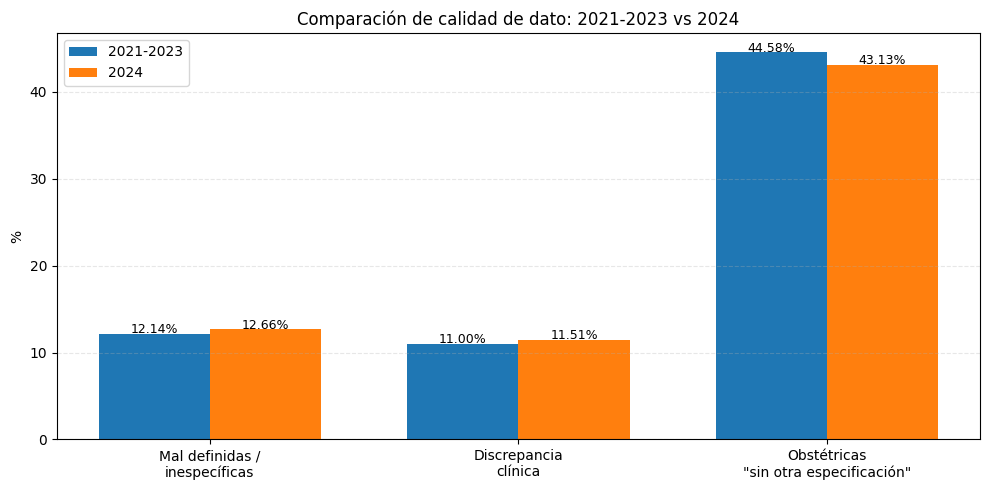

In [ ]:
# =========================================================
# QC7. GRÁFICO CONSOLIDADO 2021-2023 VS 2024
# =========================================================

tabla_plot_cmp = tabla_comparacion_final.copy()

x = np.arange(len(tabla_plot_cmp))
width = 0.36

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, tabla_plot_cmp["pct_2021_2023"], width, label="2021-2023")
plt.bar(x + width/2, tabla_plot_cmp["pct_2024"], width, label="2024")

plt.xticks(
    x,
    [
        "Mal definidas /\ninespecíficas",
        "Discrepancia\nclínica",
        'Obstétricas\n"sin otra especificación"'
    ]
)
plt.ylabel("%")
plt.title("Comparación de calidad de dato: 2021-2023 vs 2024")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, v in enumerate(tabla_plot_cmp["pct_2021_2023"]):
    plt.text(i - width/2, v + 0.08, f"{v:.2f}%", ha="center", fontsize=9)

for i, v in enumerate(tabla_plot_cmp["pct_2024"]):
    plt.text(i + width/2, v + 0.08, f"{v:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

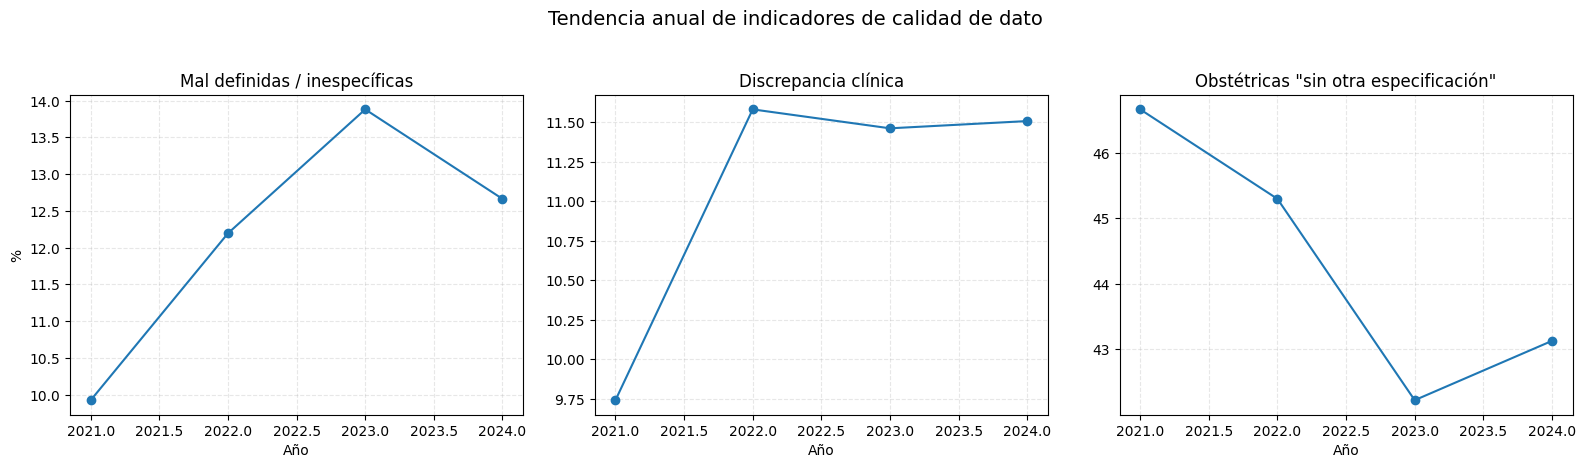

In [ ]:
# =========================================================
# QC8. PANEL DE TENDENCIA POR AÑO
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)

# Mal definidas
axes[0].plot(tabla_maldef_anio["anio_analisis"], tabla_maldef_anio["pct"], marker="o")
axes[0].set_title("Mal definidas / inespecíficas")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("%")
axes[0].grid(True, linestyle="--", alpha=0.3)

# Discrepancia clínica
axes[1].plot(tabla_discrep_anio["anio_analisis"], tabla_discrep_anio["pct"], marker="o")
axes[1].set_title("Discrepancia clínica")
axes[1].set_xlabel("Año")
axes[1].grid(True, linestyle="--", alpha=0.3)

# Obstétricas SOE
axes[2].plot(tabla_obst_soe_anio["anio_analisis"], tabla_obst_soe_anio["pct"], marker="o")
axes[2].set_title('Obstétricas "sin otra especificación"')
axes[2].set_xlabel("Año")
axes[2].grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Tendencia anual de indicadores de calidad de dato", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

La comparación 2021–2023 vs 2024 no muestra una mejoría global clara de la calidad del dato tras la capacitación. En los indicadores de mal definidas/inespecíficas y discrepancia clínica, 2024 incluso presenta porcentajes ligeramente mayores que el periodo 2021–2023. En el componente obstétrico “sin otra especificación” sí se observa una reducción modesta, pero esta no es estadísticamente significativa. En conjunto, los resultados sugieren que la capacitación pudo haber tenido un efecto limitado o heterogéneo, insuficiente para modificar de manera contundente la calidad global del registro.

In [ ]:
# =========================================================
# EXPORTAR BASE FINAL V2 PARA ANÁLISIS FINANCIERO
# =========================================================

from google.colab import files
import os

# Base final oficial
df_export_fin = df_principal_v2.copy()

# Verificación mínima
cols_obligatorias = [
    "grupo_principal",
    "macro_grupo_cluster",
    "subcluster_principal"
]

faltantes = [c for c in cols_obligatorias if c not in df_export_fin.columns]
if faltantes:
    raise ValueError(f"Faltan columnas clave para exportar: {faltantes}")

print("Base a exportar:", df_export_fin.shape)
print("Columnas clave presentes:", cols_obligatorias)

# -------- Opción recomendada: PARQUET --------
ruta_parquet = "/content/base_financiera_v2.parquet"
df_export_fin.to_parquet(ruta_parquet, index=False)
print("Archivo parquet guardado en:", ruta_parquet)

# Descargar
files.download(ruta_parquet)

Base a exportar: (26266, 60)
Columnas clave presentes: ['grupo_principal', 'macro_grupo_cluster', 'subcluster_principal']


ArrowInvalid: ("Could not convert '*9125' with type str: tried to convert to int64", 'Conversion failed for column edad_dias with type object')

In [ ]:
# =========================================================
# EXPORTAR BASE FINAL V2 A EXCEL (ALTERNATIVA)
# =========================================================

from google.colab import files

ruta_excel = "/content/base_financiera_v2.xlsx"
df_export_fin.to_excel(ruta_excel, index=False)
print("Archivo Excel guardado en:", ruta_excel)

files.download(ruta_excel)

Archivo Excel guardado en: /content/base_financiera_v2.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# =========================================================
# BLOQUE G11. PREPARAR COLUMNAS PARA DIAGNÓSTICO Y GRAN CAUSA
# =========================================================

df_graf = df_desc_v2.copy()

CLUSTER_FINAL_COL = "grupo_principal"

# ---------- Diagnóstico de egreso ----------
if "dx_desc" not in df_graf.columns:
    if "dx_nombre" in df_graf.columns:
        df_graf["dx_desc"] = df_graf["dx_nombre"].astype(str).str.strip().str.upper()
    elif "dx_nombre_qc" in df_graf.columns:
        df_graf["dx_desc"] = df_graf["dx_nombre_qc"].astype(str).str.strip().str.upper()
    else:
        raise ValueError("No encontré columna de diagnóstico de egreso para graficar.")

# ---------- Gran causa de morbilidad ----------
if "gran_causa_plot" not in df_graf.columns:
    posibles_causa = [
        "gran_causa_original_qc",
        "gran_causa_original_norm",
        "gran_causa_original",
        "gran_causa_morbilidad",
        "causa_morbilidad",
        "gran_causa"
    ]

    col_causa = None
    for c in posibles_causa:
        if c in df_graf.columns:
            col_causa = c
            break

    if col_causa is None:
        if "gran_causa_original_qc" in globals():
            col_causa = "gran_causa_original_qc"
        elif "COL_CAUSA_OLD" in globals() and COL_CAUSA_OLD in df_graf.columns:
            col_causa = COL_CAUSA_OLD

    if col_causa is None:
        raise ValueError("No encontré columna de gran causa de morbilidad para graficar.")

    df_graf["gran_causa_plot"] = (
        df_graf[col_causa]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({
            "NAN": "SIN_DATO",
            "NONE": "SIN_DATO",
            "": "SIN_DATO"
        })
    )

print("Diagnóstico listo:", "dx_desc")
print("Gran causa lista:", "gran_causa_plot")

display(
    df_graf[[CLUSTER_FINAL_COL, "dx_desc", "gran_causa_plot"]].head(10)
)

In [ ]:
# =========================================================
# BLOQUE G12. FUNCIÓN PANEL TOP N POR CLUSTER
# =========================================================

import math
import numpy as np
import matplotlib.pyplot as plt
import textwrap

def partir_texto(etiqueta, ancho=28):
    return "\n".join(textwrap.wrap(str(etiqueta), width=ancho))

def graficar_top_n_por_cluster(
    df,
    cluster_col,
    var_col,
    top_n=5,
    titulo_general="Top categorías dentro de cada cluster",
    color="#355C7D",
    ncols=2,
    figsize_por_panel=(6.4, 4.4),
    excluir_sin_dato=True
):
    data = df[[cluster_col, var_col]].copy()
    data[cluster_col] = data[cluster_col].astype(str)
    data[var_col] = data[var_col].astype(str).str.strip()

    if excluir_sin_dato:
        data = data[~data[var_col].isin(["SIN_DATO", "NAN", "NONE", ""])].copy()

    clusters = list(data[cluster_col].dropna().unique())
    n_clusters = len(clusters)
    nrows = math.ceil(n_clusters / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_por_panel[0] * ncols, figsize_por_panel[1] * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    for i, cluster in enumerate(clusters):
        ax = axes[i]
        sub = data[data[cluster_col] == cluster].copy()
        total = len(sub)

        top_tab = (
            sub[var_col]
            .value_counts(dropna=False)
            .head(top_n)
            .reset_index()
        )
        top_tab.columns = [var_col, "n"]
        top_tab["pct"] = top_tab["n"] / total * 100

        top_tab = top_tab.sort_values("pct", ascending=True)

        y = np.arange(len(top_tab))
        labels = [partir_texto(x, 28) for x in top_tab[var_col]]

        ax.barh(y, top_tab["pct"], color=color)
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(f"{cluster}\n(n={total})", fontsize=10, weight="bold")
        ax.grid(axis="x", linestyle="--", alpha=0.3)
        ax.set_xlim(0, max(100, top_tab["pct"].max() + 5))

        for j, v in enumerate(top_tab["pct"]):
            ax.text(v + 0.7, j, f"{v:.1f}%", va="center", fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(titulo_general, fontsize=16, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# =========================================================
# BLOQUE G13. PANEL TOP 5 DIAGNÓSTICOS DE EGRESO POR CLUSTER
# =========================================================

graficar_top_n_por_cluster(
    df=df_graf[df_graf[CLUSTER_FINAL_COL].isin(orden_clusters)].copy(),
    cluster_col=CLUSTER_FINAL_COL,
    var_col="dx_desc",
    top_n=5,
    titulo_general="Top 5 diagnósticos de egreso dentro de cada cluster",
    color="#355C7D",
    ncols=2,
    figsize_por_panel=(6.8, 4.6),
    excluir_sin_dato=True
)